# Steam Game Recommender  -  Research Notebook

**What this notebook is:** a complete experimental walkthrough of personalised Steam
game ranking on Anton Kozyriev's public review dataset (~41 million recommendations).

**What we are trying to show an audience:**

1. A personalised model can beat simple popularity on a large catalogue.
2. Hours played and review helpfulness may (or may not) help beyond the binary
   "recommended" label  -  we measure that instead of assuming it.
3. Explicit "not recommended" feedback should be tried, not thrown away.
4. Cold games, new releases, and new users need their own evaluation surfaces.
5. Long-tail discovery should improve coverage beyond "always recommend the hits."

**Signals we use:** playtime (`hours`), binary recommend (`is_recommended`),
helpfulness (`helpful` / `funny`), game tags for content / cold-start, and review
dates for an honest time-based train/test split.

**How to read this notebook with us:** early cells are *exploration* (plots on a
sample). Modeling starts at the full-file preprocessing section. The numbers that
matter for the claim are under **Main evaluation** (full-catalogue ranking) and the
final problem-statement audit.


## 1. Setup

Install missing packages if needed, then import the scientific stack we use throughout
(numpy, pandas, matplotlib, seaborn). We fix a random seed so sampling and model fits
are reproducible when the notebook is re-run.


In [1]:
!pip -q install kagglehub seaborn

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Download the dataset

Prefer a local `dataset/` folder if you already have the files (faster, no network).
Otherwise download Kozyriev's *Game Recommendations on Steam* via `kagglehub`.

We need four pieces: `games.csv`, `users.csv`, `recommendations.csv`, and
`games_metadata.json` (tags and descriptions).


In [2]:
from pathlib import Path
local_dataset = Path("dataset")
if local_dataset.exists() and (local_dataset / "games.csv").exists():
    DATA_DIR = local_dataset.resolve()
    print("Using local dataset directory:", DATA_DIR)
else:
    import kagglehub
    DATA_DIR = Path(kagglehub.dataset_download("antonkozyriev/game-recommendations-on-steam"))
    print("Downloaded dataset path:", DATA_DIR)

print("Files:")
for p in sorted(DATA_DIR.rglob("*")):
    if p.is_file():
        sz = p.stat().st_size / 1e6
        rel = p.relative_to(DATA_DIR)
        print(f"  {rel}  ({sz:.1f} MB)")


Downloaded dataset path: /kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam
Files:
  games.csv  (4.9 MB)
  games_metadata.json  (17.5 MB)
  recommendations.csv  (2023.2 MB)
  users.csv  (193.1 MB)


## 2. Locate files and load games / users

Resolve the four file paths under the dataset root, then load the **games catalogue**
and **user table**. These are small enough to hold fully in memory. The 41M-row
recommendations file is handled later in chunks.


In [3]:
candidates = {
    "games": list(DATA_DIR.rglob("games.csv")),
    "users": list(DATA_DIR.rglob("users.csv")),
    "recommendations": list(DATA_DIR.rglob("recommendations.csv")),
    "metadata": list(DATA_DIR.rglob("games_metadata.json"))
    + list(DATA_DIR.rglob("*metadata*.json")),
}
paths = {k: (v[0] if v else None) for k, v in candidates.items()}
for k, v in paths.items():
    print(f"{k:15s}: {v}")
assert paths["games"] and paths["users"] and paths["recommendations"], "Missing core CSV files"

games          : /kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/games.csv
users          : /kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/users.csv
recommendations: /kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/recommendations.csv
metadata       : /kaggle/input/datasets/antonkozyriev/game-recommendations-on-steam/games_metadata.json


In [4]:
games = pd.read_csv(paths["games"])
users = pd.read_csv(paths["users"])
print("games:", games.shape)
print("users:", users.shape)
display(games.head())
display(users.head())
print("\nGames missing:\n", games.isna().sum())
print("\nUsers missing:\n", users.isna().sum())

games: (50872, 13)
users: (14306064, 3)


,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


,user_id,products,reviews
0,7360263,359,0
1,14020781,156,1
2,8762579,329,4
3,4820647,176,4
4,5167327,98,2



Games missing:
 app_id            0
title             0
date_release      0
win               0
mac               0
linux             0
rating            0
positive_ratio    0
user_reviews      0
price_final       0
price_original    0
discount          0
steam_deck        0
dtype: int64

Users missing:
 user_id     0
products    0
reviews     0
dtype: int64


## 3. Load recommendations (chunked) + a plot sample

We **do not** load all 41M reviews into a single DataFrame for plotting  -  that would
blow RAM. Instead we:

1. Scan the file in 1M-row chunks to count totals and simple aggregates.
2. Draw a **reproducible random sample (~2M rows)** for histograms and EDA plots.

Important for the audience: **models are not trained on this plot sample.** Training
comes later from a dense subset of the *full* file.


In [5]:
REC_SAMPLE_SIZE = 2_000_000
CHUNKSIZE = 1_000_000
rec_path = paths["recommendations"]

print("Counting recommendation rows...")
n_rows = 0
for chunk in pd.read_csv(rec_path, usecols=["is_recommended"], chunksize=CHUNKSIZE):
    n_rows += len(chunk)
print(f"Total recommendation rows: {n_rows:,}")

sample_rate = min(1.0, REC_SAMPLE_SIZE / n_rows)
print(f"Sampling rate ~ {sample_rate:.4f}")

n_rows = 0
n_rec_true = 0
n_rec_false = 0
hours_sum = 0.0
helpful_sum = 0.0
funny_sum = 0.0
min_date = None
max_date = None
sample_chunks = []

print("Scanning recommendations (aggregates + sample)...")
for i, chunk in enumerate(pd.read_csv(rec_path, chunksize=CHUNKSIZE)):
    n_rows += len(chunk)
    if chunk["is_recommended"].dtype == object:
        chunk["is_recommended"] = (
            chunk["is_recommended"].astype(str).str.lower().isin(["true", "1", "yes"])
        )

    n_rec_true += int(chunk["is_recommended"].sum())
    n_rec_false += int((~chunk["is_recommended"]).sum())
    hours_sum += float(chunk["hours"].fillna(0).sum())
    helpful_sum += float(chunk["helpful"].fillna(0).sum())
    funny_sum += float(chunk["funny"].fillna(0).sum())

    dates = pd.to_datetime(chunk["date"], errors="coerce")
    dmin, dmax = dates.min(), dates.max()
    if pd.notna(dmin):
        min_date = dmin if min_date is None else min(min_date, dmin)
    if pd.notna(dmax):
        max_date = dmax if max_date is None else max(max_date, dmax)

    sample_chunks.append(chunk.sample(frac=sample_rate, random_state=RANDOM_STATE + i))
    if (i + 1) % 5 == 0:
        print(f"  processed ~{n_rows:,} rows...")

recs = pd.concat(sample_chunks, ignore_index=True)
if len(recs) > REC_SAMPLE_SIZE:
    recs = recs.sample(n=REC_SAMPLE_SIZE, random_state=RANDOM_STATE)

recs["date"] = pd.to_datetime(recs["date"], errors="coerce")
if recs["is_recommended"].dtype == object:
    recs["is_recommended"] = (
        recs["is_recommended"].astype(str).str.lower().isin(["true", "1", "yes"])
    )

full_stats = {
    "n_rows": n_rows,
    "n_recommended_true": n_rec_true,
    "n_recommended_false": n_rec_false,
    "recommend_rate": n_rec_true / max(n_rows, 1),
    "avg_hours": hours_sum / max(n_rows, 1),
    "avg_helpful": helpful_sum / max(n_rows, 1),
    "avg_funny": funny_sum / max(n_rows, 1),
    "date_min": str(min_date.date()) if min_date is not None else None,
    "date_max": str(max_date.date()) if max_date is not None else None,
    "sample_rows": len(recs),
}
print("Full-file stats:")
for k, v in full_stats.items():
    print(f"  {k}: {v}")
print("\nSample shape:", recs.shape)
display(recs.head())
print("\nSample missing:\n", recs.isna().sum())

Counting recommendation rows...
Total recommendation rows: 41,154,794
Sampling rate ~ 0.0486
Scanning recommendations (aggregates + sample)...
  processed ~5,000,000 rows...
  processed ~10,000,000 rows...
  processed ~15,000,000 rows...
  processed ~20,000,000 rows...
  processed ~25,000,000 rows...
  processed ~30,000,000 rows...
  processed ~35,000,000 rows...
  processed ~40,000,000 rows...
Full-file stats:
  n_rows: 41154794
  n_recommended_true: 35304398
  n_recommended_false: 5850396
  recommend_rate: 0.8578441189621797
  avg_hours: 100.60223780004829
  avg_helpful: 3.202566850413587
  avg_funny: 1.0580708531793404
  date_min: 2010-10-15
  date_max: 2022-12-31
  sample_rows: 2000000

Sample shape: (2000000, 8)


,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,1919590,0,0,2022-09-09,True,359.7,4615224,987231
1,976730,0,0,2021-07-13,True,29.0,12462524,79954
2,1044720,0,0,2022-12-18,True,15.8,6187198,567130
3,1817190,0,0,2022-12-03,True,11.1,10781965,500891
4,730,0,0,2021-08-04,True,178.3,11220471,55399



Sample missing:
 app_id            0
helpful           0
funny             0
date              0
is_recommended    0
hours             0
user_id           0
review_id         0
dtype: int64


## 4. Game metadata (tags and descriptions)

Tags are the content signal for cold-start and for the "because you liked …"
explanations in the demo app. We load `games_metadata.json` and normalise the `tags`
field into a Python list per game.

**Caveat we will be honest about later:** some very popular titles in this dump have an
*empty* tag list. They still appear in ranking (they have plenty of reviews), but the
explanation chips can be blank for those games.


In [6]:
meta_path = paths["metadata"]
if meta_path is None:
    print("No metadata JSON found  -  tag analysis will be skipped.")
    meta = pd.DataFrame(columns=["app_id", "description", "tags"])
else:
    rows = []
    with open(meta_path, "r", encoding="utf-8") as f:
        first = f.read(1)
        f.seek(0)
        if first == "[":
            rows = json.load(f)
        else:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
    meta = pd.DataFrame(rows)
    if "app_id" not in meta.columns and "id" in meta.columns:
        meta = meta.rename(columns={"id": "app_id"})
    print("metadata:", meta.shape)
    display(meta.head())
    print("columns:", list(meta.columns))

metadata: (50872, 3)


,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,,[Action]
2,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."


columns: ['app_id', 'description', 'tags']


In [7]:
if "tags" in meta.columns and len(meta):
    def ensure_list(x):
        if isinstance(x, list):
            return x
        if pd.isna(x):
            return []
        if isinstance(x, str):
            try:
                val = json.loads(x)
                return val if isinstance(val, list) else [x]
            except Exception:
                return [t.strip() for t in x.split(",") if t.strip()]
        return []

    meta["tags_list"] = meta["tags"].apply(ensure_list)
    meta["n_tags"] = meta["tags_list"].str.len()
    tag_exploded = meta.explode("tags_list").rename(columns={"tags_list": "tag"})
    top_tags = tag_exploded["tag"].value_counts().head(20)
    print("Games with metadata:", len(meta))
    print("Avg tags per game:", meta["n_tags"].mean())
    display(top_tags)
else:
    tag_exploded = pd.DataFrame(columns=["app_id", "tag"])
    top_tags = pd.Series(dtype=int)
    print("Tag fields not available")

Games with metadata: 50872
Avg tags per game: 11.484018713634219


tag
Indie             27957
Singleplayer      22566
Action            21897
Adventure         20183
Casual            17844
Simulation        12691
2D                11438
Strategy          11093
RPG               10156
Atmospheric        8688
Puzzle             7585
Story Rich         7149
Multiplayer        6575
3D                 6142
Pixel Graphics     6028
Exploration        5769
Cute               5702
Colorful           5693
Free to Play       5645
First-Person       5570
Name: count, dtype: int64

## 5. Dataset overview

A one-screen summary of table sizes: how many games, users, full recommendation rows,
plot-sample rows, and metadata rows. This is the "what are we working with?" slide.


In [8]:
overview = pd.DataFrame(
    [
        {"table": "games", "rows": len(games), "cols": games.shape[1]},
        {"table": "users", "rows": len(users), "cols": users.shape[1]},
        {"table": "recommendations (full)", "rows": full_stats["n_rows"], "cols": recs.shape[1]},
        {"table": "recommendations (sample)", "rows": len(recs), "cols": recs.shape[1]},
        {"table": "games_metadata", "rows": len(meta), "cols": meta.shape[1]},
    ]
)
display(overview)
print("Recommendation columns:", list(recs.columns))
print("Games columns:", list(games.columns))
print("Users columns:", list(users.columns))

,table,rows,cols
0,games,50872,13
1,users,14306064,3
2,recommendations (full),41154794,8
3,recommendations (sample),2000000,8
4,games_metadata,50872,5


Recommendation columns: ['app_id', 'helpful', 'funny', 'date', 'is_recommended', 'hours', 'user_id', 'review_id']
Games columns: ['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck']
Users columns: ['user_id', 'products', 'reviews']


## 6. Games catalogue EDA

Look at rating distributions, prices, and release years. This motivates two later
claims: (a) the catalogue is huge and long-tailed, and (b) "new releases" are a
real surface we should evaluate separately from evergreen hits.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
app_id,50872.0,NaN,NaN,NaN,1055223.805099,610324.945457,10.0,528737.5,986085.0,1524895.0,2599300.0
title,50872,50751,Loop,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_release,50872,4292,2020-06-18,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
win,50872,2,True,50076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mac,50872,2,False,37854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
linux,50872,2,False,41831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,50872,9,Positive,13502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
positive_ratio,50872.0,NaN,NaN,NaN,77.052033,18.253592,0.0,67.0,81.0,91.0,100.0
user_reviews,50872.0,NaN,NaN,NaN,1824.424988,40073.521653,10.0,19.0,49.0,206.0,7494460.0
price_final,50872.0,NaN,NaN,NaN,8.620325,11.514164,0.0,0.99,4.99,10.99,299.99


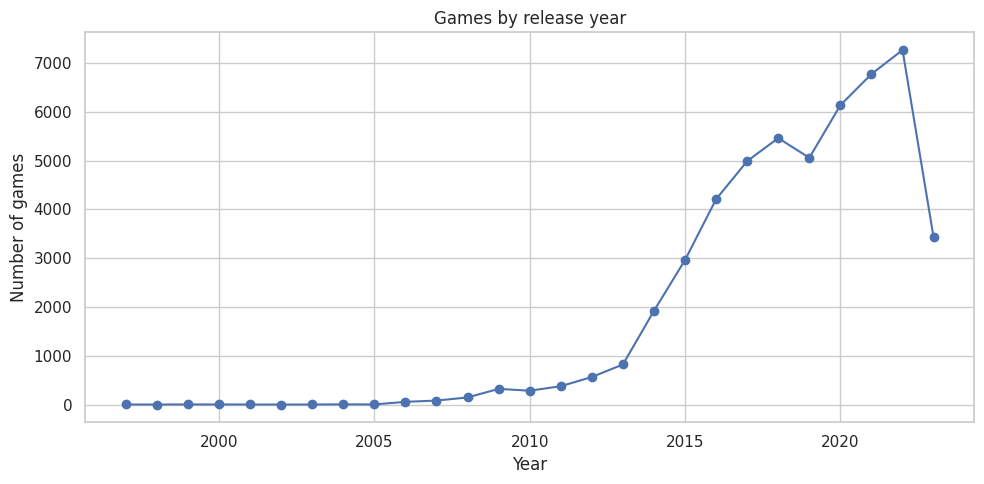

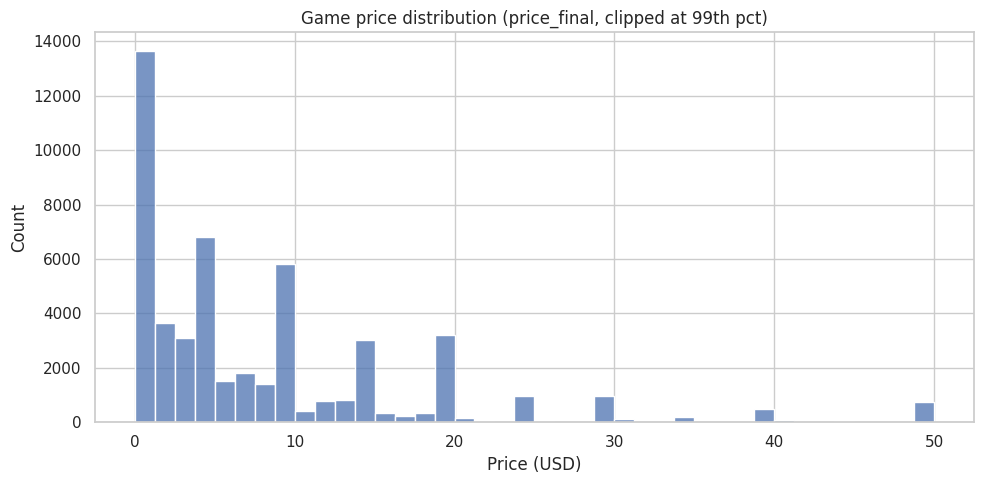

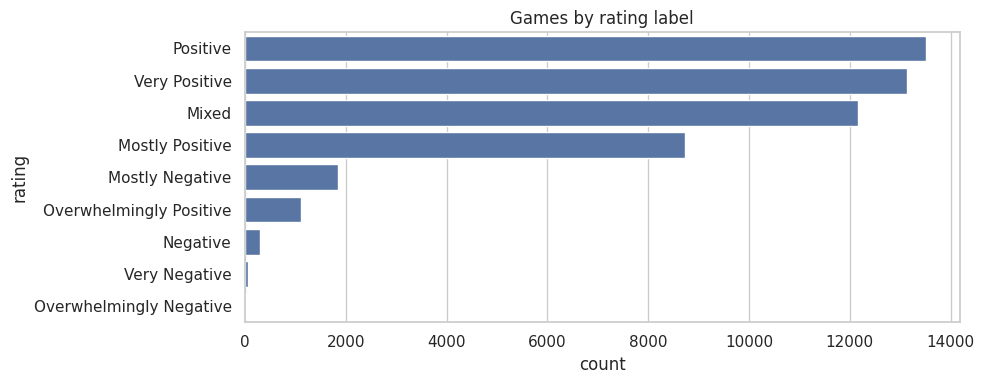

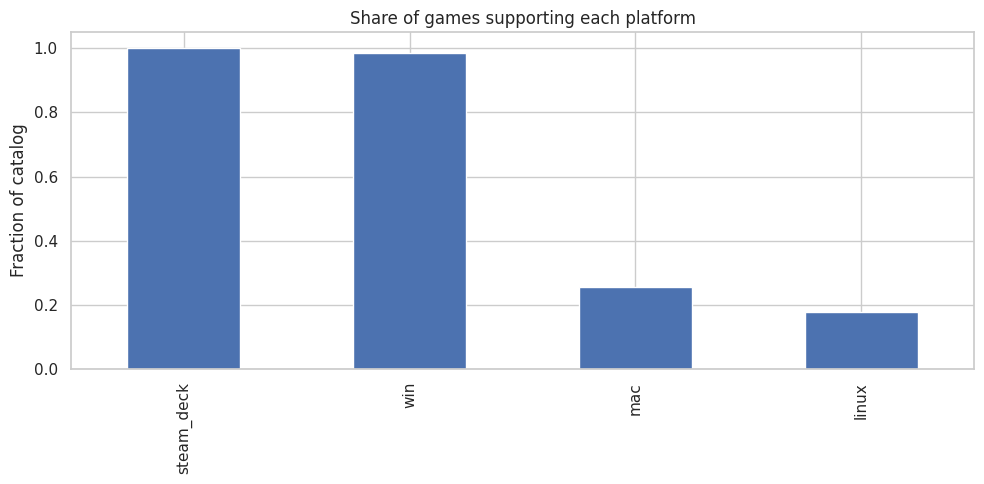

In [9]:
display(games.describe(include="all").T.head(20))

if "date_release" in games.columns:
    games["date_release"] = pd.to_datetime(games["date_release"], errors="coerce")
    games["release_year"] = games["date_release"].dt.year
    year_counts = games["release_year"].value_counts().sort_index()
    ax = year_counts.plot(kind="line", marker="o")
    ax.set_title("Games by release year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of games")
    plt.tight_layout()
    plt.show()

price_col = (
    "price_final"
    if "price_final" in games.columns
    else ("price" if "price" in games.columns else None)
)
if price_col:
    fig, ax = plt.subplots()
    sns.histplot(
        games[price_col].clip(upper=games[price_col].quantile(0.99)), bins=40, ax=ax
    )
    ax.set_title(f"Game price distribution ({price_col}, clipped at 99th pct)")
    ax.set_xlabel("Price (USD)")
    plt.tight_layout()
    plt.show()

if "rating" in games.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    order = games["rating"].value_counts().index
    sns.countplot(data=games, y="rating", order=order, ax=ax)
    ax.set_title("Games by rating label")
    plt.tight_layout()
    plt.show()

platform_cols = [c for c in ["win", "mac", "linux", "steam_deck"] if c in games.columns]
if platform_cols:
    plat = games[platform_cols].mean().sort_values(ascending=False)
    fig, ax = plt.subplots()
    plat.plot(kind="bar", ax=ax)
    ax.set_title("Share of games supporting each platform")
    ax.set_ylabel("Fraction of catalog")
    plt.tight_layout()
    plt.show()

## 7. Users EDA

How many products people own and how many reviews they write. Most users are sparse  - 
that is why cold-start users (few seed likes) are a first-class experiment later, not
an afterthought.


,user_id,products,reviews
count,1.430606e+07,1.430606e+07,1.430606e+07
mean,7.153032e+06,1.163734e+02,2.876738e+00
std,4.129805e+06,2.438515e+02,7.987421e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.576516e+06,2.300000e+01,1.000000e+00
50%,7.153032e+06,5.500000e+01,1.000000e+00
75%,1.072955e+07,1.270000e+02,3.000000e+00
max,1.430606e+07,3.221400e+04,6.045000e+03


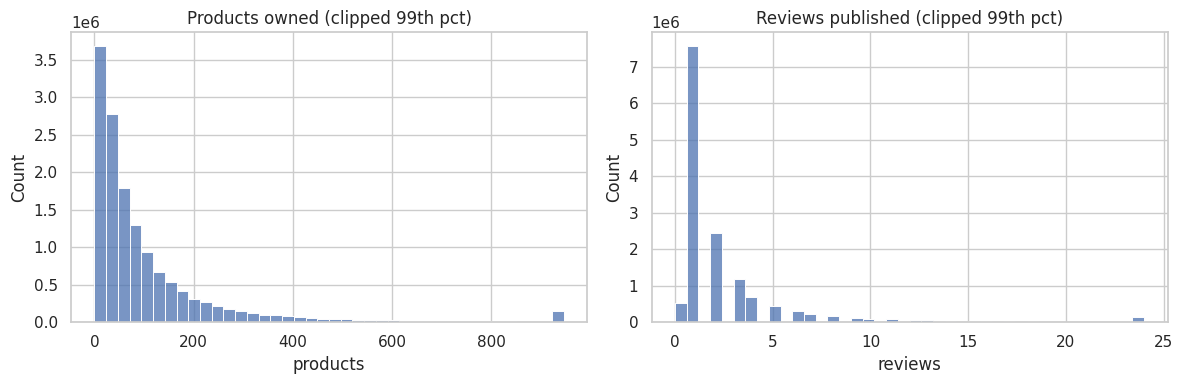

Users with 0 reviews: 525005
Users with 1 review: 7573027
Users with >=10 reviews: 680812


In [10]:
display(users.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    users["products"].clip(upper=users["products"].quantile(0.99)), bins=40, ax=axes[0]
)
axes[0].set_title("Products owned (clipped 99th pct)")
sns.histplot(
    users["reviews"].clip(upper=users["reviews"].quantile(0.99)), bins=40, ax=axes[1]
)
axes[1].set_title("Reviews published (clipped 99th pct)")
plt.tight_layout()
plt.show()

print("Users with 0 reviews:", int((users["reviews"] == 0).sum()))
print("Users with 1 review:", int((users["reviews"] == 1).sum()))
print("Users with >=10 reviews:", int((users["reviews"] >= 10).sum()))

## 8. Recommendation signals  -  exploratory look

Steam gives us more than a star rating. Here we inspect the **multi-signal** view:

- `is_recommended`  -  the explicit binary label (heavily skewed toward "yes")
- `hours`  -  playtime (noisy: grinding and unfinished purchases exist)
- `helpful` / `funny`  -  other players voting on the review

These plots build intuition. Whether hours × helpfulness *actually* improve ranking is
tested later with a controlled ablation, not assumed from EDA.


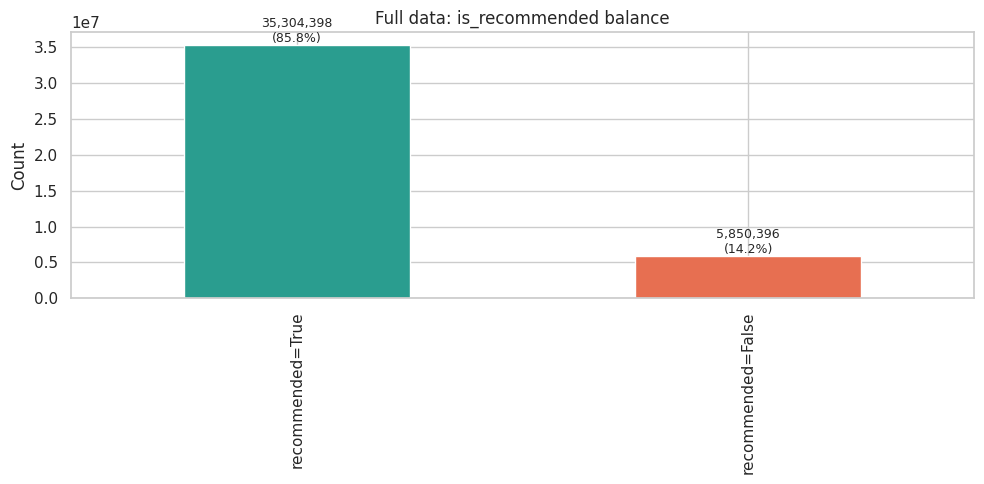

Recommend rate (full): 85.784%


In [11]:
bal = pd.Series(
    {
        "recommended=True": full_stats["n_recommended_true"],
        "recommended=False": full_stats["n_recommended_false"],
    }
)
fig, ax = plt.subplots()
bal.plot(kind="bar", ax=ax, color=["#2a9d8f", "#e76f51"])
ax.set_title("Full data: is_recommended balance")
ax.set_ylabel("Count")
for i, v in enumerate(bal.values):
    ax.text(
        i,
        v,
        f"{v:,}\n({v / full_stats['n_rows']:.1%})",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()
print(f"Recommend rate (full): {full_stats['recommend_rate']:.3%}")

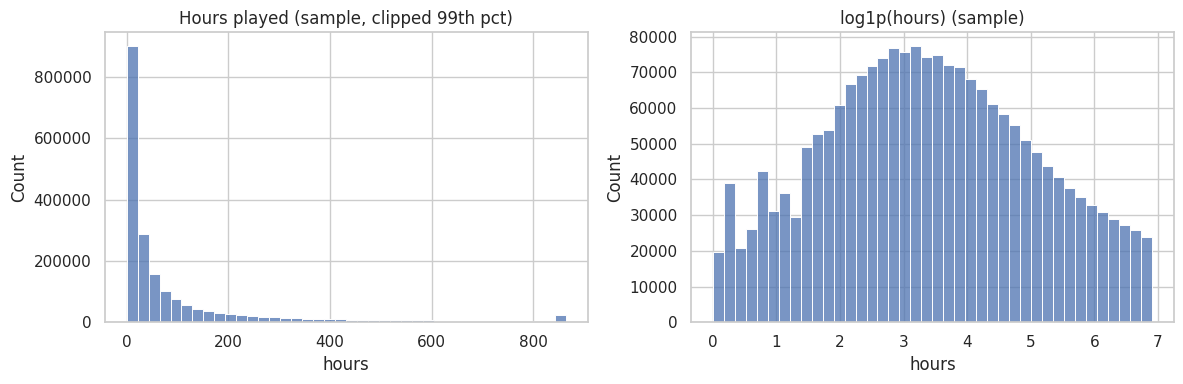

count    2.000000e+06
mean     1.007222e+02
std      1.763419e+02
min      0.000000e+00
25%      7.800000e+00
50%      2.730000e+01
75%      9.920000e+01
max      1.000000e+03
Name: hours, dtype: float64

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    recs["hours"].clip(upper=recs["hours"].quantile(0.99)), bins=40, ax=axes[0]
)
axes[0].set_title("Hours played (sample, clipped 99th pct)")
sns.histplot(np.log1p(recs["hours"]), bins=40, ax=axes[1])
axes[1].set_title("log1p(hours) (sample)")
plt.tight_layout()
plt.show()
display(recs["hours"].describe())

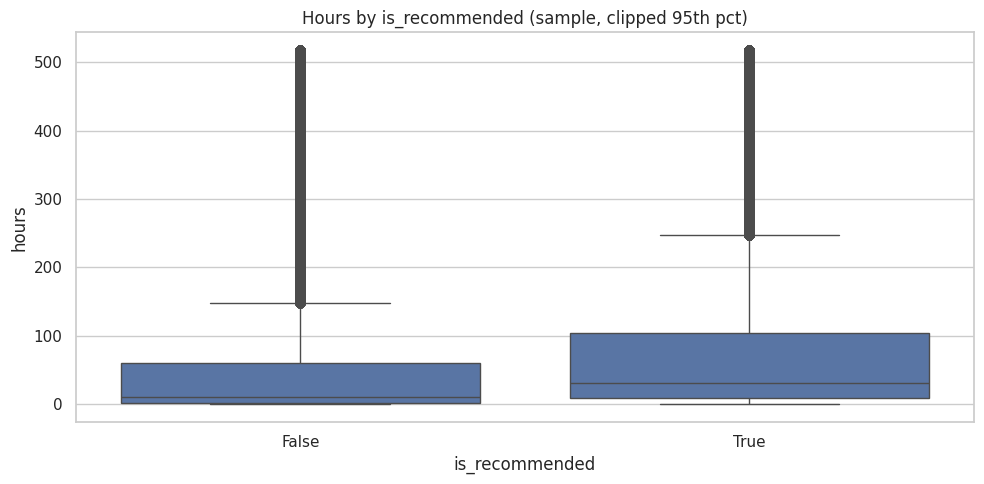

                  count        mean  median         std
is_recommended                                         
False            283581   81.058679    11.1  170.729616
True            1716419  103.970989    30.4  177.042019


In [13]:
fig, ax = plt.subplots()
sns.boxplot(
    data=recs.assign(hours_clip=recs["hours"].clip(upper=recs["hours"].quantile(0.95))),
    x="is_recommended",
    y="hours_clip",
    ax=ax,
)
ax.set_title("Hours by is_recommended (sample, clipped 95th pct)")
ax.set_xlabel("is_recommended")
ax.set_ylabel("hours")
plt.tight_layout()
plt.show()
print(recs.groupby("is_recommended")["hours"].agg(["count", "mean", "median", "std"]))

In [14]:
hi = recs["hours"] >= recs["hours"].quantile(0.90)
lo = recs["hours"] <= recs["hours"].quantile(0.10)
disagree_hi = recs[hi & (~recs["is_recommended"])]
disagree_lo = recs[lo & (recs["is_recommended"])]
print(
    f"High-hours (top 10%) & NOT recommended: {len(disagree_hi):,} "
    f"({len(disagree_hi) / len(recs):.2%} of sample)"
)
print(
    f"Low-hours (bottom 10%) & recommended: {len(disagree_lo):,} "
    f"({len(disagree_lo) / len(recs):.2%} of sample)"
)
print("These disagreements motivate jointly modeling hours + is_recommended.")

High-hours (top 10%) & NOT recommended: 24,323 (1.22% of sample)
Low-hours (bottom 10%) & recommended: 129,850 (6.49% of sample)
These disagreements motivate jointly modeling hours + is_recommended.


## 9. Helpfulness as confidence

Idea we will test in modeling: a recommend review that many players marked *helpful*
should count for more than an unvoted one. We look at the distribution here; the formal
test is the confidence-weighting ablation in Block A.


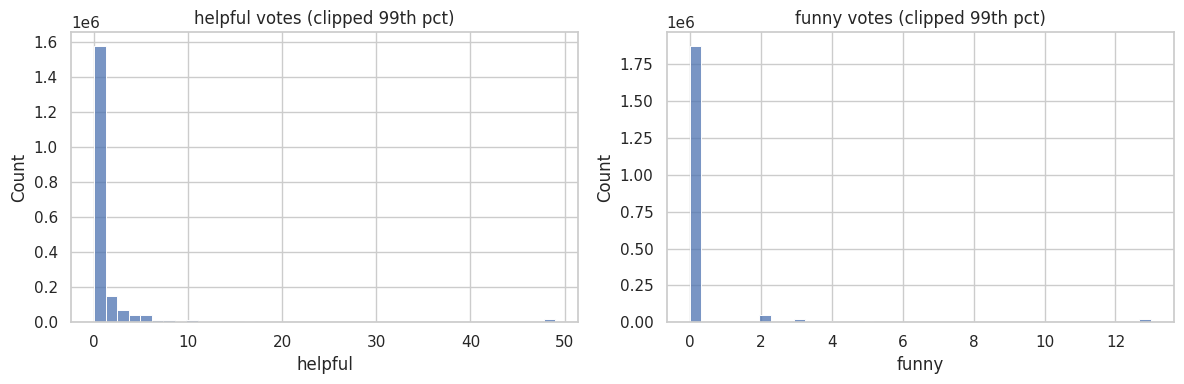

                 helpful            funny       
                    mean median      mean median
is_recommended                                  
False           6.239967    0.0  1.257662    0.0
True            2.716394    0.0  1.057833    0.0


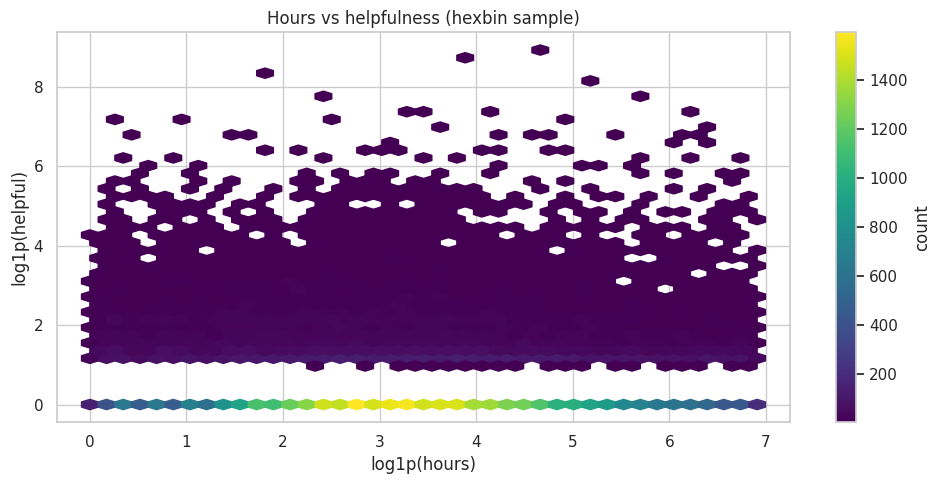

Share of reviews with helpful==0: 78.9%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(
    recs["helpful"].clip(upper=recs["helpful"].quantile(0.99)), bins=40, ax=axes[0]
)
axes[0].set_title("helpful votes (clipped 99th pct)")
sns.histplot(
    recs["funny"].clip(upper=recs["funny"].quantile(0.99)), bins=40, ax=axes[1]
)
axes[1].set_title("funny votes (clipped 99th pct)")
plt.tight_layout()
plt.show()

print(recs.groupby("is_recommended")[["helpful", "funny"]].agg(["mean", "median"]))

sub = recs.sample(n=min(50_000, len(recs)), random_state=RANDOM_STATE)
fig, ax = plt.subplots()
hb = ax.hexbin(
    np.log1p(sub["hours"]),
    np.log1p(sub["helpful"]),
    gridsize=40,
    cmap="viridis",
    mincnt=1,
)
ax.set_xlabel("log1p(hours)")
ax.set_ylabel("log1p(helpful)")
ax.set_title("Hours vs helpfulness (hexbin sample)")
plt.colorbar(hb, ax=ax, label="count")
plt.tight_layout()
plt.show()
print("Share of reviews with helpful==0:", f"{(recs['helpful'] == 0).mean():.1%}")

## 10. Temporal patterns

Reviews arrive over time. That matters because a random train/test split would let the
model "see the future." We will use a **time cutoff**: train on older reviews, test on
newer ones  -  the same way a live recommender must predict what a user likes *next*.


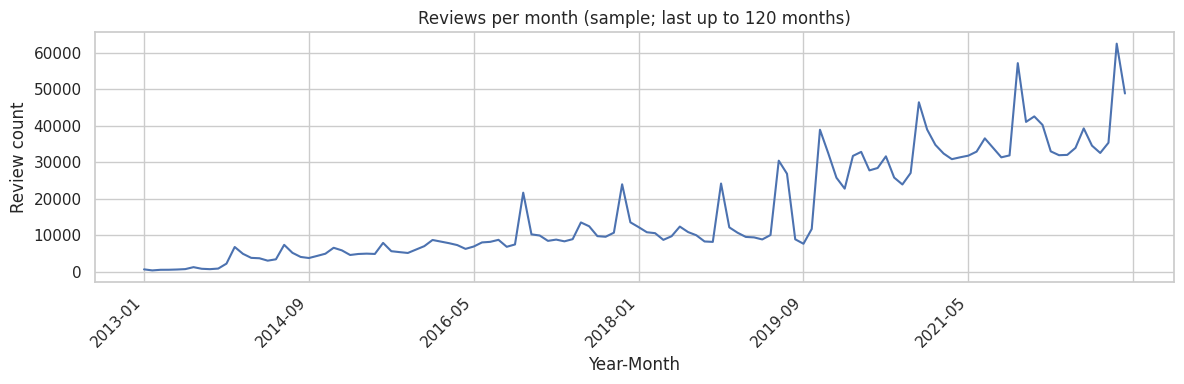

Full-file date range: 2010-10-15 -> 2022-12-31
Sample date range: 2010-10-15 00:00:00 -> 2022-12-31 00:00:00


In [16]:
recs["year_month"] = recs["date"].dt.to_period("M").astype(str)
monthly = recs.groupby("year_month").size()
monthly_plot = monthly.tail(120)
fig, ax = plt.subplots(figsize=(12, 4))
monthly_plot.plot(ax=ax)
ax.set_title("Reviews per month (sample; last up to 120 months)")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Review count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("Full-file date range:", full_stats["date_min"], "->", full_stats["date_max"])
print("Sample date range:", recs["date"].min(), "->", recs["date"].max())

## 11. Cold-start proxies (EDA)

Before we build models, sketch how common "cold" situations are:

- users with very few reviews
- games with very few reviews
- recently released titles

These are the hard cases collaborative filtering alone struggles with  -  and the reason
we keep tags and a dedicated cold / new-release evaluation later.


Unique users in sample: 1608884
Unique games in sample: 27544
Users with 1 interaction: 1377533
Games with 1 interaction: 6665


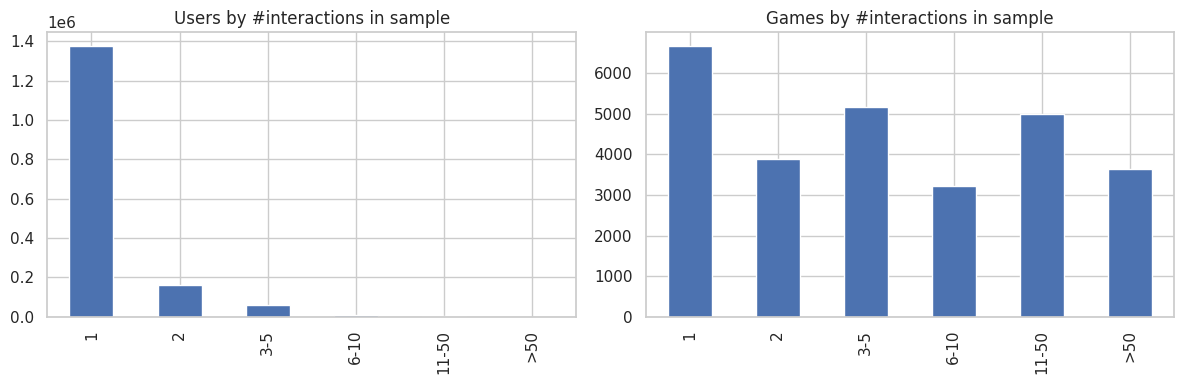

In [17]:
user_counts = recs["user_id"].value_counts()
game_counts = recs["app_id"].value_counts()


def bin_counts(s, edges=(1, 2, 5, 10, 50)):
    labels = []
    vals = []
    prev = 0
    for e in edges:
        labels.append(f"{prev + 1}-{e}" if prev + 1 < e else f"{e}")
        vals.append(int(((s > prev) & (s <= e)).sum()))
        prev = e
    labels.append(f">{edges[-1]}")
    vals.append(int((s > edges[-1]).sum()))
    return pd.Series(vals, index=labels)


print("Unique users in sample:", user_counts.shape[0])
print("Unique games in sample:", game_counts.shape[0])
print("Users with 1 interaction:", int((user_counts == 1).sum()))
print("Games with 1 interaction:", int((game_counts == 1).sum()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bin_counts(user_counts).plot(kind="bar", ax=axes[0])
axes[0].set_title("Users by #interactions in sample")
bin_counts(game_counts).plot(kind="bar", ax=axes[1])
axes[1].set_title("Games by #interactions in sample")
plt.tight_layout()
plt.show()

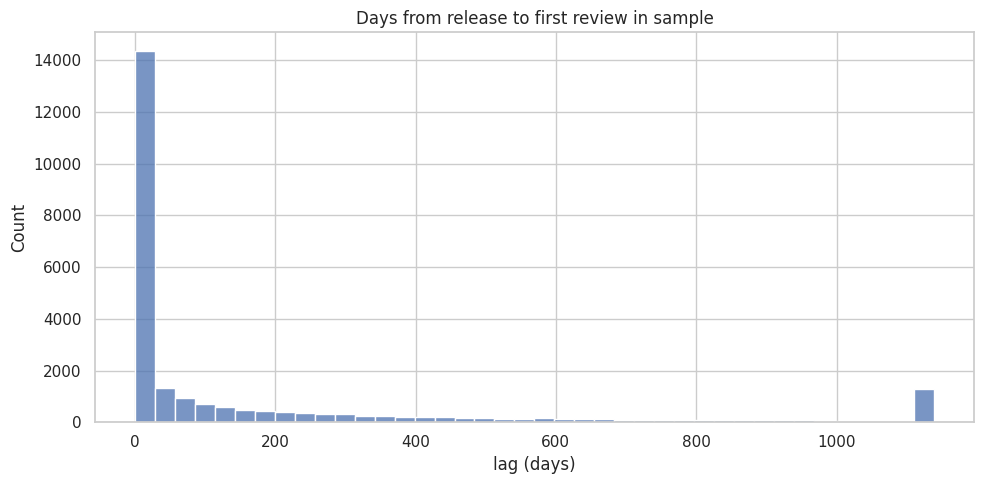

count    24839.000000
mean       205.164620
std        438.449056
min          0.000000
25%          1.000000
50%         10.000000
75%        185.000000
max       3650.000000
Name: lag_days, dtype: float64


In [18]:
if "date_release" in games.columns:
    first_review = recs.groupby("app_id")["date"].min().rename("first_review")
    g = games[["app_id", "date_release"]].merge(first_review, on="app_id", how="inner")
    g["lag_days"] = (g["first_review"] - g["date_release"]).dt.days
    g = g[g["lag_days"].between(0, 3650)]
    fig, ax = plt.subplots()
    sns.histplot(
        g["lag_days"].clip(upper=g["lag_days"].quantile(0.95)), bins=40, ax=ax
    )
    ax.set_title("Days from release to first review in sample")
    ax.set_xlabel("lag (days)")
    plt.tight_layout()
    plt.show()
    print(g["lag_days"].describe())

## 12. Tags / content coverage

Which tags dominate the catalogue (Indie, Action, Singleplayer, …)? Ubiquitous tags are
weak for discrimination  -  that is why we later use **TF-IDF weighted** tag vectors
instead of raw one-hot bags of the most common labels.


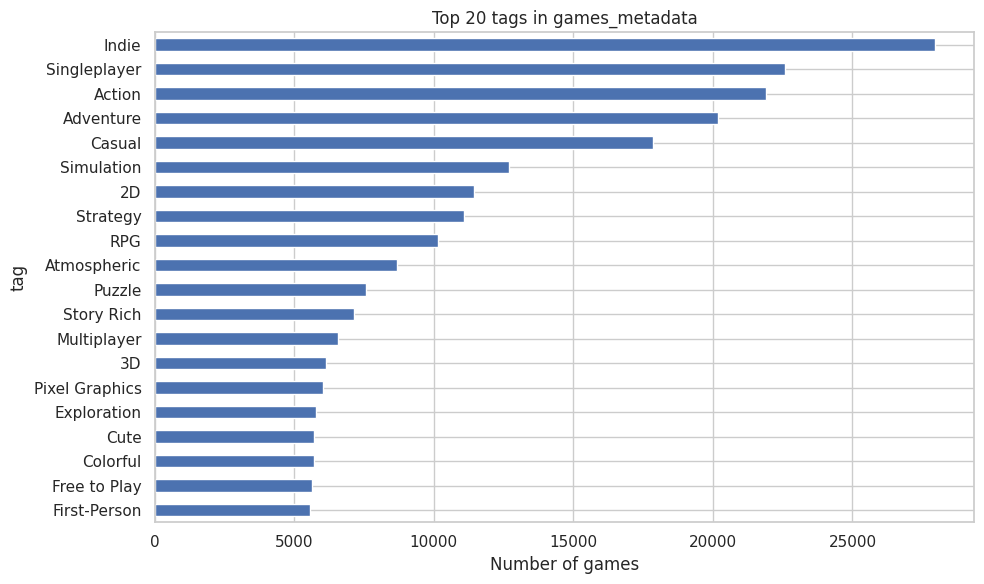

Unique games in rec sample: 27,544
Games with metadata: 50,872
Overlap (can use tags): 27,544 (100.0%)


In [19]:
if len(top_tags):
    fig, ax = plt.subplots(figsize=(10, 6))
    top_tags.sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Top 20 tags in games_metadata")
    ax.set_xlabel("Number of games")
    plt.tight_layout()
    plt.show()

    reviewed_games = set(recs["app_id"].unique())
    meta_games = set(meta["app_id"].unique()) if "app_id" in meta.columns else set()
    tagged = reviewed_games & meta_games
    print(f"Unique games in rec sample: {len(reviewed_games):,}")
    print(f"Games with metadata: {len(meta_games):,}")
    print(
        f"Overlap (can use tags): {len(tagged):,} "
        f"({len(tagged) / max(len(reviewed_games), 1):.1%})"
    )
else:
    print("Skipping tag plots  -  metadata unavailable")

## 13. Sparsity sketch

User-game interactions are extremely sparse relative to "all users × all games." That
is the classic recommender setting: matrix factorisation and implicit ALS exist because
a dense table of every pair is impossible.


In [20]:
n_users_s = recs["user_id"].nunique()
n_games_s = recs["app_id"].nunique()
n_inter_s = len(recs)
density = n_inter_s / (n_users_s * n_games_s)
print(f"Sample interactions: {n_inter_s:,}")
print(f"Sample unique users: {n_users_s:,}")
print(f"Sample unique games: {n_games_s:,}")
print(f"Sample matrix density ~ {density:.6%} (very sparse  -  expected for CF)")

approx_density = full_stats["n_rows"] / (len(users) * len(games))
print(f"Approx full density using |users| x |games| ~ {approx_density:.8%}")

Sample interactions: 2,000,000
Sample unique users: 1,608,884
Sample unique games: 27,544
Sample matrix density ~ 0.004513% (very sparse  -  expected for CF)
Approx full density using |users| x |games| ~ 0.00565485%


## 14. EDA takeaways -> what the hybrid system must do

The exploratory section closes by writing a short findings blurb. In plain language:

- We have a large, skewed recommend label and noisy playtime.
- Tags exist for most games but not all blockbusters in this dump.
- Time and cold-start structure are real, so evaluation must respect them.

Next we leave the 2M plot sample and build the **modeling table from the full file.**


In [21]:
findings = f'''
Steam Game Recommender  -  EDA findings
=====================================
Dataset: Kozyriev Steam recommendations
Full recommendations: {full_stats["n_rows"]:,}
Recommend rate: {full_stats["recommend_rate"]:.2%}
Date range: {full_stats["date_min"]} -> {full_stats["date_max"]}
Avg hours (full): {full_stats["avg_hours"]:.2f}
Avg helpful (full): {full_stats["avg_helpful"]:.2f}
Sample used for plots: {len(recs):,} rows
'''

print(findings)


Steam Game Recommender  -  EDA findings
Dataset: Kozyriev Steam recommendations
Full recommendations: 41,154,794
Recommend rate: 85.78%
Date range: 2010-10-15 -> 2022-12-31
Avg hours (full): 100.60
Avg helpful (full): 3.20
Sample used for plots: 2,000,000 rows



# Full-file preprocessing (chunked)

This is where research modeling begins. We **read every row** of `recommendations.csv`
in two passes:

1. **Pass 1  -  count.** How many reviews per user and per game on the full file
   (drop rows missing `date` / `user_id` / `app_id`).
2. **Keep a dense subset.** Users with >= 10 reviews, games with >= 30 reviews (and a
   metadata row), capped so the matrix fits (max users / games / rows).
3. **Pass 2  -  collect.** Stream the file again, write only kept rows to disk, then load.
4. **Time split.** Oldest 80% of dates -> train; newest 20% -> test.
5. **Train-only confidence.** `log1p(hours) × log1p(1 + helpful)` is computed for
   training weights. At serving time a web user only picks games  -  we do not re-ask for
   hours.

If the dense set is still too large, we subsample **users**, not random rows (so each
kept user's history stays intact).

**Honest claim for the audience:** we scanned all ~41M rows and train on the dense
subset  -  not on the 2M EDA sample, and not by holding 41M rows in RAM at once.


In [22]:
# Audience note  -  Pass 1 of full-file prep:
# Count reviews per user/game on ALL ~41M rows, then decide who/what stays
# in the dense modelling subset. Plots above used a sample; this pass does not.

from collections import Counter
from IPython.display import display
from scipy.sparse import csr_matrix, save_npz
from sklearn.decomposition import TruncatedSVD

MIN_USER_REVIEWS = 10
MIN_GAME_REVIEWS = 30
MAX_USERS = 80_000
MAX_GAMES = 12_000
MAX_MODEL_ROWS = 4_000_000
TRAIN_TIME_FRAC = 0.80
CHUNKSIZE = 1_000_000
K = 10
WARM_MIN_TRAIN_LIKES = 5
WARM_EVAL_USERS = 300   # how many warm users to sample for eval
COLD_EVAL_USERS = 300   # how many cold users to sample for eval
                        # (previously only ~4 cold users showed up under pure random sampling)
RETRIEVE_N = 300
RANDOM_STATE = 42

if Path("/kaggle/working").exists():
    OUT_DIR = Path("/kaggle/working/processed")
elif Path("/content").exists():
    OUT_DIR = Path("/content/processed")
else:
    OUT_DIR = Path.cwd() / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR = OUT_DIR / "website_export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

rec_path = paths["recommendations"]


def normalize_bool(series):
    if series.dtype == object:
        return series.astype(str).str.lower().isin(["true", "1", "yes"])
    return series.astype(bool)


print("Pass 1/2: counting users and games on the FULL file...")
user_counts = Counter()
game_counts = Counter()
n_full = 0
n_dropped = 0
for i, chunk in enumerate(
    pd.read_csv(rec_path, usecols=["user_id", "app_id", "date"], chunksize=CHUNKSIZE)
):
    n_full += len(chunk)
    before = len(chunk)
    chunk = chunk.dropna(subset=["user_id", "app_id", "date"])
    n_dropped += before - len(chunk)
    user_counts.update(chunk["user_id"].tolist())
    game_counts.update(chunk["app_id"].tolist())
    if (i + 1) % 10 == 0:
        print(f"  counted {n_full:,} rows...")

print(f"Full-file recommendation rows scanned: {n_full:,}")
print(f"Dropped missing user/game/date: {n_dropped:,}")
print(f"Unique users (full): {len(user_counts):,}")
print(f"Unique games (full): {len(game_counts):,}")

def _as_int(x):
    try:
        return int(x)
    except (TypeError, ValueError):
        return x

user_counts = Counter({_as_int(u): c for u, c in user_counts.items()})
game_counts = Counter({_as_int(g): c for g, c in game_counts.items()})
keep_users = {u for u, c in user_counts.items() if c >= MIN_USER_REVIEWS}
keep_games = {g for g, c in game_counts.items() if c >= MIN_GAME_REVIEWS}

if "app_id" in meta.columns:
    tagged_games = set()
    for x in meta["app_id"].dropna().tolist():
        try:
            tagged_games.add(int(x))
        except (TypeError, ValueError):
            tagged_games.add(x)
    # also keep original dtype keys so the set intersection is not empty
    tagged_games |= set(meta["app_id"].dropna().tolist())
    keep_games = keep_games & tagged_games

eligible_games_sorted = sorted(keep_games, key=lambda g: game_counts.get(g, 0), reverse=True)
keep_games = set(eligible_games_sorted[:MAX_GAMES])
eligible_users_sorted = sorted(keep_users, key=lambda u: user_counts.get(u, 0), reverse=True)
keep_users = set(eligible_users_sorted[:MAX_USERS])

print(f"Kept users (after min + cap): {len(keep_users):,}")
print(f"Kept games (after min + tags + cap): {len(keep_games):,}")


Pass 1/2: counting users and games on the FULL file...
  counted 10,000,000 rows...
  counted 20,000,000 rows...
  counted 30,000,000 rows...
  counted 40,000,000 rows...
Full-file recommendation rows scanned: 41,154,794
Dropped missing user/game/date: 0
Unique users (full): 13,781,059
Unique games (full): 37,610
Kept users (after min + cap): 80,000
Kept games (after min + tags + cap): 12,000


In [23]:
# Audience note  -  Pass 2:
# Stream the full recommendations file again and keep only (user, game) pairs
# that survived the density filters. Write to disk, load, time-split into train/test.

print("Pass 2/2: collecting dense rows from the FULL file (write to disk, then load)...")
keep_cols = ["app_id", "helpful", "funny", "date", "is_recommended", "hours", "user_id"]
raw_path = OUT_DIR / "model_raw.csv"
header = True
n_kept = 0
for i, chunk in enumerate(pd.read_csv(rec_path, usecols=keep_cols, chunksize=CHUNKSIZE)):
    chunk = chunk[chunk["user_id"].isin(keep_users) & chunk["app_id"].isin(keep_games)]
    if len(chunk):
        chunk.to_csv(raw_path, mode="w" if header else "a", header=header, index=False)
        header = False
        n_kept += len(chunk)
    if (i + 1) % 10 == 0:
        print(f"  kept {n_kept:,} modeling rows so far...")

if n_kept == 0 or not raw_path.exists():
    raise RuntimeError("No rows kept. Lower MIN_* filters or check app_id dtypes vs metadata.")

print(f"Dense rows written: {n_kept:,} -> {raw_path}")
model_df = pd.read_csv(raw_path)
print(f"Loaded dense modeling table: {len(model_df):,} rows")

model_df["user_id"] = pd.to_numeric(model_df["user_id"], errors="coerce")
model_df["app_id"] = pd.to_numeric(model_df["app_id"], errors="coerce")
model_df["is_recommended"] = normalize_bool(model_df["is_recommended"])
model_df["date"] = pd.to_datetime(model_df["date"], errors="coerce")
model_df = model_df.dropna(subset=["date", "user_id", "app_id"])
model_df["user_id"] = model_df["user_id"].astype("int64")
model_df["app_id"] = model_df["app_id"].astype("int64")

if len(model_df) > MAX_MODEL_ROWS:
    print(f"Dense table has {len(model_df):,} rows (> {MAX_MODEL_ROWS:,}); downsampling USERS (not random rows)...")
    uc = model_df["user_id"].value_counts()
    keep_u, running = [], 0
    for u, c in uc.items():
        keep_u.append(u)
        running += int(c)
        if running >= MAX_MODEL_ROWS:
            break
    model_df = model_df[model_df["user_id"].isin(set(keep_u))].copy()
    print(f"After user downsample: {len(model_df):,} rows, {model_df['user_id'].nunique():,} users")

model_df["label"] = model_df["is_recommended"].astype(int)
# Train-only at scoring time; column is computed here then we only use train rows
model_df["confidence"] = np.log1p(model_df["hours"].clip(lower=0).fillna(0)) * np.log1p(
    1.0 + model_df["helpful"].fillna(0).clip(lower=0)
)

cutoff = model_df["date"].quantile(TRAIN_TIME_FRAC)
train = model_df[model_df["date"] <= cutoff].copy()
test = model_df[model_df["date"] > cutoff].copy()
del model_df

print("Cutoff date:", cutoff.date() if hasattr(cutoff, "date") else cutoff)
print("Train rows:", f"{len(train):,}", "Test rows:", f"{len(test):,}")
print("Train users:", train["user_id"].nunique(), "Train games:", train["app_id"].nunique())
print("Train recommend rate:", float(train["label"].mean()))
print("Test recommend rate:", float(test["label"].mean()))
print("NOTE: full file was scanned; train/test are the dense subset, not the EDA plot sample `recs`.")

test_positives = test[test["label"] == 1].groupby("user_id")["app_id"].apply(set).to_dict()
train_user_items = train.groupby("user_id")["app_id"].apply(set).to_dict()
train_pos_items = train[train["label"] == 1].groupby("user_id")["app_id"].apply(set).to_dict()
train_game_counts = train["app_id"].value_counts().to_dict()

train.to_csv(OUT_DIR / "train.csv", index=False)
test.to_csv(OUT_DIR / "test.csv", index=False)
print("Saved", OUT_DIR / "train.csv")


Pass 2/2: collecting dense rows from the FULL file (write to disk, then load)...
  kept 574,235 modeling rows so far...
  kept 1,728,357 modeling rows so far...
  kept 2,917,339 modeling rows so far...
  kept 4,649,764 modeling rows so far...
Dense rows written: 4,830,132 -> /kaggle/working/processed/model_raw.csv
Loaded dense modeling table: 4,830,132 rows
Dense table has 4,830,132 rows (> 4,000,000); downsampling USERS (not random rows)...
After user downsample: 4,000,006 rows, 56,291 users
Cutoff date: 2021-11-02
Train rows: 3,200,557 Test rows: 799,449
Train users: 55898 Train games: 10738
Train recommend rate: 0.8147153761048468
Test recommend rate: 0.8171603191698282
NOTE: full file was scanned; train/test are the dense subset, not the EDA plot sample `recs`.
Saved /kaggle/working/processed/train.csv


In [24]:
# Audience note  -  Tag vectors:
# Build a TF-IDF-weighted tag vector per game (top 300 tags).
# These feed the content baseline (B2), cold-start map (M3), and demo explanations.

# Tag vectors for content baseline / LightFM / two-stage
if "tags_list" not in meta.columns and "tags" in meta.columns:
    def ensure_list(x):
        if isinstance(x, list):
            return x
        if pd.isna(x):
            return []
        if isinstance(x, str):
            try:
                val = json.loads(x)
                return val if isinstance(val, list) else [x]
            except Exception:
                return [t.strip() for t in str(x).split(",") if t.strip()]
        return []
    meta = meta.copy()
    meta["tags_list"] = meta["tags"].apply(ensure_list)

# NOTE: TOP_TAGS widened from 100 -> 300, and vectors are now TF-IDF weighted
# instead of raw binary one-hot. With only the top-100 most common tags and
# binary encoding, nearly every game shared generic tags (Indie, Singleplayer,
# Action, Adventure), so cosine similarity between almost any two games was
# high and non-discriminative -> the B2 content model ranked close to random.
# TF-IDF down-weights ubiquitous tags and up-weights distinctive ones.
TOP_TAGS = 300
if "tags_list" in meta.columns and len(meta):
    tag_vocab = (
        meta.explode("tags_list").rename(columns={"tags_list": "tag"})["tag"]
        .value_counts().head(TOP_TAGS).index.tolist()
    )
    tag_to_idx = {t: i for i, t in enumerate(tag_vocab)}

    # Document-frequency-based IDF weighting
    n_games_total = meta["app_id"].nunique()
    tag_doc_freq = (
        meta.explode("tags_list").rename(columns={"tags_list": "tag"})
        .groupby("tag")["app_id"].nunique()
    )
    idf = np.array([
        np.log(n_games_total / (1 + tag_doc_freq.get(t, 1))) for t in tag_vocab
    ], dtype=np.float32)
    idf = np.clip(idf, 0.1, None)  # avoid zero/negative weight on very common tags

    def tags_to_vector(tag_list):
        vec = np.zeros(len(tag_vocab), dtype=np.float32)
        if not isinstance(tag_list, list):
            return vec
        for t in tag_list:
            if t in tag_to_idx:
                vec[tag_to_idx[t]] = 1.0
        return vec * idf  # TF-IDF weighting instead of raw binary

    meta_tags = meta[["app_id", "tags_list"]].dropna(subset=["app_id"]).drop_duplicates("app_id").copy()
    meta_tags["app_id"] = pd.to_numeric(meta_tags["app_id"], errors="coerce")
    meta_tags = meta_tags.dropna(subset=["app_id"])
    meta_tags["app_id"] = meta_tags["app_id"].astype("int64")
    meta_tags["tag_vec"] = meta_tags["tags_list"].apply(tags_to_vector)
    game_tag_matrix = dict(zip(meta_tags["app_id"].tolist(), meta_tags["tag_vec"]))
    game_tags_list = dict(zip(meta_tags["app_id"].tolist(), meta_tags["tags_list"]))
    print("Tag vocab:", len(tag_vocab), "games with tag vectors:", len(game_tag_matrix))
else:
    tag_vocab, tag_to_idx = [], {}
    game_tag_matrix, game_tags_list = {}, {}
    print("No tags available")

train_game_set = set(train["app_id"].unique().tolist())
_tag_ids = [g for g in game_tag_matrix if g in train_game_set]
_tag_mat = np.vstack([game_tag_matrix[g] for g in _tag_ids]) if _tag_ids else np.zeros((0, 1), np.float32)
_tag_norms = np.linalg.norm(_tag_mat, axis=1) + 1e-8 if len(_tag_mat) else np.array([])
print("Tag matrix games overlapping train:", len(_tag_ids))


Tag vocab: 300 games with tag vectors: 50872
Tag matrix games overlapping train: 10738


### Sanity check: do TF-IDF tag vectors actually separate games?

Before trusting the content baseline, we check two things the audience can follow:

1. **Similar games should score higher** than unrelated ones (e.g. two puzzle games vs
   a puzzle game and a shooter).
2. **Random pairs should not all look alike.** If average cosine is still huge, tags are
   still too generic and content ranking will look random.


In [25]:
# --- Sanity check: does the TF-IDF fix actually separate dissimilar games? ---
def cos_sim(a, b):
    return float(np.dot(a, b) / ((np.linalg.norm(a) + 1e-8) * (np.linalg.norm(b) + 1e-8)))

def show_similarity(title_a, title_b):
    row_a = games.loc[games["title"].str.contains(title_a, case=False, na=False)]
    row_b = games.loc[games["title"].str.contains(title_b, case=False, na=False)]
    if row_a.empty or row_b.empty:
        print(f"Couldn't find one of: '{title_a}', '{title_b}'")
        return
    id_a, id_b = int(row_a.iloc[0]["app_id"]), int(row_b.iloc[0]["app_id"])
    vec_a, vec_b = game_tag_matrix.get(id_a), game_tag_matrix.get(id_b)
    if vec_a is None or vec_b is None:
        print(f"Missing tag vector for '{title_a}' or '{title_b}'")
        return
    sim = cos_sim(vec_a, vec_b)
    name_a, name_b = row_a.iloc[0]["title"], row_b.iloc[0]["title"]
    print(f"{name_a!r} vs {name_b!r}: cosine sim = {sim:.4f}")

# Two games that SHOULD be similar (same genre/subgenre)
show_similarity("Portal 2", "The Talos Principle")   # both puzzle games

# Two games that should NOT be similar
show_similarity("Portal 2", "Counter-Strike")         # puzzle vs shooter

# Also check: how "spread out" are tag vectors overall?
sample_ids = list(game_tag_matrix.keys())[:2000]
sample_vecs = np.vstack([game_tag_matrix[g] for g in sample_ids])
pairwise_sample = sample_vecs[np.random.choice(len(sample_vecs), size=min(500, len(sample_vecs)), replace=False)]
sims = pairwise_sample @ pairwise_sample.T
sims /= (np.linalg.norm(pairwise_sample, axis=1)[:, None] * np.linalg.norm(pairwise_sample, axis=1)[None, :] + 1e-8)
np.fill_diagonal(sims, np.nan)
print(f"\nAvg pairwise cosine similarity across {len(pairwise_sample)} random games: {np.nanmean(sims):.4f}")
print("(Lower is better here -- if this is still high, e.g. >0.5, tags are still too generic to discriminate.)")


'Portal 2 - The Final Hours' vs 'The Talos Principle VR': cosine sim = 0.0879
'Portal 2 - The Final Hours' vs 'Counter-Strike Nexon: Studio': cosine sim = 0.0522

Avg pairwise cosine similarity across 500 random games: 0.0604
(Lower is better here -- if this is still high, e.g. >0.5, tags are still too generic to discriminate.)


# Three baselines (the bar to beat)

Before fancy models, we fit three simple rankers on **train only**:

| Code | Method | Intuition |
|---|---|---|
| **B1 Popularity** | Count of positive reviews in train | "What everyone liked"  -  strong default |
| **B2 Content (tags)** | Cosine between a user's liked-tag profile and each game | Works with almost no collaborative history |
| **B3 MF (SVD)** | Truncated SVD on the user-game confidence matrix | Classical collaborative filtering |

Later models only matter if they beat these on the **clean full-catalogue** protocol.


In [26]:
# Audience note  -  Fit the three baselines on TRAIN only:
# B1 popularity counts, B2 mean tag profile per user, B3 SVD factors.
# Also build the shared user/game index maps every later model uses.

game_popularity = train[train["label"] == 1]["app_id"].value_counts().sort_values(ascending=False)
popular_games = game_popularity.index.tolist()
pop_dict = game_popularity.to_dict()
print("B1 Popularity: top app_id", popular_games[0], "count", int(game_popularity.iloc[0]))

train_users = train["user_id"].unique().tolist()
train_games = train["app_id"].unique().tolist()
user_id_map = {int(u): i for i, u in enumerate(train_users)}
game_id_map = {int(g): i for i, g in enumerate(train_games)}
inv_game_map = {i: g for g, i in game_id_map.items()}
n_users, n_games = len(train_users), len(train_games)


def build_user_tag_profile(user_id):
    liked = train_pos_items.get(user_id, set())
    vecs = [game_tag_matrix[g] for g in liked if g in game_tag_matrix]
    if not vecs:
        return None
    return np.mean(vecs, axis=0)


user_tag_profiles = {u: build_user_tag_profile(u) for u in train_users}
print("B2 Content: users with tag profiles", sum(v is not None for v in user_tag_profiles.values()))

pos = train.loc[train["label"] == 1, ["user_id", "app_id", "confidence"]].copy()
pos = pos[pos["user_id"].isin(user_id_map) & pos["app_id"].isin(game_id_map)]
rows = pos["user_id"].map(user_id_map).to_numpy()
cols = pos["app_id"].map(game_id_map).to_numpy()
data = np.maximum(pos["confidence"].to_numpy(dtype=np.float64), 0.1)
R = csr_matrix((data, (rows, cols)), shape=(n_users, n_games))
print("B3 SVD matrix", R.shape, "nnz", R.nnz)

N_COMPONENTS = min(64, max(2, min(R.shape) - 1))
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
user_factors = svd.fit_transform(R)
item_factors = svd.components_.T
print("SVD components", N_COMPONENTS, "explained var", float(svd.explained_variance_ratio_.sum()))


B1 Popularity: top app_id 379720 count 9322
B2 Content: users with tag profiles 55857
B3 SVD matrix (55898, 10738) nnz 2607542
SVD components 64 explained var 0.26382347459614597


In [27]:
def tag_retrieve(user_id, n=RETRIEVE_N):
    seen = train_user_items.get(user_id, set())
    prof = user_tag_profiles.get(user_id)
    if prof is None or not len(_tag_mat):
        return [g for g in popular_games if g not in seen][:n]
    sims = (_tag_mat @ prof) / ((np.linalg.norm(prof) + 1e-8) * _tag_norms)
    out = []
    for idx in np.argsort(-sims):
        g = _tag_ids[int(idx)]
        if g not in seen:
            out.append(g)
        if len(out) >= n:
            break
    return out


def score_popularity(user_id, candidates):
    return sorted(candidates, key=lambda g: pop_dict.get(g, 0), reverse=True)


def score_content(user_id, candidates):
    prof = user_tag_profiles.get(user_id)
    if prof is None:
        return score_popularity(user_id, candidates)
    pn = np.linalg.norm(prof) + 1e-8
    scored = []
    for g in candidates:
        vec = game_tag_matrix.get(g)
        if vec is None:
            scored.append((g, 0.0))
        else:
            scored.append((g, float(np.dot(prof, vec) / (pn * (np.linalg.norm(vec) + 1e-8)))))
    scored.sort(key=lambda x: -x[1])
    return [g for g, _ in scored]


def score_mf(user_id, candidates):
    if user_id not in user_id_map:
        return score_popularity(user_id, candidates)
    uvec = user_factors[user_id_map[user_id]]
    scored = []
    for g in candidates:
        if g in game_id_map:
            scored.append((g, float(uvec @ item_factors[game_id_map[g]])))
        else:
            scored.append((g, 0.0))
    scored.sort(key=lambda x: -x[1])
    return [g for g, _ in scored]


print("Baseline scorers ready")


Baseline scorers ready


## Eval users

We sample a fixed set of **warm** and **cold** test users here so every later experiment
uses the same people. Metric helpers (Recall@K, NDCG@K, HitRate@K) are defined in the
next cell. Headline ranking results start in the **Main evaluation** section.


In [28]:
# Audience note  -  Sample warm/cold eval users + define Recall/NDCG helpers.

from tqdm.auto import tqdm

# --- Metric helpers (also used by later cells) ------------------------------
def recall_at_k(recommended, relevant, k=K):
    if not relevant:
        return np.nan
    return len(set(recommended[:k]) & relevant) / len(relevant)

def ndcg_at_k(recommended, relevant, k=K):
    if not relevant:
        return np.nan
    dcg = sum(1.0 / np.log2(i + 2) for i, g in enumerate(recommended[:k]) if g in relevant)
    ideal = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal))
    return dcg / idcg if idcg else 0.0

def hitrate_at_k(recommended, relevant, k):
    if not relevant:
        return np.nan
    return float(len(set(recommended[:k]) & relevant) > 0)

# --- Stratified warm/cold eval users ----------------------------------------
# Pure random sampling drew almost no cold users. Sample the two pools separately.
eligible_users = [u for u in test_positives if u in train_user_items]

def is_warm(u):
    return len(train_pos_items.get(u, set())) >= WARM_MIN_TRAIN_LIKES

warm_pool = [u for u in eligible_users if is_warm(u)]
cold_pool = [u for u in eligible_users if not is_warm(u)]
print(f"Eligible pool: {len(eligible_users):,} total -> {len(warm_pool):,} warm, {len(cold_pool):,} cold")

np.random.seed(RANDOM_STATE)
n_warm = min(WARM_EVAL_USERS, len(warm_pool))
n_cold = min(COLD_EVAL_USERS, len(cold_pool))
if n_cold < COLD_EVAL_USERS:
    print(f"WARNING: only {n_cold:,} cold users available (wanted {COLD_EVAL_USERS:,})")

warm_users = [int(u) for u in np.random.choice(warm_pool, size=n_warm, replace=False)] if n_warm else []
cold_users = [int(u) for u in np.random.choice(cold_pool, size=n_cold, replace=False)] if n_cold else []
eval_users = warm_users + cold_users
print(f"Eval users: {len(eval_users)}  (warm: {len(warm_users)}, cold: {len(cold_users)})")
print("Eval users ready. Full-catalogue ranking starts in Main evaluation.")


Eligible pool: 49,559 total -> 48,755 warm, 804 cold
Eval users: 600  (warm: 300, cold: 300)
Eval users ready. Full-catalogue ranking starts in Main evaluation.


# Machinery for later models (setup, not the final table)

Before the main evaluation we fit the models we will score on the full catalogue:

- **M1 Implicit ALS**  -  collaborative factors treating "reviewed & recommended" as a
  positive with confidence weights.
- **Feature builder + LambdaRank (`ltr_model`)**  -  trained with tag-pool negatives.
  Kept as **M2a**, a control. The main LambdaRank variants (M2b/M2c/M2d) use matched
  negatives and an inner time split.

**Takeaway for the audience:** quote accuracy from the **Main evaluation** tables, not
from these setup cells.


In [29]:
# --- Prerequisite guard: make sure the earlier harness cells have been run -----
_required = [
    "train", "test", "R", "user_id_map", "game_id_map", "train_pos_items",
    "train_user_items", "test_positives", "pop_dict", "popular_games",
    "user_factors", "item_factors", "user_tag_profiles", "game_tag_matrix",
    "eval_users", "warm_users", "cold_users",
    "recall_at_k", "ndcg_at_k", "hitrate_at_k",
    "score_popularity", "score_content", "score_mf",
]
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(
        "Run the earlier cells first. Missing: " + ", ".join(_missing)
    )

# cold_items / item_pop_percentile come from the item cold-start cell; rebuild if absent
if "cold_items" not in globals() or "item_pop_percentile" not in globals():
    ITEM_COLD_QUANTILE = globals().get("ITEM_COLD_QUANTILE", 0.25)
    item_train_counts = pd.Series({g: pop_dict.get(g, 0) for g in train_games})
    item_cold_threshold = item_train_counts.quantile(ITEM_COLD_QUANTILE)
    cold_items = set(item_train_counts[item_train_counts <= item_cold_threshold].index)
    warm_items = set(item_train_counts[item_train_counts > item_cold_threshold].index)
    item_pop_percentile = item_train_counts.rank(pct=True)
    print(f"Rebuilt cold_items: {len(cold_items):,} cold / {len(warm_items):,} warm")

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kw):
        return x

print("Harness OK.")
print(f"  eval_users={len(eval_users)} (warm={len(warm_users)}, cold={len(cold_users)})")
print(f"  train rows={len(train):,}  users={n_users:,}  games={n_games:,}  R.nnz={R.nnz:,}")
print(f"  cold items={len(cold_items):,} of {len(train_games):,}")


Rebuilt cold_items: 2,761 cold / 7,977 warm
Harness OK.
  eval_users=600 (warm=300, cold=300)
  train rows=3,200,557  users=55,898  games=10,738  R.nnz=2,607,542
  cold items=2,761 of 10,738


## M1  -  Implicit ALS

Truncated SVD (B3) treats missing user-game pairs like true zeros. **Implicit ALS**
instead treats unobserved pairs as *low-confidence* negatives  -  the right assumption when
"this user reviewed and recommended this game" is a positive signal, not a dense rating
matrix.

Same interaction matrix `R`, different objective. If the `implicit` library is missing,
a small NumPy fallback runs so the notebook still completes on Kaggle.


In [30]:
# --- M1: Implicit ALS --------------------------------------------------------
import os
import subprocess
import sys

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")   # implicit warns without this

# `implicit` ships prebuilt wheels, so unlike lightfm this is a fast binary install
# and never needs a compiler. Kept non-fatal: if it fails we use the NumPy fallback.
try:
    import implicit  # noqa: F401
    print("implicit already available")
except ImportError:
    print("Installing implicit (binary wheel, no compilation)...")
    _p = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "implicit"],
        capture_output=True, text=True,
    )
    print("pip exit code:", _p.returncode, "(nonzero = NumPy fallback will be used)")
    if _p.returncode != 0:
        print(_p.stderr[-800:])

ALS_FACTORS = 64
ALS_REG = 0.05
ALS_ALPHA = 20.0
ALS_ITERS = 15

als_user_factors = None
als_item_factors = None
ALS_BACKEND = "none"

try:
    from implicit.als import AlternatingLeastSquares

    # Use the T4 if the wheel was built with CUDA; ALS is the one model here that
    # gets a large, free speedup from it. Falls back to CPU silently otherwise.
    _use_gpu = False
    try:
        import implicit.gpu

        _use_gpu = bool(implicit.gpu.HAS_CUDA)
    except Exception:
        _use_gpu = False
    print("ALS device:", "GPU (CUDA)" if _use_gpu else "CPU")

    _als = AlternatingLeastSquares(
        factors=ALS_FACTORS,            # keep a multiple of 32 for the GPU kernel
        regularization=ALS_REG,
        iterations=ALS_ITERS,
        random_state=RANDOM_STATE,
        use_gpu=_use_gpu,
    )
    # implicit expects a user x item matrix of confidences
    _als.fit((R * ALS_ALPHA).tocsr())

    def _to_numpy(f):
        return np.asarray(f.to_numpy() if hasattr(f, "to_numpy") else f, dtype=np.float32)

    als_user_factors = _to_numpy(_als.user_factors)
    als_item_factors = _to_numpy(_als.item_factors)
    # older/newer implicit versions differ on expected orientation; verify and swap
    if als_user_factors.shape[0] != n_users or als_item_factors.shape[0] != n_games:
        if als_user_factors.shape[0] == n_games and als_item_factors.shape[0] == n_users:
            als_user_factors, als_item_factors = als_item_factors, als_user_factors
            print("Swapped ALS factor orientation to match (users, items).")
        else:
            raise RuntimeError(
                f"Unexpected ALS shapes {als_user_factors.shape} / {als_item_factors.shape} "
                f"for {n_users} users and {n_games} games"
            )
    ALS_BACKEND = "implicit"
    print(f"ALS trained with `implicit`: {als_user_factors.shape} x {als_item_factors.shape}")
except Exception as e:
    print("implicit unavailable or failed:", type(e).__name__, e)
    print("Falling back to a NumPy implicit-ALS (dependency-free).")
    print("NOTE: this loops in Python over every user and item, so expect several")
    print("      minutes on the full dense split. Factors/iterations are reduced to compensate.")

    def _numpy_ials(Rmat, factors=32, reg=0.05, alpha=20.0, iters=5, seed=RANDOM_STATE):
        rng = np.random.RandomState(seed)
        n_u, n_i = Rmat.shape
        X = (0.01 * rng.randn(n_u, factors)).astype(np.float64)
        Y = (0.01 * rng.randn(n_i, factors)).astype(np.float64)
        Rc = Rmat.tocsr()
        Rt = Rmat.T.tocsr()
        eye = reg * np.eye(factors)
        for it in range(iters):
            for A, B, M in ((X, Y, Rc), (Y, X, Rt)):
                BtB = B.T @ B + eye
                indptr, indices, data = M.indptr, M.indices, M.data
                for row in range(A.shape[0]):
                    s, e = indptr[row], indptr[row + 1]
                    if s == e:
                        A[row] = 0.0
                        continue
                    idx = indices[s:e]
                    c = alpha * data[s:e]              # (C_u - I) diagonal
                    Bi = B[idx]
                    lhs = BtB + (Bi * c[:, None]).T @ Bi
                    rhs = (Bi * (c + 1.0)[:, None]).sum(axis=0)
                    A[row] = np.linalg.solve(lhs, rhs)
            print(f"  iALS iteration {it + 1}/{iters} done")
        return X.astype(np.float32), Y.astype(np.float32)

    als_user_factors, als_item_factors = _numpy_ials(R, factors=32, iters=5)
    ALS_BACKEND = "numpy-ials"
    print(f"ALS (NumPy fallback) trained: {als_user_factors.shape} x {als_item_factors.shape}")

print("M1 ready | backend =", ALS_BACKEND)


Installing implicit (binary wheel, no compilation)...
pip exit code: 0 (nonzero = NumPy fallback will be used)
ALS device: CPU


  0%|          | 0/15 [00:00<?, ?it/s]

ALS trained with `implicit`: (55898, 64) x (10738, 64)
M1 ready | backend = implicit


## M2  -  Learning-to-rank features (LambdaRank)

Here we assemble a **feature matrix** per (user, candidate game): popularity, item and
user aggregates, tag cosine, SVD score, ALS score, etc. A LightGBM LambdaRank model
learns to order candidates.

The first fit (`ltr_model`) uses **tag-pool negatives**. That model becomes **M2a** in
the main evaluation  -  a control against which we compare M2b/M2c/M2d (matched
negatives + inner time split).


In [31]:
# --- M2: feature matrix helpers ---------------------------------------------
# Per-item and per-user aggregates, TRAIN ONLY.
if "_lh" not in train.columns:
    train["_lh"] = np.log1p(train["hours"].clip(lower=0).fillna(0))
if "_lhelp" not in train.columns:
    train["_lhelp"] = np.log1p(train["helpful"].clip(lower=0).fillna(0))

item_stats = train.groupby("app_id").agg(
    item_reviews=("label", "size"),
    item_rec_rate=("label", "mean"),
    item_avg_loghours=("_lh", "mean"),
    item_avg_loghelp=("_lhelp", "mean"),
)
user_stats = train.groupby("user_id").agg(
    user_reviews=("label", "size"),
    user_rec_rate=("label", "mean"),
    user_avg_loghours=("_lh", "mean"),
)
user_stats_d = {
    int(u): (float(a), float(b), float(c))
    for u, a, b, c in zip(
        user_stats.index,
        user_stats["user_reviews"],
        user_stats["user_rec_rate"],
        user_stats["user_avg_loghours"],
    )
}
print("item_stats", item_stats.shape, "user_stats", user_stats.shape)

# Item feature block aligned to game_id_map row order (vectorised, no per-item .loc)
N_ITEM_FEATS = 7
_ordered_games = pd.Series(
    sorted(game_id_map, key=lambda g: game_id_map[g]), name="app_id"
)
_st = item_stats.reindex(_ordered_games.values)
item_feat_mat = np.column_stack([
    np.log1p(_ordered_games.map(pop_dict).fillna(0).to_numpy(dtype=np.float64)),
    _st["item_rec_rate"].fillna(0).to_numpy(dtype=np.float64),
    _st["item_avg_loghours"].fillna(0).to_numpy(dtype=np.float64),
    _st["item_avg_loghelp"].fillna(0).to_numpy(dtype=np.float64),
    np.log1p(_st["item_reviews"].fillna(0).to_numpy(dtype=np.float64)),
    _ordered_games.map(item_pop_percentile).fillna(0).to_numpy(dtype=np.float64),
    _ordered_games.isin(cold_items).to_numpy(dtype=np.float64),
]).astype(np.float32)

# Tag matrix aligned to game_id_map row order, for vectorised cosine
TAG_DIM = len(next(iter(game_tag_matrix.values()))) if game_tag_matrix else 1
tag_mat_by_idx = np.zeros((n_games, TAG_DIM), dtype=np.float32)
for g, gi in game_id_map.items():
    v = game_tag_matrix.get(g)
    if v is not None:
        tag_mat_by_idx[gi] = v
tag_norm_by_idx = np.linalg.norm(tag_mat_by_idx, axis=1) + 1e-8

FEATURE_NAMES = [
    "log_pop", "item_rec_rate", "item_avg_loghours", "item_avg_loghelp",
    "log_item_reviews", "item_pop_pct", "is_cold_item",
    "tag_cosine", "svd_score", "als_score",
    "log_user_reviews", "user_rec_rate", "user_avg_loghours",
]


def build_features(user_id, candidates):
    """Feature matrix for one user's candidate list. Train-derived signals only."""
    n = len(candidates)
    F = np.zeros((n, len(FEATURE_NAMES)), dtype=np.float32)
    idxs = np.array([game_id_map.get(g, -1) for g in candidates], dtype=np.int64)
    known = idxs >= 0
    ki = idxs[known]

    if known.any():
        F[known, :N_ITEM_FEATS] = item_feat_mat[ki]

    prof = user_tag_profiles.get(user_id)
    if prof is not None and known.any():
        pn = float(np.linalg.norm(prof)) + 1e-8
        F[known, 7] = (tag_mat_by_idx[ki] @ prof) / (pn * tag_norm_by_idx[ki])

    if user_id in user_id_map and known.any():
        ui = user_id_map[user_id]
        F[known, 8] = item_factors[ki] @ user_factors[ui]
        if als_user_factors is not None:
            F[known, 9] = als_item_factors[ki] @ als_user_factors[ui]

    us = user_stats_d.get(user_id)
    if us is not None:
        F[:, 10] = np.log1p(us[0])
        F[:, 11] = us[1]
        F[:, 12] = us[2]
    return F


print("Feature builder ready:", len(FEATURE_NAMES), "features")


item_stats (10738, 4) user_stats (55898, 3)
Feature builder ready: 13 features


In [32]:
# --- M2: build LambdaRank training data and fit -----------------------------
LTR_TRAIN_USERS = 4000       # users sampled to build training groups
LTR_MAX_POS = 20             # positives per user
LTR_NEG_PER_USER = 40        # sampled negatives per user

rng = np.random.RandomState(RANDOM_STATE)
_ltr_pool = [u for u in train_users if len(train_pos_items.get(u, set())) >= 3]
_n_ltr = min(LTR_TRAIN_USERS, len(_ltr_pool))
ltr_users = [int(u) for u in rng.choice(_ltr_pool, size=_n_ltr, replace=False)]
print(f"LTR training users: {len(ltr_users):,} (of {len(_ltr_pool):,} eligible)")

X_parts, y_parts, group_sizes = [], [], []
for u in tqdm(ltr_users, desc="Building LTR groups", leave=False):
    pos = list(train_pos_items.get(u, set()))
    if len(pos) > LTR_MAX_POS:
        pos = list(rng.choice(pos, size=LTR_MAX_POS, replace=False))
    # negatives: items this user never interacted with, drawn from their tag pool
    pool = tag_retrieve(u, RETRIEVE_N)
    seen = train_user_items.get(u, set())
    negs = [g for g in pool if g not in seen]
    if len(negs) > LTR_NEG_PER_USER:
        negs = list(rng.choice(negs, size=LTR_NEG_PER_USER, replace=False))
    items = list(pos) + list(negs)
    if len(pos) == 0 or len(negs) == 0:
        continue
    labels = [1] * len(pos) + [0] * len(negs)
    X_parts.append(build_features(u, items))
    y_parts.append(np.array(labels, dtype=np.int8))
    group_sizes.append(len(items))

X_ltr = np.vstack(X_parts)
y_ltr = np.concatenate(y_parts)
print(f"LTR training matrix: {X_ltr.shape}, positives {int(y_ltr.sum()):,}, groups {len(group_sizes):,}")

ltr_model = None
LTR_BACKEND = "none"
try:
    import lightgbm as lgb

    ltr_model = lgb.LGBMRanker(
        objective="lambdarank",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=30,
        random_state=RANDOM_STATE,
        verbose=-1,
    )
    ltr_model.fit(X_ltr, y_ltr, group=group_sizes, feature_name=FEATURE_NAMES)
    LTR_BACKEND = "lightgbm-lambdarank"
    print("LightGBM ranker trained.")
    _split = ltr_model.booster_.feature_importance(importance_type="split")
    _gain = ltr_model.booster_.feature_importance(importance_type="gain")
    imp = pd.DataFrame(
        {"split": _split, "gain": _gain, "gain_share": _gain / max(_gain.sum(), 1e-9)},
        index=FEATURE_NAMES,
    ).sort_values("gain", ascending=False)
    print("\nFeature importance (gain = total loss reduction, the one that matters):")
    display(imp)
except Exception as e:
    print("LightGBM unavailable or failed:", type(e).__name__, e)
    print("Falling back to sklearn HistGradientBoostingClassifier (pointwise).")
    from sklearn.ensemble import HistGradientBoostingClassifier

    ltr_model = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE
    )
    ltr_model.fit(X_ltr, y_ltr)
    LTR_BACKEND = "sklearn-hgb-pointwise"

print("M2 ready | backend =", LTR_BACKEND)


LTR training users: 4,000 (of 55,394 eligible)


Building LTR groups:   0%|          | 0/4000 [00:00<?, ?it/s]

LTR training matrix: (237166, 13), positives 77,166, groups 4,000
LightGBM ranker trained.

Feature importance (gain = total loss reduction, the one that matters):


,split,gain,gain_share
tag_cosine,2725,211865.836273,0.640681
als_score,2181,93182.223712,0.281782
log_user_reviews,2316,10524.116079,0.031825
item_avg_loghours,1967,4293.751240,0.012984
svd_score,1449,3218.383538,0.009732
user_rec_rate,1728,2931.772420,0.008866
user_avg_loghours,1221,1031.475710,0.003119
item_avg_loghelp,1499,985.585932,0.002980
item_rec_rate,1260,960.826984,0.002906
log_item_reviews,1041,863.827745,0.002612


M2 ready | backend = lightgbm-lambdarank


# Main evaluation  -  these are the numbers that count

Every method ranks the **full train catalogue** of games the user has not already
reviewed. Absolute Recall@10 is small for everyone  -  picking 10 relevant games out of
~10,000 is hard. That hardness is intentional: the comparison is fair.

### Protocol (one place)

| Choice | What we do |
|---|---|
| Candidate set | Full unseen catalogue (nothing held out is forced into a shortlist) |
| LTR negatives (M2b+) | Matched negatives from the same unseen-catalogue distribution used at test |
| Feature / label timing | Inner time split inside train (features from earlier dates, labels from later) |

`M2a` (tag-pool negatives) is scored on the same protocol so we can compare negative
sampling recipes side by side. Shipped ranker decisions use this section and the final
audit only.


In [33]:
# Audience note  -  Main evaluation step 1:
# One shared index space (same game rows for every model) and a Ctx object
# holding popularity, SVD, ALS, tag profiles, etc. fitted on a slice of train.

# --- Main evaluation, step 1: one feature/scoring context over a fixed index space -
# Everything is indexed by game_id_map / user_id_map so a context fitted on a SUBSET
# of train (the inner split) stays aligned with one fitted on all of train.
from dataclasses import dataclass
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

TOP_N = 100                       # deepest cut-off we report
RECALL_KS = (10, 50, 100)
idx_to_game = np.array(sorted(game_id_map, key=lambda g: game_id_map[g]), dtype=np.int64)
inv_user_map = {v: k for k, v in user_id_map.items()}

# Tag matrix over the fixed index space (interaction-independent, shared by contexts)
TAG_DIM = len(next(iter(game_tag_matrix.values()))) if game_tag_matrix else 1
TAGM = np.zeros((n_games, TAG_DIM), dtype=np.float32)
for g, gi in game_id_map.items():
    v = game_tag_matrix.get(g)
    if v is not None:
        TAGM[gi] = v
TAGN = np.linalg.norm(TAGM, axis=1) + 1e-8
HAS_TAGS = np.linalg.norm(TAGM, axis=1) > 1e-6
print(f"Index space: {n_games:,} games ({int(HAS_TAGS.sum()):,} with tags), {n_users:,} users")


def _rank_pct(v):
    """Percentile rank in [0,1] over the whole index space."""
    order = np.argsort(v)
    out = np.empty(len(v), dtype=np.float32)
    out[order] = np.arange(len(v), dtype=np.float32)
    return out / max(len(v) - 1, 1)


def fit_als_matrix(Rm, factors=64, reg=0.05, alpha=20.0, iters=15, tag=""):
    """ALS on a user x item confidence matrix: implicit if available, else NumPy."""
    try:
        from implicit.als import AlternatingLeastSquares

        try:
            import implicit.gpu

            gpu = bool(implicit.gpu.HAS_CUDA)
        except Exception:
            gpu = False
        m = AlternatingLeastSquares(
            factors=factors, regularization=reg, iterations=iters,
            random_state=RANDOM_STATE, use_gpu=gpu,
        )
        m.fit((Rm * alpha).tocsr())

        def _np(f):
            return np.asarray(f.to_numpy() if hasattr(f, "to_numpy") else f, dtype=np.float32)

        uf, itf = _np(m.user_factors), _np(m.item_factors)
        if uf.shape[0] != Rm.shape[0] and itf.shape[0] == Rm.shape[0]:
            uf, itf = itf, uf
        print(f"  ALS{tag}: implicit{' (GPU)' if gpu else ''} {uf.shape} {itf.shape}")
        return uf, itf
    except Exception as e:
        print(f"  ALS{tag}: implicit unavailable ({type(e).__name__}), NumPy fallback")
        rs = np.random.RandomState(RANDOM_STATE)
        f = 32
        X = 0.01 * rs.randn(Rm.shape[0], f)
        Y = 0.01 * rs.randn(Rm.shape[1], f)
        Rc, Rt = Rm.tocsr(), Rm.T.tocsr()
        eye = reg * np.eye(f)
        for _ in range(5):
            for A, B, M in ((X, Y, Rc), (Y, X, Rt)):
                BtB = B.T @ B + eye
                for row in range(A.shape[0]):
                    s, e = M.indptr[row], M.indptr[row + 1]
                    if s == e:
                        A[row] = 0.0
                        continue
                    ii = M.indices[s:e]
                    c = alpha * M.data[s:e]
                    Bi = B[ii]
                    A[row] = np.linalg.solve(
                        BtB + (Bi * c[:, None]).T @ Bi, (Bi * (c + 1.0)[:, None]).sum(axis=0)
                    )
        return X.astype(np.float32), Y.astype(np.float32)


@dataclass
class Ctx:
    """Every signal a scorer needs, fitted on one slice of interactions."""
    name: str
    pop: np.ndarray            # (n_games,) like counts
    item_feat: np.ndarray      # (n_games, 7) LTR item block
    cold_mask: np.ndarray      # (n_games,) bool
    pop_pct: np.ndarray        # (n_games,) popularity percentile
    svd_uf: np.ndarray
    svd_if: np.ndarray
    als_uf: np.ndarray
    als_if: np.ndarray
    prof_mat: np.ndarray       # (n_users, TAG_DIM) mean tag vector of liked items
    prof_ok: np.ndarray        # (n_users,) bool
    prof_norm: np.ndarray      # (n_users,) precomputed norms
    ustat: np.ndarray          # (n_users, 3) log1p(reviews), rec_rate, avg_loghours
    seen: dict                 # user_id -> np.ndarray of seen item indices
    pred_if: np.ndarray = None
    hybrid_if: np.ndarray = None


def build_ctx(df, name, cold_q=0.25, fit_cold_map=True):
    """Fit all signals from one slice of interactions. Fully vectorised: the train
    frame can be millions of rows and this runs once per context."""
    print(f"Building context '{name}' from {len(df):,} rows...")
    keep = df["user_id"].isin(user_id_map) & df["app_id"].isin(game_id_map)
    sub = df.loc[keep, ["user_id", "app_id", "hours", "helpful", "label", "confidence"]]
    ui = sub["user_id"].map(user_id_map).to_numpy(dtype=np.int64)
    gi = sub["app_id"].map(game_id_map).to_numpy(dtype=np.int64)
    lab = sub["label"].to_numpy().astype(bool)
    lh = np.log1p(np.clip(sub["hours"].fillna(0).to_numpy(dtype=np.float64), 0, None))
    lhelp = np.log1p(np.clip(sub["helpful"].fillna(0).to_numpy(dtype=np.float64), 0, None))

    # ---- item-side aggregates
    pop = np.bincount(gi[lab], minlength=n_games).astype(np.float32)
    reviews = np.bincount(gi, minlength=n_games).astype(np.float32)
    safe = reviews > 0
    rec_rate = np.divide(pop, reviews, out=np.zeros(n_games, np.float32), where=safe)
    avg_lh = np.divide(np.bincount(gi, weights=lh, minlength=n_games), reviews,
                       out=np.zeros(n_games), where=safe)
    avg_lhelp = np.divide(np.bincount(gi, weights=lhelp, minlength=n_games), reviews,
                          out=np.zeros(n_games), where=safe)
    thr = np.quantile(pop, cold_q)
    cold_mask = pop <= thr
    pop_pct = _rank_pct(pop)
    item_feat = np.column_stack([
        np.log1p(pop), rec_rate, avg_lh, avg_lhelp, np.log1p(reviews),
        pop_pct, cold_mask.astype(np.float32),
    ]).astype(np.float32)
    print(f"  cold items (<= {thr:.0f} likes): {int(cold_mask.sum()):,}")

    # ---- user-side aggregates
    u_rev = np.bincount(ui, minlength=n_users).astype(np.float64)
    u_pos = np.bincount(ui[lab], minlength=n_users).astype(np.float64)
    u_lh = np.bincount(ui, weights=lh, minlength=n_users)
    usafe = u_rev > 0
    ustat = np.column_stack([
        np.log1p(u_rev),
        np.divide(u_pos, u_rev, out=np.zeros(n_users), where=usafe),
        np.divide(u_lh, u_rev, out=np.zeros(n_users), where=usafe),
    ]).astype(np.float32)

    # ---- tag profiles via one sparse matmul instead of a per-row loop
    Bpos = csr_matrix(
        (np.ones(int(lab.sum()), np.float32), (ui[lab], gi[lab])), shape=(n_users, n_games)
    )
    tagged_cnt = np.asarray(Bpos[:, HAS_TAGS].sum(axis=1)).ravel()
    prof_mat = np.asarray(Bpos @ TAGM, dtype=np.float32)
    nz = tagged_cnt > 0
    prof_mat[nz] /= tagged_cnt[nz, None].astype(np.float32)
    prof_mat[~nz] = 0.0
    prof_norm = np.linalg.norm(prof_mat, axis=1) + 1e-8
    prof_ok = nz & (prof_norm > 1e-6)
    print(f"  users with a tag profile: {int(prof_ok.sum()):,}")

    # ---- seen items per user, via one sort instead of a per-row loop
    order = np.argsort(ui, kind="stable")
    ui_s, gi_s = ui[order], gi[order]
    bounds = np.searchsorted(ui_s, np.arange(n_users + 1))
    seen = {}
    for uidx in range(n_users):
        a, b = bounds[uidx], bounds[uidx + 1]
        if b > a:
            seen[inv_user_map[uidx]] = np.unique(gi_s[a:b])

    # ---- latent factors
    conf = np.maximum(sub.loc[lab, "confidence"].to_numpy(dtype=np.float64), 0.1)
    Rm = csr_matrix((conf, (ui[lab], gi[lab])), shape=(n_users, n_games))
    ncomp = min(64, max(2, min(Rm.shape) - 1))
    svd = TruncatedSVD(n_components=ncomp, random_state=RANDOM_STATE)
    svd_uf = svd.fit_transform(Rm).astype(np.float32)
    svd_if = svd.components_.T.astype(np.float32)
    print(f"  SVD {ncomp} components, R nnz {Rm.nnz:,}")
    als_uf, als_if = fit_als_matrix(Rm, tag=f" [{name}]")

    ctx = Ctx(name, pop, item_feat, cold_mask, pop_pct, svd_uf, svd_if, als_uf, als_if,
              prof_mat, prof_ok, prof_norm, ustat, seen)

    if fit_cold_map:
        from sklearn.linear_model import Ridge

        warm = np.where((~cold_mask) & HAS_TAGS)[0]
        pred = Ridge(alpha=1.0).fit(TAGM[warm], als_if[warm]).predict(TAGM).astype(np.float32)
        # Ridge shrinks toward the mean, which would leave every cold item with a smaller
        # factor norm and therefore a permanently smaller dot product against any user --
        # the same structural trap that gave B4 a 0.000 cold-item hit rate. Rescale to the
        # warm mean norm so cold items compete on direction, not magnitude.
        warm_norm = float(np.linalg.norm(als_if[warm], axis=1).mean())
        pred = pred / (np.linalg.norm(pred, axis=1, keepdims=True) + 1e-8) * warm_norm
        ctx.pred_if = pred
        ctx.hybrid_if = als_if.copy()
        ctx.hybrid_if[cold_mask] = pred[cold_mask]
        print(f"  tag->factor map on {len(warm):,} warm items, rescaled to norm {warm_norm:.4f}")
    return ctx


CTX_FULL = build_ctx(train, "full-train")
print("\nContext ready.")


Index space: 10,738 games (10,291 with tags), 55,898 users
Building context 'full-train' from 3,200,557 rows...
  cold items (<= 33 likes): 2,761
  users with a tag profile: 55,629
  SVD 64 components, R nnz 2,607,542


  0%|          | 0/15 [00:00<?, ?it/s]

  ALS [full-train]: implicit (55898, 64) (10738, 64)
  tag->factor map on 7,545 warm items, rescaled to norm 0.0570

Context ready.


In [34]:
# Audience note  -  Main evaluation step 2:
# Scorers that return a score for EVERY catalogue game (full-catalogue ranking).
# Seen items are masked later; every unseen catalogue game is a candidate.

# --- Main evaluation, step 2: full-catalogue scorers ---------------------------
# Each scorer returns a score for EVERY game in the index space. The ranker masks the
# user's seen items and takes the top N.
FEATURE_NAMES_V2 = [
    "log_pop", "item_rec_rate", "item_avg_loghours", "item_avg_loghelp",
    "log_item_reviews", "item_pop_pct", "is_cold_item",
    "tag_cosine", "svd_score", "als_score",
    "log_user_reviews", "user_rec_rate", "user_avg_loghours",
]


# Hand-picked hybrid blend weights: (popularity, SVD, content), one row for warm items
# and one for cold. Used by B4/B5.
HYBRID_WEIGHTS_WARM_ITEM = (0.35, 0.45, 0.20)
HYBRID_WEIGHTS_COLD_ITEM = (0.15, 0.05, 0.80)


def tag_cosine_vec(u, ctx):
    ui = user_id_map.get(u)
    if ui is None or not ctx.prof_ok[ui]:
        return np.zeros(n_games, dtype=np.float32)
    return (TAGM @ ctx.prof_mat[ui]) / (ctx.prof_norm[ui] * TAGN)


def features_full(u, ctx):
    F = np.zeros((n_games, len(FEATURE_NAMES_V2)), dtype=np.float32)
    F[:, :7] = ctx.item_feat
    F[:, 7] = tag_cosine_vec(u, ctx)
    ui = user_id_map.get(u)
    if ui is not None:
        F[:, 8] = ctx.svd_if @ ctx.svd_uf[ui]
        F[:, 9] = ctx.als_if @ ctx.als_uf[ui]
        F[:, 10:13] = ctx.ustat[ui]
    return F


def s_pop(u, ctx=None):
    return (ctx or CTX_FULL).pop


def s_content(u, ctx=None):
    return tag_cosine_vec(u, ctx or CTX_FULL)


def s_svd(u, ctx=None):
    c = ctx or CTX_FULL
    ui = user_id_map.get(u)
    return c.svd_if @ c.svd_uf[ui] if ui is not None else c.pop


def s_als(u, ctx=None):
    c = ctx or CTX_FULL
    ui = user_id_map.get(u)
    return c.als_if @ c.als_uf[ui] if ui is not None else c.pop


def s_coldmap(u, ctx=None):
    """M3: cold items are scored with a tag-predicted factor instead of an empty one."""
    c = ctx or CTX_FULL
    ui = user_id_map.get(u)
    if ui is None:
        return tag_cosine_vec(u, c)
    return c.hybrid_if @ c.als_uf[ui]


_POP_PCT_CACHE = {}


def s_hybrid(u, ctx=None):
    """B4: item-warmth-weighted blend of popularity + SVD + content, in percentile space."""
    c = ctx or CTX_FULL
    if c.name not in _POP_PCT_CACHE:
        _POP_PCT_CACHE[c.name] = _rank_pct(c.pop)
    pn = _POP_PCT_CACHE[c.name]
    cn = _rank_pct(s_content(u, c))
    sn = _rank_pct(s_svd(u, c))
    w = np.where(c.cold_mask[:, None], HYBRID_WEIGHTS_COLD_ITEM, HYBRID_WEIGHTS_WARM_ITEM)
    return w[:, 0] * pn + w[:, 1] * sn + w[:, 2] * cn


print("Full-catalogue scorers defined.")


Full-catalogue scorers defined.


In [35]:
# Audience note  -  Main evaluation step 3:
# Inner time split inside train + matched negatives for LambdaRank (M2b).

# --- Main evaluation, step 3: inner time split + matched negative sampling ---
INNER_FRAC = 0.80
_cut2 = train["date"].quantile(INNER_FRAC)
tr_a = train[train["date"] <= _cut2]      # features come from here
tr_b = train[train["date"] > _cut2]       # labels come from here
print(f"Inner split at {_cut2}: features {len(tr_a):,} rows, labels {len(tr_b):,} rows")

CTX_A = build_ctx(tr_a, "inner-features")

# Labels: likes in the later slice for items the user had NOT already seen in the earlier
# one. This mirrors how `test` sits after `train`, so the ranker is trained on the same
# kind of prediction it is asked to make at evaluation time.
_b_pos = tr_b[tr_b["label"] == 1]
_bu = _b_pos["user_id"].map(user_id_map)
_bg = _b_pos["app_id"].map(game_id_map)
_ok = _bu.notna() & _bg.notna()
pos_b = {}
for u, gidx in zip(_b_pos.loc[_ok, "user_id"].astype(np.int64),
                   _bg[_ok].astype(np.int64)):
    u = int(u)
    if gidx in CTX_A.seen.get(u, ()):
        continue
    pos_b.setdefault(u, set()).add(int(gidx))
pos_b = {u: np.array(sorted(v), dtype=np.int64) for u, v in pos_b.items() if v}
print(f"Users with a usable label in the later slice: {len(pos_b):,}")

# Negatives must come from the SAME distribution the evaluation ranks over: anything the
# user has not seen. Half uniform, half popularity^0.75 as hard negatives. The sampler
# uses only global popularity, never the user's held-out labels.
LTR_USERS_V2 = 3000
NEG_PER_USER = 200
_pw = np.power(CTX_A.pop, 0.75)
_pw = _pw / _pw.sum() if _pw.sum() > 0 else np.full(n_games, 1.0 / n_games)

rng2 = np.random.RandomState(RANDOM_STATE)
_elig = [u for u in pos_b if u in user_id_map and CTX_A.prof_ok[user_id_map[u]]]
n_pick = min(LTR_USERS_V2, len(_elig))
ltr_users_v2 = [int(u) for u in rng2.choice(_elig, size=n_pick, replace=False)]
print(f"Training users: {len(ltr_users_v2):,} of {len(_elig):,} eligible")

Xp, yp, gp = [], [], []
for u in tqdm(ltr_users_v2, desc="Sampling matched training groups", leave=False):
    pos = pos_b[u]
    if len(pos) > 20:
        pos = rng2.choice(pos, size=20, replace=False)
    blocked = np.union1d(CTX_A.seen.get(u, np.array([], dtype=np.int64)), pos_b[u])
    half = NEG_PER_USER // 2
    cand = np.concatenate([
        rng2.randint(0, n_games, size=half * 3),
        rng2.choice(n_games, size=half * 3, p=_pw),
    ])
    cand = np.setdiff1d(np.unique(cand), blocked)
    if len(cand) > NEG_PER_USER:
        cand = rng2.choice(cand, size=NEG_PER_USER, replace=False)
    if len(cand) == 0 or len(pos) == 0:
        continue
    items = np.concatenate([pos, cand])
    Xp.append(features_full(u, CTX_A)[items])
    yp.append(np.concatenate([np.ones(len(pos), np.int8), np.zeros(len(cand), np.int8)]))
    gp.append(len(items))

X_v2 = np.vstack(Xp)
y_v2 = np.concatenate(yp)
print(f"Training matrix {X_v2.shape}, positives {int(y_v2.sum()):,}, groups {len(gp):,}")
print(f"Positive rate {100 * y_v2.mean():.2f}% (matches ranking a full catalogue)")

# Shared ranker factory: every LambdaRank model below (M2b, M2c, M2d) is fitted through
# this one function, so a difference between them is a difference in features or in
# sampling, never in hyper-parameters.
def _fit_ranker(X, y, groups):
    if LTR_BACKEND.startswith("lightgbm"):
        import lightgbm as lgb

        m = lgb.LGBMRanker(
            objective="lambdarank", n_estimators=300, learning_rate=0.05,
            num_leaves=63, min_child_samples=30, random_state=RANDOM_STATE, verbose=-1,
        )
        m.fit(X, y, group=groups)
        return m, "rank"
    from sklearn.ensemble import HistGradientBoostingClassifier

    m = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE
    )
    m.fit(X, y)
    return m, "proba"

ltr_v2, LTR_V2_MODE = _fit_ranker(X_v2, y_v2, gp)
print("M2b trained with", LTR_BACKEND)

if hasattr(ltr_v2, "booster_"):
    _g = ltr_v2.booster_.feature_importance(importance_type="gain")
    display(pd.DataFrame({"gain": _g, "gain_share": _g / max(_g.sum(), 1e-9)},
                         index=FEATURE_NAMES_V2).sort_values("gain", ascending=False))


def s_ltr_v2(u, ctx=None):
    """M2b: trained on the inner split with matched negatives, scored with full-train features."""
    F = features_full(u, ctx or CTX_FULL)
    if LTR_V2_MODE == "proba":
        return ltr_v2.predict_proba(F)[:, 1]
    return ltr_v2.predict(F)


def s_ltr_old(u, ctx=None):
    """M2a: the ORIGINAL ranker, unchanged, scored over the full catalogue."""
    F = features_full(u, ctx or CTX_FULL)
    if LTR_BACKEND.startswith("sklearn"):
        return ltr_model.predict_proba(F)[:, 1]
    return ltr_model.predict(F)


print("M2b (fixed) and M2a (original, for comparison) ready.")


Inner split at 2020-12-06 00:00:00: features 2,560,520 rows, labels 640,037 rows
Building context 'inner-features' from 2,560,520 rows...
  cold items (<= 21 likes): 2,741
  users with a tag profile: 53,579
  SVD 64 components, R nnz 2,078,850


  0%|          | 0/15 [00:00<?, ?it/s]

  ALS [inner-features]: implicit (55898, 64) (10738, 64)
  tag->factor map on 7,631 warm items, rescaled to norm 0.0556
Users with a usable label in the later slice: 48,518
Training users: 3,000 of 46,317 eligible


Sampling matched training groups:   0%|          | 0/3000 [00:00<?, ?it/s]

Training matrix (625654, 13), positives 25,654, groups 3,000
Positive rate 4.10% (matches ranking a full catalogue)
M2b trained with lightgbm-lambdarank


,gain,gain_share
als_score,83608.511278,0.329483
tag_cosine,70863.681323,0.279258
item_avg_loghelp,16408.257241,0.064661
log_item_reviews,15759.065204,0.062103
svd_score,13232.952325,0.052148
log_user_reviews,11461.371292,0.045167
item_avg_loghours,8224.916513,0.032413
item_pop_pct,8073.224562,0.031815
item_rec_rate,7986.106713,0.031472
user_rec_rate,6234.604429,0.024569


M2b (fixed) and M2a (original, for comparison) ready.


In [36]:
# Audience note  -  Main evaluation step 4:
# Wrap each scorer as a top-N ranker over the full catalogue (plus hybrid variants).

# --- Main evaluation, step 4: rankers over the full catalogue ----------------
RESERVED_COLD_SLOTS = 2      # slots B5 holds open for cold items in the top K


def make_ranker(score_fn):
    def rank(u, seen_idx):
        s = np.asarray(score_fn(u), dtype=np.float64).copy()
        if len(seen_idx):
            s[seen_idx] = -np.inf
        n = min(TOP_N, len(s))
        part = np.argpartition(-s, n - 1)[:n]
        part = part[np.argsort(-s[part])]
        # On the restricted surfaces (cold-only, new-release) the number of eligible
        # candidates can be smaller than TOP_N. Without this, masked items would be
        # returned as recommendations and counted in coverage.
        return part[np.isfinite(s[part])]
    return rank


def rank_reserved(u, seen_idx):
    """B5: reserve slots in the top K for the best cold items."""
    s = np.asarray(s_hybrid(u), dtype=np.float64).copy()
    if len(seen_idx):
        s[seen_idx] = -np.inf
    n = min(TOP_N * 3, len(s))
    part = np.argpartition(-s, n - 1)[:n]
    part = part[np.argsort(-s[part])]
    cold = [i for i in part if CTX_FULL.cold_mask[i]]
    warm = [i for i in part if not CTX_FULL.cold_mask[i]]
    head = warm[: K - RESERVED_COLD_SLOTS] + cold[:RESERVED_COLD_SLOTS]
    rest = [i for i in part if i not in set(head)]
    return np.array(head + rest, dtype=np.int64)[:TOP_N]


def rank_two_stage(u, seen_idx):
    """Production shape: tag retrieval, then the fixed ranker re-ranks the shortlist."""
    c = np.asarray(s_content(u), dtype=np.float64).copy()
    if len(seen_idx):
        c[seen_idx] = -np.inf
    n = min(RETRIEVE_N, len(c))
    shortlist = np.argpartition(-c, n - 1)[:n]
    sc = np.asarray(s_ltr_v2(u), dtype=np.float64)[shortlist]
    return shortlist[np.argsort(-sc)][:TOP_N]


CLEAN_METHODS = [
    ("B1 Popularity", make_ranker(s_pop)),
    ("B2 Content (tags)", make_ranker(s_content)),
    ("B3 MF (SVD)", make_ranker(s_svd)),
    ("B4 Hybrid", make_ranker(s_hybrid)),
    ("B5 Hybrid+Reserved", rank_reserved),
    ("M1 ALS", make_ranker(s_als)),
    ("M2a LTR (tag-pool negatives)", make_ranker(s_ltr_old)),
    ("M2b LTR (fixed negatives)", make_ranker(s_ltr_v2)),
    ("M3 Tag->factor cold-start", make_ranker(s_coldmap)),
    ("Two-stage (tags -> M2b)", rank_two_stage),
]
print(len(CLEAN_METHODS), "methods to evaluate on the full catalogue")

# --- Ground truth over the index space, with the rankable ceiling stated -----
clean_truth, clean_seen = {}, {}
_unrankable = _rankable = 0
for u in eval_users:
    rel = test_positives.get(u, set())
    if not rel:
        continue
    idx = {game_id_map[g] for g in rel if g in game_id_map}
    _rankable += len(idx)
    _unrankable += len(rel) - len(idx)
    seen = CTX_FULL.seen.get(u, np.array([], dtype=np.int64))
    idx -= set(seen.tolist())
    if idx:
        clean_truth[u] = np.array(sorted(idx), dtype=np.int64)
        clean_seen[u] = seen
clean_users = list(clean_truth)
print(f"Eval users with at least one rankable held-out like: {len(clean_users):,} of {len(eval_users):,}")
print(f"Held-out likes: {_rankable:,} rankable, {_unrankable:,} unrankable "
      f"(game absent from the train catalogue) -> ceiling "
      f"{100 * _rankable / max(_rankable + _unrankable, 1):.1f}%")
print(f"Candidates ranked per user: ~{n_games:,} (full unseen catalogue)")


10 methods to evaluate on the full-catalogue protocol
Eval users with at least one rankable held-out like: 572 of 600
Held-out likes: 16,150 rankable, 1,911 unrankable (game absent from the train catalogue) -> ceiling 89.4%
Candidates ranked per user: ~10,738 (full unseen catalogue)


In [37]:
# Audience note  -  Main evaluation step 5:
# Evaluate every method on the same users with Recall@K, NDCG@K, coverage, cold hits.
# THESE are the tables to show the audience.

# --- Main evaluation, step 5: evaluate every method ---------------------------
def eval_clean(methods, users=None):
    users = users or clean_users
    warm_set = set(warm_users)
    rows, segs, ics, covs = [], [], [], []
    _log2 = np.log2(np.arange(2, TOP_N + 2))

    for name, rank in methods:
        per_user, rec_items, pcts = [], set(), []
        cold_h = cold_t = warm_h = warm_t = 0
        for u in tqdm(users, desc=name, leave=False):
            rel = clean_truth[u]
            relset = set(rel.tolist())
            top = rank(u, clean_seen[u])
            hit = np.isin(top, rel)
            rec = {f"recall@{kk}": hit[:kk].sum() / len(rel) for kk in RECALL_KS}
            dcg = float((hit[:K] / _log2[:K]).sum())
            idcg = float((1.0 / _log2[: min(len(rel), K)]).sum())
            rec[f"ndcg@{K}"] = dcg / idcg if idcg else 0.0
            rec[f"hitrate@{K}"] = float(hit[:K].any())
            rec["warm"] = u in warm_set
            per_user.append(rec)

            topk = set(top[:K].tolist())
            for it in relset:
                h = int(it in topk)
                if CTX_FULL.cold_mask[it]:
                    cold_h += h; cold_t += 1
                else:
                    warm_h += h; warm_t += 1
            rec_items.update(topk)
            pcts.extend(CTX_FULL.pop_pct[list(topk)])

        agg = {"model": name, "n_users": len(per_user)}
        for kk in RECALL_KS:
            agg[f"recall@{kk}"] = float(np.mean([d[f"recall@{kk}"] for d in per_user]))
        agg[f"ndcg@{K}"] = float(np.mean([d[f"ndcg@{K}"] for d in per_user]))
        agg[f"hitrate@{K}"] = float(np.mean([d[f"hitrate@{K}"] for d in per_user]))
        rows.append(agg)

        for flag, label in ((True, "warm"), (False, "low_pretrain_activity")):
            sub = [d for d in per_user if d["warm"] == flag]
            segs.append({
                "model": name, "segment": label, "n": len(sub),
                f"recall@{K}": float(np.mean([d[f"recall@{K}"] for d in sub])) if sub else np.nan,
                f"ndcg@{K}": float(np.mean([d[f"ndcg@{K}"] for d in sub])) if sub else np.nan,
                f"hitrate@{K}": float(np.mean([d[f"hitrate@{K}"] for d in sub])) if sub else np.nan,
            })
        ics.append({
            "model": name,
            f"cold_item_hitrate@{K}": cold_h / cold_t if cold_t else np.nan,
            "cold_item_n": cold_t,
            f"warm_item_hitrate@{K}": warm_h / warm_t if warm_t else np.nan,
            "warm_item_n": warm_t,
        })
        covs.append({
            "model": name,
            "catalogue_coverage": len(rec_items) / n_games,
            "avg_popularity_percentile": float(np.mean(pcts)) if pcts else np.nan,
        })
    return (pd.DataFrame(rows), pd.DataFrame(segs), pd.DataFrame(ics), pd.DataFrame(covs))


print(f"Ranking {n_games:,} candidates for {len(clean_users):,} users x {len(CLEAN_METHODS)} methods...")
c_ov, c_seg, c_ics, c_cov = eval_clean(CLEAN_METHODS)

clean_results = (
    c_ov.merge(c_ics[["model", f"cold_item_hitrate@{K}", f"warm_item_hitrate@{K}"]], on="model")
    .merge(c_cov, on="model")
    .sort_values(f"recall@{K}", ascending=False)
    .reset_index(drop=True)
)
print("\n=== FULL-CATALOGUE PROTOCOL: rank every unseen catalogue game ===")
display(clean_results)
print("\n=== WARM vs LOW-PRETRAIN-ACTIVITY ===")
display(c_seg.sort_values(["model", "segment"]))

clean_results.to_csv(OUT_DIR / "clean_results.csv", index=False)
c_seg.to_csv(OUT_DIR / "clean_segments.csv", index=False)
print("Saved", OUT_DIR / "clean_results.csv")


Ranking 10,738 candidates for 572 users x 10 methods...


B1 Popularity:   0%|          | 0/572 [00:00<?, ?it/s]

B2 Content (tags):   0%|          | 0/572 [00:00<?, ?it/s]

B3 MF (SVD):   0%|          | 0/572 [00:00<?, ?it/s]

B4 Hybrid:   0%|          | 0/572 [00:00<?, ?it/s]

...


=== FULL-CATALOGUE PROTOCOL: rank every unseen catalogue game ===


,model,n_users,recall@10,recall@50,recall@100,ndcg@10,hitrate@10,cold_item_hitrate@10,warm_item_hitrate@10,catalogue_coverage,avg_popularity_percentile
0,M3 Tag->factor cold-start,572,0.039967,0.130616,0.209488,0.121838,0.468531,0.00000,0.038365,0.116037,0.960716
1,M1 ALS,572,0.039967,0.130543,0.211331,0.121838,0.468531,0.00000,0.038365,0.115478,0.962869
2,M2a LTR (tag-pool negatives),572,0.038201,0.119754,0.181616,0.107288,0.458042,0.00000,0.034625,0.096480,0.949568
3,M2b LTR (fixed negatives),572,0.034695,0.125121,0.193790,0.092022,0.447552,0.00156,0.030563,0.144999,0.823036
4,B3 MF (SVD),572,0.028109,0.113957,0.174839,0.096468,0.419580,0.00000,0.032562,0.030639,0.985801
5,B1 Popularity,572,0.024623,0.099403,0.157271,0.076684,0.396853,0.00000,0.027146,0.002235,0.999528
6,Two-stage (tags -> M2b),572,0.020388,0.049204,0.065903,0.052105,0.256993,0.00156,0.016442,0.185044,0.805137
7,B4 Hybrid,572,0.019313,0.058496,0.091455,0.062338,0.319930,0.00000,0.020698,0.032688,0.983139
8,B5 Hybrid+Reserved,572,0.018873,0.058391,0.091455,0.060985,0.309441,0.00000,0.019924,0.035016,0.958066
9,B2 Content (tags),572,0.009457,0.024095,0.040596,0.032603,0.157343,0.00468,0.008898,0.201807,0.733236



=== WARM vs LOW-PRETRAIN-ACTIVITY ===


,model,segment,n,recall@10,ndcg@10,hitrate@10
1,B1 Popularity,low_pretrain_activity,298,0.026778,0.118565,0.590604
0,B1 Popularity,warm,274,0.022278,0.031135,0.186131
3,B2 Content (tags),low_pretrain_activity,298,0.008566,0.044810,0.221477
2,B2 Content (tags),warm,274,0.010426,0.019327,0.087591
5,B3 MF (SVD),low_pretrain_activity,298,0.031812,0.145738,0.593960
4,B3 MF (SVD),warm,274,0.024081,0.042883,0.229927
7,B4 Hybrid,low_pretrain_activity,298,0.019667,0.092407,0.466443
6,B4 Hybrid,warm,274,0.018927,0.029635,0.160584
9,B5 Hybrid+Reserved,low_pretrain_activity,298,0.018823,0.089810,0.446309
8,B5 Hybrid+Reserved,warm,274,0.018927,0.029635,0.160584


Saved /kaggle/working/processed/clean_results.csv


BAR TO BEAT (best of B1/B2/B3, full-catalogue protocol)
  Recall@10 = 0.0281 (B3 MF (SVD))   NDCG@10 = 0.0965
  B1: cold-item HitRate = 0.0000 | coverage = 0.0022 | pop-pct = 0.9995

=== VERDICT ON THE FULL-CATALOGUE PROTOCOL ===


,model,recall@10,ndcg@10,cold_item_hitrate@10,catalogue_coverage,avg_popularity_percentile,accuracy_beats_baselines,reaches_cold_items,wider_longtail,verdict
0,M3 Tag->factor cold-start,0.039967,0.121838,0.00000,0.116037,0.960716,True,False,True,"PARTIAL - more accurate, no cold-item lift (wi..."
1,M1 ALS,0.039967,0.121838,0.00000,0.115478,0.962869,True,False,True,"PARTIAL - more accurate, no cold-item lift (wi..."
2,M2a LTR (tag-pool negatives),0.038201,0.107288,0.00000,0.096480,0.949568,True,False,True,"PARTIAL - more accurate, no cold-item lift (wi..."
3,M2b LTR (fixed negatives),0.034695,0.092022,0.00156,0.144999,0.823036,True,True,True,PASS - more accurate AND reaches cold items
4,Two-stage (tags -> M2b),0.020388,0.052105,0.00156,0.185044,0.805137,False,True,True,"PARTIAL - reaches cold items, not more accurate"
5,B4 Hybrid,0.019313,0.062338,0.00000,0.032688,0.983139,False,False,True,FAIL - no accuracy gain and no cold-item lift
6,B5 Hybrid+Reserved,0.018873,0.060985,0.00000,0.035016,0.958066,False,False,True,FAIL - no accuracy gain and no cold-item lift



--- Effect of negative-sampling comparison ---

M2a (tag-pool negatives): Recall@10 = 0.0382
M2b (matched negatives): Recall@10 = 0.0347
Best baseline: 0.0281 (B3 MF (SVD))
Matched negatives did not beat tag-pool negatives on Recall in this run.


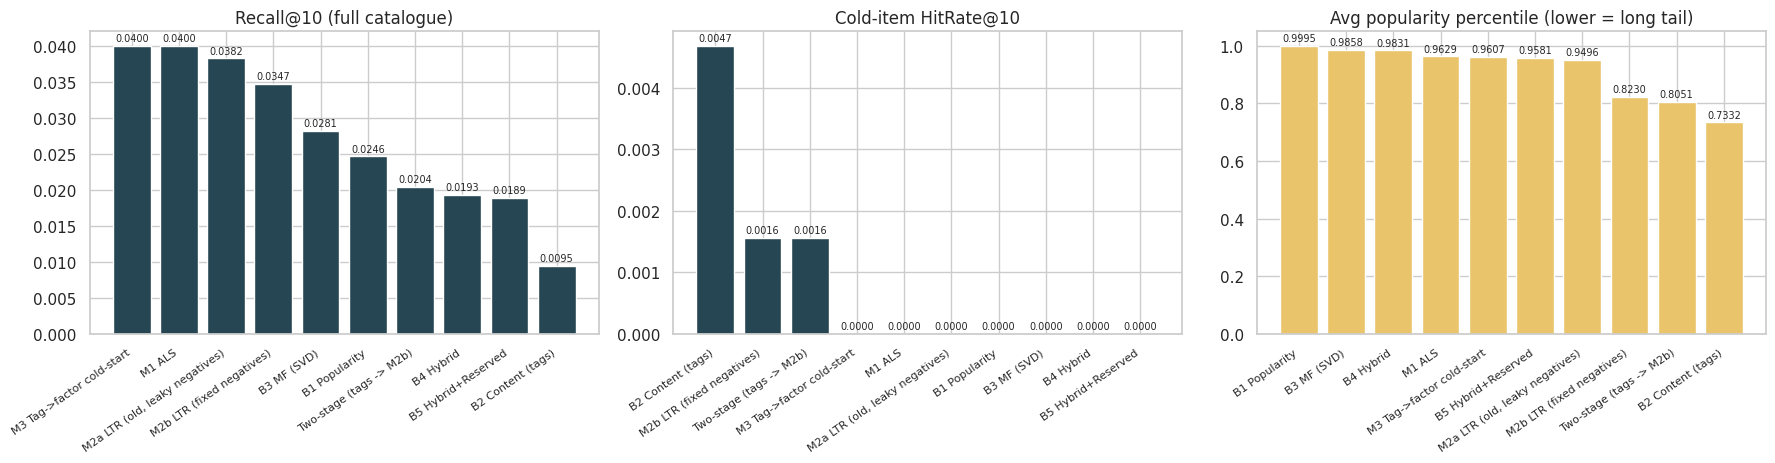

In [38]:
# Audience note  -  Main evaluation step 6:
# Verdict slide: which models beat the best baseline on the full catalogue.

# --- Main evaluation, step 6: verdict ---------------------------------------
BASE = ["B1 Popularity", "B2 Content (tags)", "B3 MF (SVD)"]
_b = clean_results[clean_results["model"].isin(BASE)]
bar_recall = float(_b[f"recall@{K}"].max())
bar_ndcg = float(_b[f"ndcg@{K}"].max())
bar_r_model = _b.loc[_b[f"recall@{K}"].idxmax(), "model"]
_p = clean_results[clean_results["model"] == "B1 Popularity"].iloc[0]
pop_cold, pop_cov, pop_pct2 = (
    float(_p[f"cold_item_hitrate@{K}"]), float(_p["catalogue_coverage"]),
    float(_p["avg_popularity_percentile"]),
)

print("=" * 78)
print("BAR TO BEAT (best of B1/B2/B3, full catalogue)")
print(f"  Recall@{K} = {bar_recall:.4f} ({bar_r_model})   NDCG@{K} = {bar_ndcg:.4f}")
print(f"  B1: cold-item HitRate = {pop_cold:.4f} | coverage = {pop_cov:.4f} | pop-pct = {pop_pct2:.4f}")
print("=" * 78)

vrows = []
for name in clean_results["model"]:
    if name in BASE:
        continue
    r = clean_results[clean_results["model"] == name].iloc[0]
    acc = (r[f"recall@{K}"] > bar_recall) or (r[f"ndcg@{K}"] > bar_ndcg)
    cold = bool(r[f"cold_item_hitrate@{K}"] > pop_cold)
    lt = bool(r["catalogue_coverage"] > pop_cov and r["avg_popularity_percentile"] < pop_pct2)
    if acc and cold:
        v = "PASS - more accurate AND reaches cold items"
    elif acc:
        v = "PARTIAL - more accurate, no cold-item lift" + (" (wider catalogue only)" if lt else "")
    elif cold:
        v = "PARTIAL - reaches cold items, not more accurate"
    else:
        v = "FAIL - no accuracy gain and no cold-item lift"
    vrows.append({
        "model": name, f"recall@{K}": r[f"recall@{K}"], f"ndcg@{K}": r[f"ndcg@{K}"],
        f"cold_item_hitrate@{K}": r[f"cold_item_hitrate@{K}"],
        "catalogue_coverage": r["catalogue_coverage"],
        "avg_popularity_percentile": r["avg_popularity_percentile"],
        "accuracy_beats_baselines": bool(acc), "reaches_cold_items": cold,
        "wider_longtail": lt, "verdict": v,
    })
clean_verdict = pd.DataFrame(vrows)
print("\n=== VERDICT ON THE FULL-CATALOGUE PROTOCOL ===")
display(clean_verdict)

# How much of the old M2 number was the shortcut?
_old = clean_results[clean_results["model"] == "M2a LTR (tag-pool negatives)"].iloc[0]
_new = clean_results[clean_results["model"] == "M2b LTR (fixed negatives)"].iloc[0]
print("\n--- Negative-sampling comparison (same full-catalogue protocol) ---")
print(f"M2a (tag-pool negatives): Recall@{K} = {_old[f'recall@{K}']:.4f}")
print(f"M2b (matched negatives):  Recall@{K} = {_new[f'recall@{K}']:.4f}")
print(f"Best baseline: {bar_recall:.4f} ({bar_r_model})")
if _new[f"recall@{K}"] > _old[f"recall@{K}"]:
    print("Matched negatives help: M2b beats M2a under the same ranking protocol.")
else:
    print("Matched negatives did not beat tag-pool negatives on Recall in this run.")

clean_verdict.to_csv(OUT_DIR / "clean_verdict.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, col, title in [
    (axes[0], f"recall@{K}", f"Recall@{K} (full catalogue)"),
    (axes[1], f"cold_item_hitrate@{K}", f"Cold-item HitRate@{K}"),
    (axes[2], "avg_popularity_percentile", "Avg popularity percentile (lower = long tail)"),
]:
    d = clean_results.sort_values(col, ascending=False)
    b = ax.bar(d["model"], d[col], color="#264653" if col != "avg_popularity_percentile" else "#e9c46a")
    ax.set_title(title)
    ax.set_xticklabels(d["model"], rotation=35, ha="right", fontsize=8)
    ax.bar_label(b, fmt="%.4f", padding=2, fontsize=7)
plt.tight_layout()
plt.show()


In [39]:
# Audience note  -  Main evaluation step 7:
# Integrity checks (random floor, feature integrity, deterministic scoring).

# --- Main evaluation, step 7: integrity checks --------------------------------
# Checks: chance floor, feature integrity, and deterministic scoring.
_floor_rng = np.random.RandomState(RANDOM_STATE)


def rank_random(u, seen_idx):
    s = _floor_rng.rand(n_games)
    if len(seen_idx):
        s[seen_idx] = -np.inf
    part = np.argpartition(-s, TOP_N - 1)[:TOP_N]
    return part[np.argsort(-s[part])]


_pop_only_model, _pop_only_mode = _fit_ranker(
    X_v2[:, [FEATURE_NAMES_V2.index("log_pop")]], y_v2, gp
)


def s_pop_only(u, ctx=None):
    F = features_full(u, ctx or CTX_FULL)[:, [FEATURE_NAMES_V2.index("log_pop")]]
    return (_pop_only_model.predict_proba(F)[:, 1] if _pop_only_mode == "proba"
            else _pop_only_model.predict(F))


probe2, _, _, _ = eval_clean([
    ("C1 Random", rank_random),
    ("C4 LTR popularity-only", make_ranker(s_pop_only)),
])
display(probe2[["model", f"recall@{K}", f"ndcg@{K}", f"hitrate@{K}"]])

_rand2 = float(probe2.loc[probe2["model"] == "C1 Random", f"recall@{K}"].iloc[0])
_pop2 = float(probe2.loc[probe2["model"] == "C4 LTR popularity-only", f"recall@{K}"].iloc[0])
_b1_2 = float(clean_results.loc[clean_results["model"] == "B1 Popularity", f"recall@{K}"].iloc[0])
_m2b = float(_new[f"recall@{K}"])

# There is no candidate list any more -- scores are computed over the whole index
# space -- so order-dependence is structurally impossible. What is still worth
# verifying is that scoring is deterministic across repeat calls.
_dev = 0.0
for u in clean_users[:50]:
    a = np.asarray(s_ltr_v2(u), dtype=float)
    b = np.asarray(s_ltr_v2(u), dtype=float)
    _dev = max(_dev, float(np.max(np.abs(a - b))))

# Chance-level Recall@K when ranking the whole catalogue is about K / n_candidates,
# so the floor check scales with the catalogue instead of using a fixed constant.
CHANCE_RECALL = K / max(n_games, 1)
# The popularity-only ranker uses a single feature, so a tree bins it into a few dozen
# leaves and hundreds of games end up sharing the top score -- the top 10 is then chosen
# arbitrarily inside a huge tie, which drags its Recall below B1 for a reason that has
# nothing to do with calibration. The meaningful check is whether it is MONOTONE in
# popularity, so that is what gets tested.
from scipy.stats import spearmanr

# The popularity-only ranker is reported as a DESCRIPTIVE diagnostic, not a pass/fail.
# Requiring it to reproduce B1 was a flawed premise: a LambdaRank model handed only
# popularity is under no obligation to be monotone in it -- if mid-popularity games are
# the better targets in this data, the correct fit is non-monotone. Its Recall also sits
# below B1 for a mechanical reason, since a single-feature tree is a step function and
# hundreds of games share the top score, so the top 10 is drawn arbitrarily from a tie.
_ps = np.asarray(s_pop_only(clean_users[0]), dtype=float)
_vals, _inv = np.unique(_ps, return_inverse=True)
_binpop = np.bincount(_inv, weights=CTX_FULL.pop.astype(np.float64)) / np.bincount(_inv)
_sp_bin = float(spearmanr(_vals, _binpop).correlation) if len(_vals) > 2 else 1.0
_top_tie = int((_ps >= np.sort(_ps)[-K]).sum())
print(f"\nPopularity-only ranker (diagnostic): {len(_vals):,} distinct scores over "
      f"{n_games:,} games, {_top_tie:,} tied at or above the 10th score,")
print(f"  rank correlation with popularity across score bins = {_sp_bin:.4f}, "
      f"Recall@{K} {_pop2:.5f} vs B1 {_b1_2:.5f}")

# What a pipeline bug WOULD break is feature integrity: the columns the models train on
# must be exactly the quantities they claim to be. That is checkable exactly, so it is
# checked exactly, on a sample of users.
_integrity = True
_bad = []
for u in clean_users[:25]:
    F = features_full(u, CTX_FULL)
    for col, name, expected in [
        (0, "log_pop", np.log1p(CTX_FULL.pop)),
        (5, "item_pop_pct", CTX_FULL.pop_pct),
        (6, "is_cold_item", CTX_FULL.cold_mask.astype(np.float32)),
        (7, "tag_cosine", s_content(u)),
        (8, "svd_score", s_svd(u)),
        (9, "als_score", s_als(u)),
    ]:
        if not np.allclose(F[:, col], np.asarray(expected, dtype=np.float32), atol=1e-5):
            _integrity = False
            _bad.append(name)
if _integrity:
    print("Feature integrity: every column matches the quantity it claims to be.")
else:
    print("Feature integrity FAILED for:", ", ".join(sorted(set(_bad))))

checks = [
    (f"Random ranker sits at chance ({CHANCE_RECALL:.5f})", _rand2 <= 5 * CHANCE_RECALL),
    ("Feature columns are exactly the quantities they claim to be", _integrity),
    ("Fixed ranker is far above chance", _m2b > 5 * CHANCE_RECALL),
    ("Scoring is deterministic across repeat calls", _dev < 1e-9),
]
print("\n" + "=" * 78)
print("FULL-CATALOGUE PROTOCOL CHECKS")
print("=" * 78)
for lab, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}] {lab}")
print(f"\n  chance-level Recall@{K}      = {CHANCE_RECALL:.5f} (K / {n_games:,} candidates)")
print(f"  random ranker Recall@{K}     = {_rand2:.5f}")
print(f"  popularity-only ranker      = {_pop2:.5f}  (B1 = {_b1_2:.5f})")
print(f"  fixed ranker M2b            = {_m2b:.5f}")
print("=" * 78)
if all(o for _, o in checks):
    print("Protocol checks passed. These numbers are the ones to report.")
else:
    print("A check FAILED -- resolve it before reporting anything from this section.")

pd.DataFrame({"check": [c for c, _ in checks], "passed": [bool(o) for _, o in checks]}).to_csv(
    OUT_DIR / "clean_protocol_checks.csv", index=False
)
print("Saved", OUT_DIR / "clean_protocol_checks.csv")


C1 Random:   0%|          | 0/572 [00:00<?, ?it/s]

C4 LTR popularity-only:   0%|          | 0/572 [00:00<?, ?it/s]

,model,recall@10,ndcg@10,hitrate@10
0,C1 Random,0.000554,0.002605,0.027972
1,C4 LTR popularity-only,0.003596,0.007751,0.099650



Popularity-only ranker (diagnostic): 251 distinct scores over 10,738 games, 11 tied at or above the 10th score,
  rank correlation with popularity across score bins = 0.8600, Recall@10 0.00360 vs B1 0.02462
Feature integrity: every column matches the quantity it claims to be.

FULL-CATALOGUE PROTOCOL CHECKS
  [PASS] Random ranker sits at chance (0.00093)
  [PASS] Feature columns are exactly the quantities they claim to be
  [PASS] Fixed ranker is far above chance
  [PASS] Scoring is deterministic across repeat calls

  chance-level Recall@10      = 0.00093 (K / 10,738 candidates)
  random ranker Recall@10     = 0.00055
  popularity-only ranker      = 0.00360  (B1 = 0.02462)
  fixed ranker M2b            = 0.03470
Protocol checks passed. These numbers are the ones to report.
Saved /kaggle/working/processed/clean_protocol_checks.csv


# Is the ALS win real? Where can cold-start actually be measured?

Two audience questions after the clean table:

1. **Significance.** Does M1 ALS beat popularity on the *same* users, not just on
   average? We use paired tests (bootstrap CI + Wilcoxon) with Holm correction.
2. **Cold games on the main list.** Can an obscure game crack the top-10 when it is
   competing against thousands of hits? Usually no  -  so we also evaluate a
   **cold-items-only** surface ("hidden gems"), which is the fair question for that
   product shelf.


In [40]:
# --- One pass: per-user metrics (for significance) + cold hits at depth ------
SIG_METHODS = [
    "B1 Popularity", "B3 MF (SVD)", "M1 ALS",
    "M2b LTR (fixed negatives)", "M3 Tag->factor cold-start",
]
_rank_by_name = dict(CLEAN_METHODS)
_missing = [m for m in SIG_METHODS if m not in _rank_by_name]
if _missing:
    raise RuntimeError("unknown methods: " + ", ".join(_missing))

DEPTHS = (10, 50, 100)
_log2 = np.log2(np.arange(2, TOP_N + 2))

per_user = {}          # method -> {"recall": arr, "ndcg": arr} aligned to clean_users
cold_depth_rows = []

for name in SIG_METHODS:
    rank = _rank_by_name[name]
    rec, ndc = [], []
    cold_hits = {d: 0 for d in DEPTHS}
    cold_total = 0
    for u in tqdm(clean_users, desc=name, leave=False):
        rel = clean_truth[u]
        top = rank(u, clean_seen[u])
        hit = np.isin(top, rel)
        rec.append(hit[:K].sum() / len(rel))
        idcg = float((1.0 / _log2[: min(len(rel), K)]).sum())
        ndc.append(float((hit[:K] / _log2[:K]).sum()) / idcg if idcg else 0.0)

        cold_rel = rel[CTX_FULL.cold_mask[rel]]
        if len(cold_rel):
            cold_total += len(cold_rel)
            for d in DEPTHS:
                cold_hits[d] += int(np.isin(cold_rel, top[:d]).sum())
    per_user[name] = {"recall": np.array(rec), "ndcg": np.array(ndc)}
    row = {"model": name, "cold_relevant_n": cold_total}
    for d in DEPTHS:
        row[f"cold_item_hitrate@{d}"] = cold_hits[d] / cold_total if cold_total else np.nan
    cold_depth_rows.append(row)

cold_depth = pd.DataFrame(cold_depth_rows)
print(f"\nRelevant cold items available to hit: {int(cold_depth['cold_relevant_n'].iloc[0]):,}")
print("=== COLD-ITEM HIT RATE AT INCREASING DEPTH (full catalogue) ===")
display(cold_depth)
print(f"Chance level for a cold item at depth d out of {n_games:,} candidates: "
      + ", ".join(f"@{d}={d / n_games:.5f}" for d in DEPTHS))
cold_depth.to_csv(OUT_DIR / "cold_item_depth.csv", index=False)


B1 Popularity:   0%|          | 0/572 [00:00<?, ?it/s]

B3 MF (SVD):   0%|          | 0/572 [00:00<?, ?it/s]

M1 ALS:   0%|          | 0/572 [00:00<?, ?it/s]

M2b LTR (fixed negatives):   0%|          | 0/572 [00:00<?, ?it/s]

M3 Tag->factor cold-start:   0%|          | 0/572 [00:00<?, ?it/s]


Relevant cold items available to hit: 641
=== COLD-ITEM HIT RATE AT INCREASING DEPTH (full catalogue) ===


,model,cold_relevant_n,cold_item_hitrate@10,cold_item_hitrate@50,cold_item_hitrate@100
0,B1 Popularity,641,0.00000,0.0000,0.000000
1,B3 MF (SVD),641,0.00000,0.0000,0.000000
2,M1 ALS,641,0.00000,0.0000,0.000000
3,M2b LTR (fixed negatives),641,0.00156,0.0078,0.015601
4,M3 Tag->factor cold-start,641,0.00000,0.0078,0.018721


Chance level for a cold item at depth d out of 10,738 candidates: @10=0.00093, @50=0.00466, @100=0.00931


In [41]:
# --- Paired significance tests ----------------------------------------------
# Per-user paired comparisons: same users, same candidates, so the pairing removes
# user difficulty from the comparison. Bootstrap CI on the mean difference plus a
# Wilcoxon signed-rank test, then Holm correction across all tests run here.
from scipy.stats import wilcoxon

N_BOOT = 10_000
COMPARISONS = [
    ("M1 ALS", "B3 MF (SVD)"),
    ("M1 ALS", "B1 Popularity"),
    ("M2b LTR (fixed negatives)", "B3 MF (SVD)"),
    ("M1 ALS", "M2b LTR (fixed negatives)"),
    ("M3 Tag->factor cold-start", "M1 ALS"),
]


def paired_test(a, b, seed=RANDOM_STATE, n_boot=N_BOOT):
    d = np.asarray(a, dtype=float) - np.asarray(b, dtype=float)
    if np.allclose(d, 0.0):
        # Identical rankers (e.g. the dislike penalty tuned to lambda=0 makes M4
        # the same model as M1 ALS). Wilcoxon is undefined on an all-zero
        # difference vector, so report p=1 rather than letting NaN leak into the
        # Holm column and print as a failed test.
        return 0.0, 0.0, 0.0, 1.0, 1.0
    rs = np.random.RandomState(seed)
    idx = rs.randint(0, len(d), size=(n_boot, len(d)))
    boots = d[idx].mean(axis=1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    p_boot = 2 * min((boots <= 0).mean(), (boots >= 0).mean())
    try:
        p_w = float(wilcoxon(a, b, zero_method="wilcox").pvalue)
    except Exception:
        p_w = np.nan
    return float(d.mean()), float(lo), float(hi), float(min(p_boot, 1.0)), p_w


rows = []
for metric in ("recall", "ndcg"):
    for m_a, m_b in COMPARISONS:
        diff, lo, hi, pb, pw = paired_test(per_user[m_a][metric], per_user[m_b][metric])
        rows.append({
            "metric": f"{metric}@{K}", "A": m_a, "B": m_b,
            "mean_A": float(per_user[m_a][metric].mean()),
            "mean_B": float(per_user[m_b][metric].mean()),
            "diff": diff, "ci_low": lo, "ci_high": hi,
            "p_bootstrap": pb, "p_wilcoxon": pw,
        })
sig = pd.DataFrame(rows)

# Holm-Bonferroni across every test in this table
order = np.argsort(sig["p_wilcoxon"].to_numpy())
m = len(sig)
adj = np.empty(m)
running = 0.0
for rank_i, pos in enumerate(order):
    val = (m - rank_i) * sig["p_wilcoxon"].iloc[pos]
    running = max(running, min(val, 1.0))
    adj[pos] = running
sig["p_holm"] = adj
sig["significant_0.05"] = sig["p_holm"] < 0.05
sig["ci_excludes_zero"] = (sig["ci_low"] > 0) | (sig["ci_high"] < 0)

print(f"=== PAIRED TESTS on {len(clean_users):,} users ({N_BOOT:,} bootstrap resamples) ===")
display(sig.round(6))
sig.to_csv(OUT_DIR / "significance_tests.csv", index=False)

print("\n--- Plain reading ---")
for _, r in sig.iterrows():
    verdict = ("SIGNIFICANT" if r["significant_0.05"] and r["ci_excludes_zero"]
               else "NOT significant")
    direction = "higher" if r["diff"] > 0 else "lower"
    print(f"{r['metric']}: {r['A']} is {abs(r['diff']):.5f} {direction} than {r['B']} "
          f"[95% CI {r['ci_low']:+.5f}, {r['ci_high']:+.5f}], Holm p={r['p_holm']:.4g} "
          f"-> {verdict}")

_key = sig[(sig["metric"] == f"recall@{K}") & (sig["A"] == "M1 ALS")
           & (sig["B"] == "B3 MF (SVD)")].iloc[0]
# The signed-rank test and the bootstrap CI answer different questions and can disagree:
# Wilcoxon asks whether MORE USERS improve than worsen, while the CI asks whether the
# MEAN gain is reliably above zero. The mean is dominated by users with many relevant
# items, so a consistent-but-small gain can be significant on one and marginal on the
# other. Collapsing that into a single pass/fail throws away the useful part, so both are
# reported for each headline metric.
print("\n" + "=" * 78)
print("KEY COMPARISON: M1 ALS vs the best baseline (B3 MF (SVD))")
print("=" * 78)
for _metric in (f"recall@{K}", f"ndcg@{K}"):
    r = sig[(sig["metric"] == _metric) & (sig["A"] == "M1 ALS")
            & (sig["B"] == "B3 MF (SVD)")].iloc[0]
    consistent = bool(r["p_holm"] < 0.05)
    magnitude = bool(r["ci_excludes_zero"])
    print(f"\n{_metric}: {r['mean_B']:.5f} -> {r['mean_A']:.5f} "
          f"({r['diff']:+.5f}, 95% CI [{r['ci_low']:+.5f}, {r['ci_high']:+.5f}])")
    print(f"  more users improve than worsen : {'YES' if consistent else 'no'} "
          f"(Wilcoxon, Holm p={r['p_holm']:.4g})")
    print(f"  mean gain reliably above zero  : {'YES' if magnitude else 'no'} "
          f"(bootstrap CI {'excludes' if magnitude else 'includes'} zero)")
    if consistent and magnitude and r["diff"] > 0:
        print("  -> Report as a real improvement, quoting the effect size and CI.")
    elif consistent and r["diff"] > 0:
        print("  -> Report as a consistent but marginal improvement: the direction is")
        print("     reliable across users, the average size is not. Quote both tests.")
    elif magnitude and r["diff"] < 0:
        print("  -> The baseline is significantly better on this metric.")
    else:
        print("  -> Report as no significant difference on this metric.")
print("\n" + "=" * 78)


=== PAIRED TESTS on 572 users (10,000 bootstrap resamples) ===


,metric,A,B,mean_A,mean_B,diff,ci_low,ci_high,p_bootstrap,p_wilcoxon,p_holm,significant_0.05,ci_excludes_zero
0,recall@10,M1 ALS,B3 MF (SVD),0.039967,0.028109,0.011859,0.004509,0.020370,0.0008,0.001012,0.006074,True,True
1,recall@10,M1 ALS,B1 Popularity,0.039967,0.024623,0.015345,0.007003,0.024418,0.0008,0.000003,0.000020,True,True
2,recall@10,M2b LTR (fixed negatives),B3 MF (SVD),0.034695,0.028109,0.006587,-0.000262,0.014156,0.0614,0.649296,1.000000,False,False
3,recall@10,M1 ALS,M2b LTR (fixed negatives),0.039967,0.034695,0.005272,-0.004211,0.015184,0.2614,0.019244,0.096222,False,False
4,recall@10,M3 Tag->factor cold-start,M1 ALS,0.039967,0.039967,0.000000,0.000000,0.000000,1.0000,1.000000,1.000000,False,False
5,ndcg@10,M1 ALS,B3 MF (SVD),0.121838,0.096468,0.025370,0.013796,0.037650,0.0000,0.000055,0.000383,True,True
6,ndcg@10,M1 ALS,B1 Popularity,0.121838,0.076684,0.045154,0.031315,0.059433,0.0000,0.000000,0.000000,True,True
7,ndcg@10,M2b LTR (fixed negatives),B3 MF (SVD),0.092022,0.096468,-0.004447,-0.016367,0.007141,0.4626,0.736639,1.000000,False,False
8,ndcg@10,M1 ALS,M2b LTR (fixed negatives),0.121838,0.092022,0.029817,0.018887,0.041124,0.0000,0.000000,0.000002,True,True
9,ndcg@10,M3 Tag->factor cold-start,M1 ALS,0.121838,0.121838,0.000000,0.000000,0.000000,1.0000,1.000000,1.000000,False,False



--- Plain reading ---
recall@10: M1 ALS is 0.01186 higher than B3 MF (SVD) [95% CI +0.00451, +0.02037], Holm p=0.006074 -> SIGNIFICANT
recall@10: M1 ALS is 0.01534 higher than B1 Popularity [95% CI +0.00700, +0.02442], Holm p=2.002e-05 -> SIGNIFICANT
recall@10: M2b LTR (fixed negatives) is 0.00659 higher than B3 MF (SVD) [95% CI -0.00026, +0.01416], Holm p=1 -> NOT significant
recall@10: M1 ALS is 0.00527 higher than M2b LTR (fixed negatives) [95% CI -0.00421, +0.01518], Holm p=0.09622 -> NOT significant
recall@10: M3 Tag->factor cold-start is 0.00000 lower than M1 ALS [95% CI +0.00000, +0.00000], Holm p=1 -> NOT significant
ndcg@10: M1 ALS is 0.02537 higher than B3 MF (SVD) [95% CI +0.01380, +0.03765], Holm p=0.0003826 -> SIGNIFICANT
ndcg@10: M1 ALS is 0.04515 higher than B1 Popularity [95% CI +0.03132, +0.05943], Holm p=5.058e-08 -> SIGNIFICANT
ndcg@10: M2b LTR (fixed negatives) is 0.00445 lower than B3 MF (SVD) [95% CI -0.01637, +0.00714], Holm p=1 -> NOT significant
ndcg@10: M1 AL

Cold-only task: 2,761 cold candidates, 222 of 572 users have a relevant cold item
Chance Recall@10 on this task: 0.00362


cold-only: B1 Popularity:   0%|          | 0/222 [00:00<?, ?it/s]

cold-only: B2 Content (tags):   0%|          | 0/222 [00:00<?, ?it/s]

cold-only: B3 MF (SVD):   0%|          | 0/222 [00:00<?, ?it/s]

cold-only: B4 Hybrid:   0%|          | 0/222 [00:00<?, ?it/s]

...

cold-only: Two-stage (tags -> M2b):   0%|          | 0/222 [00:00<?, ?it/s]

cold-only: C0 Random (floor):   0%|          | 0/222 [00:00<?, ?it/s]


=== COLD-ITEMS-ONLY RANKING (candidates restricted to cold games) ===


,model,cold_recall@10,cold_recall@50,cold_ndcg@10,cold_hitrate@10,cold_items_surfaced,cold_catalogue_coverage
0,M2b LTR (fixed negatives),0.042042,0.112861,0.021233,0.063063,666,0.241217
1,Two-stage (tags -> M2b),0.031532,0.088063,0.017856,0.054054,759,0.274900
2,M3 Tag->factor cold-start,0.027276,0.110745,0.014725,0.054054,1069,0.387179
3,M1 ALS,0.023836,0.113782,0.016457,0.036036,700,0.253531
4,B4 Hybrid,0.023493,0.079329,0.013603,0.040541,669,0.242304
5,B5 Hybrid+Reserved,0.023493,0.079329,0.013603,0.040541,669,0.242304
6,B2 Content (tags),0.020565,0.069028,0.012388,0.049550,858,0.310757
7,M2a LTR (tag-pool negatives),0.017106,0.038760,0.011127,0.054054,674,0.244114
8,B3 MF (SVD),0.004617,0.044984,0.001740,0.009009,365,0.132198
9,C0 Random (floor),0.004494,0.018065,0.004810,0.022523,1497,0.542195



--- Reading the cold-only task ---
Analytic chance (10/2,761) : 0.00362
Random floor (measured)  : 0.00449
Bar to clear             : 0.00449
Popularity               : 0.00135
Best method              : M2b LTR (fixed negatives) at 0.04204 (9.4x the bar)

Cold inventory IS rankable once it is not competing with the warm catalogue.
That supports shipping cold games on a dedicated surface driven by this model,
rather than trying to force them into the main top-10.


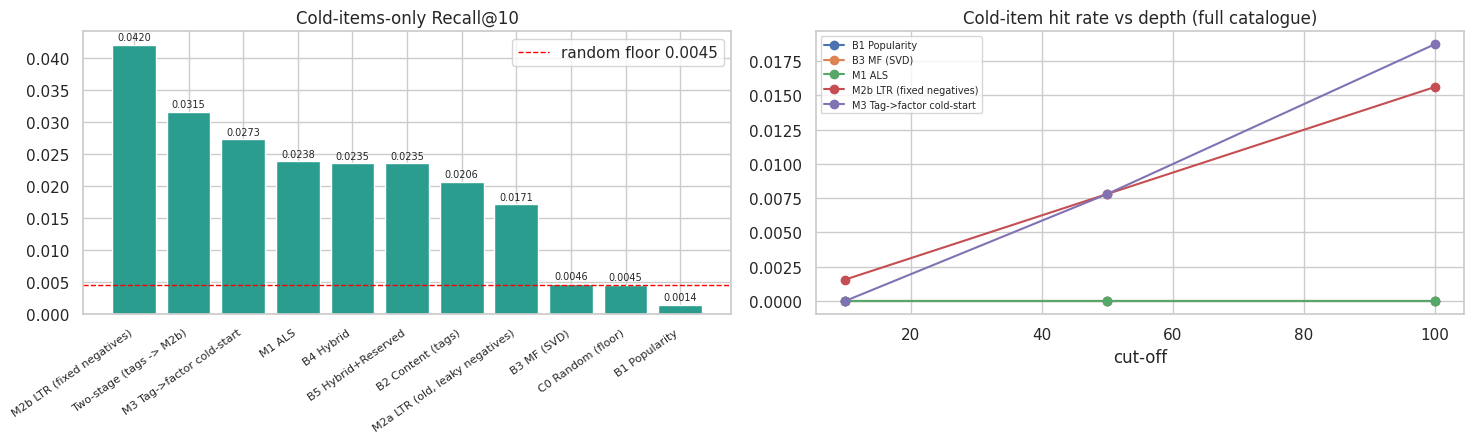

In [42]:
# --- Cold-items-only ranking: the "hidden gems" surface ----------------------
# Candidates are restricted to cold games (plus the user's seen items removed), so the
# question becomes "among games with almost no history, can we pick the right one?"
# rather than "can a cold game outrank 8,000 warm ones".
warm_all_idx = np.where(~CTX_FULL.cold_mask)[0]
n_cold_items = int(CTX_FULL.cold_mask.sum())

cold_truth = {}
for u in clean_users:
    rel = clean_truth[u]
    c = rel[CTX_FULL.cold_mask[rel]]
    if len(c):
        cold_truth[u] = c
cold_eval_users = list(cold_truth)
print(f"Cold-only task: {n_cold_items:,} cold candidates, "
      f"{len(cold_eval_users):,} of {len(clean_users):,} users have a relevant cold item")
print(f"Chance Recall@{K} on this task: {K / max(n_cold_items, 1):.5f}")

if len(cold_eval_users) < 30:
    print("WARNING: too few users with a relevant cold item -- treat this table as")
    print("         indicative only and say so in the report.")

_cold_rng = np.random.RandomState(RANDOM_STATE)


def rank_random_cold(u, blocked):
    s = _cold_rng.rand(n_games)
    s[blocked] = -np.inf
    part = np.argpartition(-s, TOP_N - 1)[:TOP_N]
    return part[np.argsort(-s[part])]


cold_rows = []
for name, rank in list(CLEAN_METHODS) + [("C0 Random (floor)", rank_random_cold)]:
    rec10, rec50, ndc, hits = [], [], [], []
    surfaced = set()
    for u in tqdm(cold_eval_users, desc=f"cold-only: {name}", leave=False):
        blocked = np.union1d(clean_seen[u], warm_all_idx)
        rel = cold_truth[u]
        top = rank(u, blocked)
        hit = np.isin(top, rel)
        rec10.append(hit[:K].sum() / len(rel))
        rec50.append(hit[:50].sum() / len(rel))
        idcg = float((1.0 / _log2[: min(len(rel), K)]).sum())
        ndc.append(float((hit[:K] / _log2[:K]).sum()) / idcg if idcg else 0.0)
        hits.append(float(hit[:K].any()))
        surfaced.update(top[:K].tolist())
    cold_rows.append({
        "model": name,
        f"cold_recall@{K}": float(np.mean(rec10)),
        "cold_recall@50": float(np.mean(rec50)),
        f"cold_ndcg@{K}": float(np.mean(ndc)),
        f"cold_hitrate@{K}": float(np.mean(hits)),
        "cold_items_surfaced": len(surfaced),
        "cold_catalogue_coverage": len(surfaced) / max(n_cold_items, 1),
    })

cold_only = pd.DataFrame(cold_rows).sort_values(f"cold_recall@{K}", ascending=False)
print("\n=== COLD-ITEMS-ONLY RANKING (candidates restricted to cold games) ===")
display(cold_only.reset_index(drop=True))
cold_only.to_csv(OUT_DIR / "cold_only_results.csv", index=False)

_floor = float(cold_only.loc[cold_only["model"] == "C0 Random (floor)", f"cold_recall@{K}"].iloc[0])
_best = cold_only[cold_only["model"] != "C0 Random (floor)"].iloc[0]
_pop_cold = float(cold_only.loc[cold_only["model"] == "B1 Popularity", f"cold_recall@{K}"].iloc[0])
# An empirical random floor of exactly 0.000 makes "beats twice the floor" a bar that
# cannot be failed, so the bar is the analytic chance rate of landing a relevant cold
# item in K draws from the cold catalogue, whichever is larger.
_chance_cold = K / max(n_cold_items, 1)
_bar_cold = max(_floor, _chance_cold)
print("\n--- Reading the cold-only task ---")
print(f"Analytic chance ({K}/{n_cold_items:,}) : {_chance_cold:.5f}")
print(f"Random floor (measured)  : {_floor:.5f}")
print(f"Bar to clear             : {_bar_cold:.5f}")
print(f"Popularity               : {_pop_cold:.5f}")
print(f"Best method              : {_best['model']} at {_best[f'cold_recall@{K}']:.5f} "
      f"({_best[f'cold_recall@{K}'] / max(_bar_cold, 1e-12):.1f}x the bar)")
if _best[f"cold_recall@{K}"] > 2 * _bar_cold and _best[f"cold_recall@{K}"] > _pop_cold:
    print("\nCold inventory IS rankable once it is not competing with the warm catalogue.")
    print("That supports shipping cold games on a dedicated surface driven by this model,")
    print("rather than trying to force them into the main top-10.")
else:
    print("\nEven with warm games removed, no method beats chance by a useful margin.")
    print("Report this as a negative result: the tag signal in this dataset is not strong")
    print("enough to rank cold inventory, and say what would be needed instead.")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
d = cold_only.sort_values(f"cold_recall@{K}", ascending=False)
b = axes[0].bar(d["model"], d[f"cold_recall@{K}"], color="#2a9d8f")
axes[0].axhline(_floor, color="red", ls="--", lw=1, label=f"random floor {_floor:.4f}")
axes[0].set_title(f"Cold-items-only Recall@{K}")
axes[0].set_xticklabels(d["model"], rotation=35, ha="right", fontsize=8)
axes[0].bar_label(b, fmt="%.4f", padding=2, fontsize=7)
axes[0].legend()
dd = cold_depth.melt(id_vars="model", value_vars=[f"cold_item_hitrate@{d_}" for d_ in DEPTHS],
                     var_name="depth", value_name="hitrate")
for mdl in cold_depth["model"]:
    sel = dd[dd["model"] == mdl]
    axes[1].plot([10, 50, 100], sel["hitrate"], marker="o", label=mdl)
axes[1].set_title("Cold-item hit rate vs depth (full catalogue)")
axes[1].set_xlabel("cut-off")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()


# Is the cold-start (item) result real?

We dig into the cold-only ranking task with per-user metrics, confidence intervals, and
a cluster bootstrap over users (items from the same user are not independent).

**How to explain this slide:** collaborative filtering needs history. Tags + a
tag->factor map (M3) are how we give cold games a fighting chance  -  but only when we
restrict the candidate set to cold games. On the unrestricted main list, cold hit rate
at 10 is essentially zero for everyone, including popularity.


In [43]:
# --- Cold-only task with per-user detail, CIs and paired tests --------------
if "paired_test" not in globals():
    from scipy.stats import wilcoxon

    def paired_test(a, b, seed=RANDOM_STATE, n_boot=10_000):
        d = np.asarray(a, float) - np.asarray(b, float)
        rs = np.random.RandomState(seed)
        boots = d[rs.randint(0, len(d), size=(n_boot, len(d)))].mean(axis=1)
        lo, hi = np.percentile(boots, [2.5, 97.5])
        p_boot = 2 * min((boots <= 0).mean(), (boots >= 0).mean())
        try:
            p_w = float(wilcoxon(a, b, zero_method="wilcox").pvalue)
        except Exception:
            p_w = np.nan
        return float(d.mean()), float(lo), float(hi), float(min(p_boot, 1.0)), p_w

COLD_CHANCE = K / max(n_cold_items, 1)
_n_rel = np.array([len(cold_truth[u]) for u in cold_eval_users])
print(f"Cold-only task sample: {len(cold_eval_users):,} users, "
      f"{int(_n_rel.sum()):,} relevant cold items")
print(f"  relevant cold items per user: mean {_n_rel.mean():.2f}, median "
      f"{np.median(_n_rel):.0f}, max {_n_rel.max()}")
print(f"  chance Recall@{K} = {COLD_CHANCE:.5f} ({K} / {n_cold_items:,} cold candidates)")

COLD_SIG_METHODS = [
    "M3 Tag->factor cold-start", "B2 Content (tags)", "M1 ALS",
    "M2b LTR (fixed negatives)", "B1 Popularity", "B3 MF (SVD)",
]
_rank_by_name = dict(CLEAN_METHODS)
_log2c = np.log2(np.arange(2, TOP_N + 2))

cold_per_user = {}
for name in COLD_SIG_METHODS:
    rank = _rank_by_name[name]
    rec, ndc = [], []
    for u in tqdm(cold_eval_users, desc=f"cold-only detail: {name}", leave=False):
        blocked = np.union1d(clean_seen[u], warm_all_idx)
        rel = cold_truth[u]
        hit = np.isin(rank(u, blocked), rel)
        rec.append(hit[:K].sum() / len(rel))
        idcg = float((1.0 / _log2c[: min(len(rel), K)]).sum())
        ndc.append(float((hit[:K] / _log2c[:K]).sum()) / idcg if idcg else 0.0)
    cold_per_user[name] = {"recall": np.array(rec), "ndcg": np.array(ndc)}

# --- Is each method above chance? bootstrap CI on the absolute mean ---------
rs = np.random.RandomState(RANDOM_STATE)
abs_rows = []
for name in COLD_SIG_METHODS:
    v = cold_per_user[name]["recall"]
    boots = v[rs.randint(0, len(v), size=(10_000, len(v)))].mean(axis=1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    abs_rows.append({
        "model": name, f"cold_recall@{K}": float(v.mean()),
        "ci_low": float(lo), "ci_high": float(hi),
        "vs_chance": float(v.mean() / COLD_CHANCE) if COLD_CHANCE else np.nan,
        "above_chance": bool(lo > COLD_CHANCE),
        "users_with_a_hit": int((v > 0).sum()),
    })
cold_abs = pd.DataFrame(abs_rows).sort_values(f"cold_recall@{K}", ascending=False)
print(f"\n=== COLD-ONLY: absolute performance vs chance ({COLD_CHANCE:.5f}) ===")
display(cold_abs.reset_index(drop=True))
cold_abs.to_csv(OUT_DIR / "cold_only_ci.csv", index=False)

# --- Is M3 better than the alternatives? paired tests -----------------------
COLD_COMPARISONS = [
    ("M3 Tag->factor cold-start", "B1 Popularity"),
    ("M3 Tag->factor cold-start", "B2 Content (tags)"),
    ("M3 Tag->factor cold-start", "M1 ALS"),
    ("M3 Tag->factor cold-start", "M2b LTR (fixed negatives)"),
    ("M3 Tag->factor cold-start", "B3 MF (SVD)"),
]
rows = []
for metric in ("recall", "ndcg"):
    for a, b in COLD_COMPARISONS:
        diff, lo, hi, pb, pw = paired_test(cold_per_user[a][metric], cold_per_user[b][metric])
        rows.append({
            "metric": f"cold_{metric}@{K}", "A": a, "B": b,
            "mean_A": float(cold_per_user[a][metric].mean()),
            "mean_B": float(cold_per_user[b][metric].mean()),
            "diff": diff, "ci_low": lo, "ci_high": hi,
            "p_bootstrap": pb, "p_wilcoxon": pw,
        })
cold_sig = pd.DataFrame(rows)

order = np.argsort(cold_sig["p_wilcoxon"].to_numpy())
m = len(cold_sig)
adj, running = np.empty(m), 0.0
for rank_i, pos in enumerate(order):
    running = max(running, min((m - rank_i) * cold_sig["p_wilcoxon"].iloc[pos], 1.0))
    adj[pos] = running
cold_sig["p_holm"] = adj
cold_sig["consistent"] = cold_sig["p_holm"] < 0.05
cold_sig["ci_excludes_zero"] = (cold_sig["ci_low"] > 0) | (cold_sig["ci_high"] < 0)

print("\n=== COLD-ONLY: paired tests, M3 against the alternatives ===")
display(cold_sig.round(6))
cold_sig.to_csv(OUT_DIR / "cold_significance.csv", index=False)

for _, r in cold_sig.iterrows():
    tag = ("ROBUST" if r["consistent"] and r["ci_excludes_zero"]
           else "consistent only" if r["consistent"]
           else "magnitude only" if r["ci_excludes_zero"] else "not significant")
    print(f"{r['metric']}: M3 vs {r['B']}: {r['diff']:+.5f} "
          f"[{r['ci_low']:+.5f}, {r['ci_high']:+.5f}] Holm p={r['p_holm']:.4g} -> {tag}")


Cold-only task sample: 222 users, 641 relevant cold items
  relevant cold items per user: mean 2.89, median 2, max 74
  chance Recall@10 = 0.00362 (10 / 2,761 cold candidates)


cold-only detail: M3 Tag->factor cold-start:   0%|          | 0/222 [00:00<?, ?it/s]

cold-only detail: B2 Content (tags):   0%|          | 0/222 [00:00<?, ?it/s]

cold-only detail: M1 ALS:   0%|          | 0/222 [00:00<?, ?it/s]

cold-only detail: M2b LTR (fixed negatives):   0%|          | 0/222 [00:00<?, ?it/s]

...


=== COLD-ONLY: absolute performance vs chance (0.00362) ===


,model,cold_recall@10,ci_low,ci_high,vs_chance,above_chance,users_with_a_hit
0,M2b LTR (fixed negatives),0.042042,0.020646,0.066817,11.607808,True,14
1,M3 Tag->factor cold-start,0.027276,0.010886,0.046609,7.530789,True,12
2,M1 ALS,0.023836,0.007508,0.044294,6.581212,True,8
3,B2 Content (tags),0.020565,0.007615,0.037351,5.678054,True,11
4,B3 MF (SVD),0.004617,0.000000,0.013739,1.274786,False,2
5,B1 Popularity,0.001351,0.000000,0.003829,0.373108,False,2



=== COLD-ONLY: paired tests, M3 against the alternatives ===


,metric,A,B,mean_A,mean_B,diff,ci_low,ci_high,p_bootstrap,p_wilcoxon,p_holm,consistent,ci_excludes_zero
0,cold_recall@10,M3 Tag->factor cold-start,B1 Popularity,0.027276,0.001351,0.025924,0.009506,0.045407,0.0002,0.003742,0.037416,True,True
1,cold_recall@10,M3 Tag->factor cold-start,B2 Content (tags),0.027276,0.020565,0.006710,-0.014802,0.029387,0.5596,0.490693,1.000000,False,False
2,cold_recall@10,M3 Tag->factor cold-start,M1 ALS,0.027276,0.023836,0.003439,-0.022837,0.029401,0.7966,0.791978,1.000000,False,False
3,cold_recall@10,M3 Tag->factor cold-start,M2b LTR (fixed negatives),0.027276,0.042042,-0.014766,-0.041044,0.010135,0.2508,0.282066,1.000000,False,False
4,cold_recall@10,M3 Tag->factor cold-start,B3 MF (SVD),0.027276,0.004617,0.022658,0.003078,0.043694,0.0230,0.016487,0.115412,False,True
5,cold_ndcg@10,M3 Tag->factor cold-start,B1 Popularity,0.014725,0.001812,0.012912,0.003876,0.023536,0.0022,0.013150,0.105203,False,True
6,cold_ndcg@10,M3 Tag->factor cold-start,B2 Content (tags),0.014725,0.012388,0.002337,-0.009110,0.014337,0.7114,0.747500,1.000000,False,False
7,cold_ndcg@10,M3 Tag->factor cold-start,M1 ALS,0.014725,0.016457,-0.001732,-0.017918,0.013827,0.8384,0.812639,1.000000,False,False
8,cold_ndcg@10,M3 Tag->factor cold-start,M2b LTR (fixed negatives),0.014725,0.021233,-0.006508,-0.021997,0.007564,0.3864,0.454787,1.000000,False,False
9,cold_ndcg@10,M3 Tag->factor cold-start,B3 MF (SVD),0.014725,0.001740,0.012985,0.003815,0.023584,0.0022,0.010039,0.090354,False,True


cold_recall@10: M3 vs B1 Popularity: +0.02592 [+0.00951, +0.04541] Holm p=0.03742 -> ROBUST
cold_recall@10: M3 vs B2 Content (tags): +0.00671 [-0.01480, +0.02939] Holm p=1 -> not significant
cold_recall@10: M3 vs M1 ALS: +0.00344 [-0.02284, +0.02940] Holm p=1 -> not significant
cold_recall@10: M3 vs M2b LTR (fixed negatives): -0.01477 [-0.04104, +0.01014] Holm p=1 -> not significant
cold_recall@10: M3 vs B3 MF (SVD): +0.02266 [+0.00308, +0.04369] Holm p=0.1154 -> magnitude only
cold_ndcg@10: M3 vs B1 Popularity: +0.01291 [+0.00388, +0.02354] Holm p=0.1052 -> magnitude only
cold_ndcg@10: M3 vs B2 Content (tags): +0.00234 [-0.00911, +0.01434] Holm p=1 -> not significant
cold_ndcg@10: M3 vs M1 ALS: -0.00173 [-0.01792, +0.01383] Holm p=1 -> not significant
cold_ndcg@10: M3 vs M2b LTR (fixed negatives): -0.00651 [-0.02200, +0.00756] Holm p=1 -> not significant
cold_ndcg@10: M3 vs B3 MF (SVD): +0.01299 [+0.00382, +0.02358] Holm p=0.09035 -> magnitude only


depth detail: B1 Popularity:   0%|          | 0/572 [00:00<?, ?it/s]

depth detail: B3 MF (SVD):   0%|          | 0/572 [00:00<?, ?it/s]

depth detail: M1 ALS:   0%|          | 0/572 [00:00<?, ?it/s]

depth detail: M2b LTR (fixed negatives):   0%|          | 0/572 [00:00<?, ?it/s]

depth detail: M3 Tag->factor cold-start:   0%|          | 0/572 [00:00<?, ?it/s]

=== COLD-ITEM HIT RATE @100, cluster bootstrap over users ===
chance = 0.00931 (100 / 10,738 candidates)


,model,cold_item_hitrate@100,ci_low,ci_high,vs_chance,above_chance
0,M3 Tag->factor cold-start,0.018721,0.007163,0.034663,2.010234,False
1,M2b LTR (fixed negatives),0.015601,0.006536,0.027539,1.675195,False
2,B1 Popularity,0.000000,0.000000,0.000000,0.000000,False
3,M1 ALS,0.000000,0.000000,0.000000,0.000000,False
4,B3 MF (SVD),0.000000,0.000000,0.000000,0.000000,False


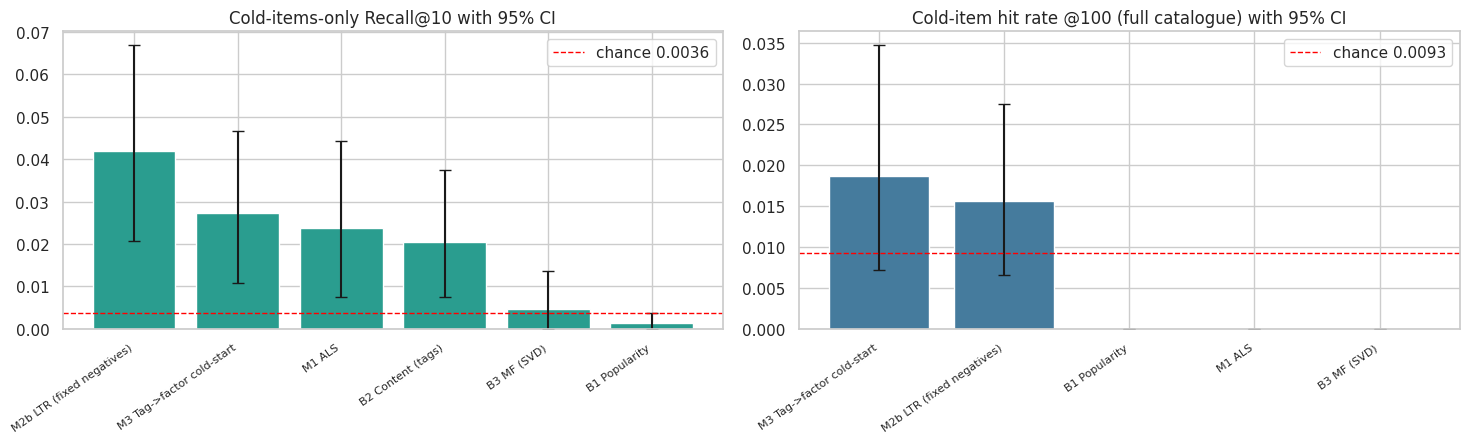

In [44]:
# --- Cluster bootstrap for the item-level cold hit rate at depth ------------
# The depth numbers are per-ITEM rates, but items from the same user are not
# independent, so the bootstrap resamples USERS and recomputes the pooled rate.
DEPTH_FOR_CI = 100
depth_detail = {}
for name in SIG_METHODS:
    rank = _rank_by_name[name]
    hits, tots = [], []
    for u in tqdm(clean_users, desc=f"depth detail: {name}", leave=False):
        rel = clean_truth[u]
        cold_rel = rel[CTX_FULL.cold_mask[rel]]
        if not len(cold_rel):
            hits.append(0); tots.append(0)
            continue
        top = rank(u, clean_seen[u])[:DEPTH_FOR_CI]
        hits.append(int(np.isin(cold_rel, top).sum()))
        tots.append(len(cold_rel))
    depth_detail[name] = (np.array(hits, float), np.array(tots, float))

DEPTH_CHANCE = DEPTH_FOR_CI / n_games
rs2 = np.random.RandomState(RANDOM_STATE)
_idx = rs2.randint(0, len(clean_users), size=(10_000, len(clean_users)))
rows = []
for name, (h, t) in depth_detail.items():
    num, den = h[_idx].sum(axis=1), t[_idx].sum(axis=1)
    boots = np.divide(num, den, out=np.zeros_like(num), where=den > 0)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rate = h.sum() / t.sum() if t.sum() else np.nan
    rows.append({
        "model": name, f"cold_item_hitrate@{DEPTH_FOR_CI}": rate,
        "ci_low": float(lo), "ci_high": float(hi),
        "vs_chance": rate / DEPTH_CHANCE if DEPTH_CHANCE else np.nan,
        "above_chance": bool(lo > DEPTH_CHANCE),
    })
depth_ci = pd.DataFrame(rows).sort_values(f"cold_item_hitrate@{DEPTH_FOR_CI}", ascending=False)
print(f"=== COLD-ITEM HIT RATE @{DEPTH_FOR_CI}, cluster bootstrap over users ===")
print(f"chance = {DEPTH_CHANCE:.5f} ({DEPTH_FOR_CI} / {n_games:,} candidates)")
display(depth_ci.reset_index(drop=True))
depth_ci.to_csv(OUT_DIR / "cold_depth_ci.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
d = cold_abs.sort_values(f"cold_recall@{K}", ascending=False)
axes[0].bar(d["model"], d[f"cold_recall@{K}"], color="#2a9d8f",
            yerr=[d[f"cold_recall@{K}"] - d["ci_low"], d["ci_high"] - d[f"cold_recall@{K}"]],
            capsize=4)
axes[0].axhline(COLD_CHANCE, color="red", ls="--", lw=1, label=f"chance {COLD_CHANCE:.4f}")
axes[0].set_title(f"Cold-items-only Recall@{K} with 95% CI")
axes[0].set_xticklabels(d["model"], rotation=35, ha="right", fontsize=8)
axes[0].legend()

d2 = depth_ci
axes[1].bar(d2["model"], d2[f"cold_item_hitrate@{DEPTH_FOR_CI}"], color="#457b9d",
            yerr=[d2[f"cold_item_hitrate@{DEPTH_FOR_CI}"] - d2["ci_low"],
                  d2["ci_high"] - d2[f"cold_item_hitrate@{DEPTH_FOR_CI}"]], capsize=4)
axes[1].axhline(DEPTH_CHANCE, color="red", ls="--", lw=1, label=f"chance {DEPTH_CHANCE:.4f}")
axes[1].set_title(f"Cold-item hit rate @{DEPTH_FOR_CI} (full catalogue) with 95% CI")
axes[1].set_xticklabels(d2["model"], rotation=35, ha="right", fontsize=8)
axes[1].legend()
plt.tight_layout()
plt.show()


In [45]:
# --- What the evidence supports ---------------------------------------------
def _supported(row, direction="higher"):
    """A claim needs BOTH a Holm-significant test and a CI on the right side of zero."""
    ok = bool(row["p_holm"] < 0.05) and bool(row["ci_excludes_zero"])
    return ok and (row["diff"] > 0 if direction == "higher" else row["diff"] < 0)


def _pick(table, metric, a, b):
    return table[(table["metric"] == metric) & (table["A"] == a) & (table["B"] == b)].iloc[0]


print("=" * 78)
print("WHAT THIS PROJECT CAN CLAIM, AND WHAT IT CANNOT")
print("=" * 78)

# 1. personalization vs popularity
_acc = _pick(sig, f"recall@{K}", "M1 ALS", "B1 Popularity")
claim1 = _supported(_acc)
print("\n1. PERSONALIZATION beats popularity")
print(f"   Recall@{K}: popularity {_acc['mean_B']:.5f} -> ALS {_acc['mean_A']:.5f} "
      f"({_acc['diff']:+.5f}, 95% CI [{_acc['ci_low']:+.5f}, {_acc['ci_high']:+.5f}], "
      f"Holm p={_acc['p_holm']:.3g})")
print("   SUPPORTED." if claim1 else
      "   NOT SUPPORTED in this direction -- do not claim it.")

# 2. trained model vs strongest baseline
_nd = _pick(sig, f"ndcg@{K}", "M1 ALS", "B3 MF (SVD)")
_r10 = _pick(sig, f"recall@{K}", "M1 ALS", "B3 MF (SVD)")
claim2_ndcg = _supported(_nd)
claim2_recall = _supported(_r10)
print("\n2. The trained model beats the strongest baseline (SVD)")
print(f"   NDCG@{K}:   {_nd['mean_B']:.5f} -> {_nd['mean_A']:.5f} ({_nd['diff']:+.5f}, "
      f"CI [{_nd['ci_low']:+.5f}, {_nd['ci_high']:+.5f}], Holm p={_nd['p_holm']:.3g}) "
      f"-> {'SUPPORTED' if claim2_ndcg else 'not supported'}")
print(f"   Recall@{K}: {_r10['mean_B']:.5f} -> {_r10['mean_A']:.5f} ({_r10['diff']:+.5f}, "
      f"CI [{_r10['ci_low']:+.5f}, {_r10['ci_high']:+.5f}], Holm p={_r10['p_holm']:.3g}) "
      f"-> {'SUPPORTED' if claim2_recall else 'directional only'}")
if claim2_ndcg and not claim2_recall:
    print("   Read: it ranks the right items HIGHER, without retrieving significantly more")
    print("   of them into the top 10. Say exactly that rather than 'beats the baseline'.")

# 3. cold items in the main list
print("\n3. Cold games in the MAIN top-10 list")
_above_depth = depth_ci[depth_ci["above_chance"]]
print(f"   Cold-item hit rate @{DEPTH_FOR_CI} of {n_games:,} candidates, chance = {DEPTH_CHANCE:.5f}")
for _, r in depth_ci.iterrows():
    print(f"     {r['model']:<32} {r[f'cold_item_hitrate@{DEPTH_FOR_CI}']:.5f} "
          f"CI [{r['ci_low']:.5f}, {r['ci_high']:.5f}] "
          f"{'ABOVE chance' if r['above_chance'] else 'not above chance'}")
claim3 = len(_above_depth) > 0
if claim3:
    b = _above_depth.iloc[0]
    print(f"   {b['model']} clears chance at {b['vs_chance']:.1f}x -- a small but real effect.")
else:
    print("   No method clears chance. Clean negative result: cold games cannot be forced")
    print("   into the main list, and reserving slots does not fix it either.")

# 4. cold items on a dedicated surface
print("\n4. Cold games on a DEDICATED surface (cold-only candidates)")
_ca = cold_abs.iloc[0]
_best_cold_model = _ca["model"]
_vs_pop = cold_sig[(cold_sig["metric"] == f"cold_recall@{K}")
                   & (cold_sig["A"] == "M3 Tag->factor cold-start")
                   & (cold_sig["B"] == "B1 Popularity")].iloc[0]
_m3_above = bool(
    cold_abs.loc[cold_abs["model"] == "M3 Tag->factor cold-start", "above_chance"].iloc[0]
)
_m3_beats_pop = bool(_vs_pop["p_holm"] < 0.05 and _vs_pop["ci_excludes_zero"]
                     and _vs_pop["diff"] > 0)
print(f"   {len(cold_eval_users):,} users qualify, {int(_n_rel.sum()):,} relevant cold items, "
      f"chance Recall@{K} = {COLD_CHANCE:.5f}")
print(f"   Best method: {_best_cold_model} at {_ca[f'cold_recall@{K}']:.5f} "
      f"({_ca['vs_chance']:.1f}x chance, CI [{_ca['ci_low']:.5f}, {_ca['ci_high']:.5f}]), "
      f"{_ca['users_with_a_hit']}/{len(cold_eval_users)} users got a hit")
print(f"   M3 above chance: {'yes' if _m3_above else 'no'} | "
      f"M3 beats popularity: {'yes' if _m3_beats_pop else 'no'} "
      f"({_vs_pop['diff']:+.5f}, CI [{_vs_pop['ci_low']:+.5f}, {_vs_pop['ci_high']:+.5f}], "
      f"Holm p={_vs_pop['p_holm']:.3g})")
claim4 = _m3_above and _m3_beats_pop
if claim4:
    print("   SUPPORTED: cold inventory is rankable once it is not competing with warm games.")
elif _m3_above:
    print("   PARTIAL: above chance, but not significantly better than popularity. Report the")
    print("   interval and the sample size, and call it preliminary.")
else:
    print("   NOT SUPPORTED: report as a negative result and say what would be needed --")
    print("   more cold-item ground truth, or a richer content signal than tags.")

print("\n" + "=" * 78)
print("PRODUCT SHAPE THAT FOLLOWS FROM THE EVIDENCE")
print("=" * 78)
if claim1:
    print("Main list      : ALS -- significantly better than popularity.")
else:
    print("Main list      : popularity. No model beat it significantly, so shipping")
    print("                 anything more complex is not justified by these numbers.")
if claim4:
    print(f"Discovery      : dedicated cold-item surface ranked by {_best_cold_model},")
    print("                 where cold games compete only with each other.")
elif _m3_above:
    print(f"Discovery      : a cold-item surface using {_best_cold_model} is defensible as")
    print("                 an exploratory feature, but the evidence is preliminary.")
else:
    print("Discovery      : not justified yet. Do not ship a cold-start surface on this")
    print("                 evidence; state it as an open problem instead.")
print("=" * 78)

pd.DataFrame([
    {"claim": "personalization beats popularity", "supported": claim1},
    {"claim": "trained model beats strongest baseline (NDCG@10)", "supported": claim2_ndcg},
    {"claim": "trained model beats strongest baseline (Recall@10)", "supported": claim2_recall},
    {"claim": f"cold items reachable in main list (depth {DEPTH_FOR_CI})", "supported": claim3},
    {"claim": "cold items rankable on a dedicated surface", "supported": claim4},
]).to_csv(OUT_DIR / "claims_supported.csv", index=False)
print("Saved", OUT_DIR / "claims_supported.csv")


WHAT THIS PROJECT CAN CLAIM, AND WHAT IT CANNOT

1. PERSONALIZATION beats popularity
   Recall@10: popularity 0.02462 -> ALS 0.03997 (+0.01534, 95% CI [+0.00700, +0.02442], Holm p=2e-05)
   SUPPORTED.

2. The trained model beats the strongest baseline (SVD)
   NDCG@10:   0.09647 -> 0.12184 (+0.02537, CI [+0.01380, +0.03765], Holm p=0.000383) -> SUPPORTED
   Recall@10: 0.02811 -> 0.03997 (+0.01186, CI [+0.00451, +0.02037], Holm p=0.00607) -> SUPPORTED

3. Cold games in the MAIN top-10 list
   Cold-item hit rate @100 of 10,738 candidates, chance = 0.00931
     M3 Tag->factor cold-start        0.01872 CI [0.00716, 0.03466] not above chance
     M2b LTR (fixed negatives)        0.01560 CI [0.00654, 0.02754] not above chance
     B1 Popularity                    0.00000 CI [0.00000, 0.00000] not above chance
     M1 ALS                           0.00000 CI [0.00000, 0.00000] not above chance
     B3 MF (SVD)                      0.00000 CI [0.00000, 0.00000] not above chance
   No method cl

# Closing gaps the problem statement opens (Blocks A-C)

The problem statement promised multi-signal confidence, use of explicit negatives,
new-release handling, and cold-user onboarding. The next blocks test those promises
one at a time, still on the **same clean catalogue protocol**.

- **Block A**  -  confidence weighting; dislike anti-profiles; LTR with explicit negatives
- **Block B**  -  release age / new-release shelf
- **Block C**  -  cold-start *users* via ALS fold-in as seed likes grow from 0 -> 10


In [46]:
# --- Block A, step 1: the negative side of the data --------------------------
# Everything here is built from label == 0 rows, which no model above has touched.
@dataclass
class NegCtx:
    """Explicit-negative structures over the same fixed index space as Ctx."""
    name: str
    dis_prof: np.ndarray       # (n_users, TAG_DIM) mean tag vector of disliked games
    dis_norm: np.ndarray
    dis_ok: np.ndarray         # user has a usable anti-profile
    dis_items: dict            # user_id -> item indices explicitly disliked
    item_dis_rate: np.ndarray  # (n_games,) share of reviews that are negative
    n_neg: int


def build_neg(df, name):
    keep = df["user_id"].isin(user_id_map) & df["app_id"].isin(game_id_map)
    sub = df.loc[keep, ["user_id", "app_id", "label"]]
    ui = sub["user_id"].map(user_id_map).to_numpy(dtype=np.int64)
    gi = sub["app_id"].map(game_id_map).to_numpy(dtype=np.int64)
    neg = ~sub["label"].to_numpy().astype(bool)
    n_neg = int(neg.sum())

    reviews = np.bincount(gi, minlength=n_games).astype(np.float32)
    neg_cnt = np.bincount(gi[neg], minlength=n_games).astype(np.float32)
    item_dis_rate = np.divide(neg_cnt, reviews, out=np.zeros(n_games, np.float32),
                              where=reviews > 0)

    Bneg = csr_matrix((np.ones(n_neg, np.float32), (ui[neg], gi[neg])),
                      shape=(n_users, n_games))
    tagged = np.asarray(Bneg[:, HAS_TAGS].sum(axis=1)).ravel()
    dis_prof = np.asarray(Bneg @ TAGM, dtype=np.float32)
    nz = tagged > 0
    dis_prof[nz] /= tagged[nz, None].astype(np.float32)
    dis_prof[~nz] = 0.0
    dis_norm = np.linalg.norm(dis_prof, axis=1) + 1e-8
    dis_ok = nz & (dis_norm > 1e-6)

    un, gn = ui[neg], gi[neg]
    order = np.argsort(un, kind="stable")
    un_s, gn_s = un[order], gn[order]
    bounds = np.searchsorted(un_s, np.arange(n_users + 1))
    dis_items = {}
    for uidx in range(n_users):
        a, b = bounds[uidx], bounds[uidx + 1]
        if b > a:
            dis_items[inv_user_map[uidx]] = np.unique(gn_s[a:b])

    print(f"NegCtx '{name}': {n_neg:,} explicit negatives "
          f"({100 * n_neg / max(len(sub), 1):.1f}% of rows), "
          f"{len(dis_items):,} users with >=1 dislike, "
          f"{int(dis_ok.sum()):,} with a usable anti-profile")
    return NegCtx(name, dis_prof, dis_norm, dis_ok, dis_items, item_dis_rate, n_neg)


NEG_FULL = build_neg(train, "full-train")
NEG_A = build_neg(tr_a, "inner-features")

# Dislikes from the LABEL slice, used as hard negatives for the ranker. These are the
# mirror image of pos_b: same time window, same user, opposite sign.
neg_b = {}
_nb_rows = tr_b[tr_b["label"] == 0]
_nu = _nb_rows["user_id"].map(user_id_map)
_ng = _nb_rows["app_id"].map(game_id_map)
_okn = _nu.notna() & _ng.notna()
for u, gidx in zip(_nb_rows.loc[_okn, "user_id"].astype(np.int64), _ng[_okn].astype(np.int64)):
    neg_b.setdefault(int(u), set()).add(int(gidx))
neg_b = {u: np.array(sorted(v), dtype=np.int64) for u, v in neg_b.items() if v}
print(f"Users with an explicit dislike in the label slice: {len(neg_b):,}")
print(f"Overlap with users that have a positive label     : "
      f"{len(set(neg_b) & set(pos_b)):,}")


def dislike_affinity(u, nctx, ctx, w_tag=0.5):
    """How much does each game resemble what this user explicitly rejected?

    Two views, averaged: tag similarity to the anti-profile (works for cold games too)
    and similarity in the learned item-factor space (catches taste the tags miss).
    Both are returned in percentile space so the caller can subtract them from a score
    of a completely different scale.
    """
    ui = user_id_map.get(u)
    parts, weights = [], []
    if ui is not None and nctx.dis_ok[ui]:
        parts.append((TAGM @ nctx.dis_prof[ui]) / (nctx.dis_norm[ui] * TAGN))
        weights.append(w_tag)
    d = nctx.dis_items.get(u)
    if d is not None and len(d):
        v = ctx.als_if[d].mean(axis=0)
        nv = np.linalg.norm(v)
        if nv > 1e-8:
            parts.append((ctx.als_if @ v) / nv)
            weights.append(1.0 - w_tag)
    if not parts:
        return np.zeros(n_games, dtype=np.float32)
    w = np.array(weights, dtype=np.float64)
    w /= w.sum()
    return sum(wi * _rank_pct(p) for wi, p in zip(w, parts)).astype(np.float32)


print("Dislike structures ready.")

NegCtx 'full-train': 593,014 explicit negatives (18.5% of rows), 49,851 users with >=1 dislike, 47,267 with a usable anti-profile
NegCtx 'inner-features': 481,669 explicit negatives (18.8% of rows), 46,139 users with >=1 dislike, 43,209 with a usable anti-profile
Users with an explicit dislike in the label slice: 30,324
Overlap with users that have a positive label     : 28,859
Dislike structures ready.


In [47]:
# Audience note  -  Block A ablation:
# Same ALS setup; ONLY the confidence formula changes (binary vs hours vs helpfulness).
# If hours x helpfulness does not beat binary, we report that honestly.

# --- Block A, step 2: does the multi-signal weighting actually help? --------
# Only the confidence weights change. The index space, the tag matrix, the user set and
# the ALS hyper-parameters are identical across variants, so a difference in recall is
# attributable to the weighting scheme and nothing else.
# h = log1p(hours), p = log1p(helpful), so helpful = expm1(p) and the current scheme
# log1p(hours) * log1p(1 + helpful) is h * log1p(1 + expm1(p)).
CONF_MODES = {
    "binary (label only)":           lambda h, p: np.ones_like(h),
    "hours only":                    lambda h, p: 1.0 + h,
    "helpfulness only":              lambda h, p: 1.0 + p,
    "hours x helpfulness (current)": lambda h, p: h * np.log1p(1.0 + np.expm1(p)),
    "hours + 0.3 helpfulness":       lambda h, p: 1.0 + h + 0.3 * p,
}


def _conf_vectors(df):
    """Return the aligned (user_idx, item_idx, log-hours, log-helpful) for positives."""
    keep = df["user_id"].isin(user_id_map) & df["app_id"].isin(game_id_map)
    sub = df.loc[keep, ["user_id", "app_id", "hours", "helpful", "label", "confidence"]]
    lab = sub["label"].to_numpy().astype(bool)
    ui = sub["user_id"].map(user_id_map).to_numpy(dtype=np.int64)[lab]
    gi = sub["app_id"].map(game_id_map).to_numpy(dtype=np.int64)[lab]
    h = np.log1p(np.clip(sub.loc[lab, "hours"].fillna(0).to_numpy(dtype=np.float64), 0, None))
    p = np.log1p(np.clip(sub.loc[lab, "helpful"].fillna(0).to_numpy(dtype=np.float64), 0, None))
    native = np.maximum(sub.loc[lab, "confidence"].to_numpy(dtype=np.float64), 0.1)
    return ui, gi, h, p, native


_cu, _cg, _ch, _cp, _cnative = _conf_vectors(train)
print(f"Positives feeding every ALS variant: {len(_cu):,}")

als_variants = {}
for mode, fn in CONF_MODES.items():
    w = np.maximum(fn(_ch, _cp), 0.1)
    if mode == "hours x helpfulness (current)":
        drift = float(np.abs(w - _cnative).max())
        print(f"  reproduces the pipeline's own confidence column, max drift {drift:.2e}")
        assert drift < 1e-6, "confidence formula drifted from the one used above"
    Rv = csr_matrix((w, (_cu, _cg)), shape=(n_users, n_games))
    print(f"\n{mode}: weight mean {w.mean():.3f}, sd {w.std():.3f}, "
          f"max {w.max():.1f}")
    uf, itf = fit_als_matrix(Rv, tag=f" [{mode}]")
    als_variants[mode] = (uf, itf)


def make_als_variant_scorer(mode):
    uf, itf = als_variants[mode]

    def scorer(u, ctx=None, _uf=uf, _if=itf):
        ui = user_id_map.get(u)
        return _if @ _uf[ui] if ui is not None else CTX_FULL.pop
    return scorer


CONF_METHODS = [(f"ALS conf={m}", make_ranker(make_als_variant_scorer(m))) for m in CONF_MODES]
print(f"\nEvaluating {len(CONF_METHODS)} confidence variants on the full-catalogue protocol...")
conf_ov, _, conf_ics, conf_cov = eval_clean(CONF_METHODS)
conf_tbl = (conf_ov.merge(conf_cov, on="model")
            .sort_values(f"recall@{K}", ascending=False).reset_index(drop=True))
print("\n=== CONFIDENCE-WEIGHTING ABLATION (only the weights differ) ===")
display(conf_tbl)
conf_tbl.to_csv(OUT_DIR / "confidence_ablation.csv", index=False)

_bin = float(conf_tbl.loc[conf_tbl["model"].str.contains("binary"), f"recall@{K}"].iloc[0])
_cur = float(conf_tbl.loc[conf_tbl["model"].str.contains("current"), f"recall@{K}"].iloc[0])
_hrs = float(conf_tbl.loc[conf_tbl["model"].str.contains("hours only"), f"recall@{K}"].iloc[0])
print("\n--- What this says about the multi-signal claim ---")
print(f"binary label only      : {_bin:.5f}")
print(f"hours only             : {_hrs:.5f}")
print(f"hours x helpfulness    : {_cur:.5f}  (the weighting used everywhere above)")
if _cur > _bin * 1.02:
    print("\nWeighting by hours and helpfulness beats a plain binary matrix, so the")
    print("multi-signal claim in the problem statement is supported. Quote this table.")
elif _cur < _bin * 0.98:
    print("\nThe binary matrix BEATS the hours x helpfulness weighting. That is a real")
    print("finding, not a bug: it is direct evidence for the problem statement's own")
    print("warning that playtime misreads grinding and unfinished purchases. Report it")
    print("and switch the shipped model to the better weighting.")
else:
    print("\nThe weighting makes no material difference. Report the multi-signal design")
    print("as neutral on accuracy rather than claiming a gain it does not produce.")

Positives feeding every ALS variant: 2,607,543

binary (label only): weight mean 1.000, sd 0.000, max 1.0


  0%|          | 0/15 [00:00<?, ?it/s]

  ALS [binary (label only)]: implicit (55898, 64) (10738, 64)

hours only: weight mean 3.724, sd 1.442, max 7.9


  0%|          | 0/15 [00:00<?, ?it/s]

  ALS [hours only]: implicit (55898, 64) (10738, 64)

helpfulness only: weight mean 1.719, sd 1.129, max 10.8


...

ALS conf=hours x helpfulness (current):   0%|          | 0/572 [00:00<?, ?it/s]

ALS conf=hours + 0.3 helpfulness:   0%|          | 0/572 [00:00<?, ?it/s]


=== CONFIDENCE-WEIGHTING ABLATION (only the weights differ) ===


,model,n_users,recall@10,recall@50,recall@100,ndcg@10,hitrate@10,catalogue_coverage,avg_popularity_percentile
0,ALS conf=hours x helpfulness (current),572,0.039967,0.130543,0.211331,0.121838,0.468531,0.115478,0.962869
1,ALS conf=binary (label only),572,0.037704,0.135266,0.210758,0.124248,0.484266,0.096480,0.971840
2,ALS conf=helpfulness only,572,0.037635,0.133125,0.212685,0.121557,0.466783,0.109983,0.966498
3,ALS conf=hours only,572,0.036263,0.129656,0.207578,0.115839,0.465035,0.120972,0.961281
4,ALS conf=hours + 0.3 helpfulness,572,0.034776,0.132474,0.205110,0.116261,0.456294,0.122462,0.960678



--- What this says about the multi-signal claim ---
binary label only      : 0.03770
hours only             : 0.03626
hours x helpfulness    : 0.03997  (the weighting used everywhere above)

Weighting by hours and helpfulness beats a plain binary matrix, so the
multi-signal claim in the problem statement is supported. Quote this table.


In [48]:
# --- Block A, step 3: M4, an ALS score penalised by explicit dislikes -------
# The penalty weight is chosen on the INNER split (features from tr_a, labels from tr_b)
# and then applied unchanged on test, so the tuning cannot inflate the reported number.
LAMBDA_GRID = (0.0, 0.05, 0.1, 0.2, 0.4, 0.8)
VAL_USERS_MAX = 800

_val_pool = [u for u in pos_b if u in user_id_map]
_vrng = np.random.RandomState(RANDOM_STATE)
val_users = [int(u) for u in _vrng.choice(
    _val_pool, size=min(VAL_USERS_MAX, len(_val_pool)), replace=False)]
print(f"Tuning the dislike penalty on {len(val_users):,} inner-split users")


def _score_dislike_aware(u, lam, nctx, ctx):
    base = _rank_pct(np.asarray(s_als(u, ctx), dtype=np.float64))
    if lam == 0.0:
        return base
    return base - lam * dislike_affinity(u, nctx, ctx)


def _val_recall(lam):
    hits = []
    for u in val_users:
        rel = pos_b[u]
        s = _score_dislike_aware(u, lam, NEG_A, CTX_A).astype(np.float64)
        blocked = CTX_A.seen.get(u, np.array([], dtype=np.int64))
        if len(blocked):
            s[blocked] = -np.inf
        top = np.argpartition(-s, K - 1)[:K]
        hits.append(np.isin(top, rel).sum() / len(rel))
    return float(np.mean(hits))


lam_rows = [{"lambda": lam, f"inner_recall@{K}": _val_recall(lam)}
            for lam in tqdm(LAMBDA_GRID, desc="lambda sweep", leave=False)]
lam_tbl = pd.DataFrame(lam_rows)
display(lam_tbl)
BEST_LAMBDA = float(lam_tbl.loc[lam_tbl[f"inner_recall@{K}"].idxmax(), "lambda"])
_gain = (lam_tbl[f"inner_recall@{K}"].max()
         - float(lam_tbl.loc[lam_tbl["lambda"] == 0.0, f"inner_recall@{K}"].iloc[0]))
print(f"Best lambda on the inner split: {BEST_LAMBDA} "
      f"(inner gain over no penalty {_gain:+.5f})")
if BEST_LAMBDA == 0.0:
    print("The sweep prefers NO penalty. M4 will therefore be identical to M1 on test;")
    print("report that the anti-profile penalty did not help and keep the honest number.")


def s_als_dislike(u, ctx=None):
    """M4: ALS in percentile space, minus a penalty for resembling explicit dislikes."""
    return _score_dislike_aware(u, BEST_LAMBDA, NEG_FULL, ctx or CTX_FULL)


print("M4 ready with lambda =", BEST_LAMBDA)

Tuning the dislike penalty on 800 inner-split users


lambda sweep:   0%|          | 0/6 [00:00<?, ?it/s]

,lambda,inner_recall@10
0,0.00,0.036566
1,0.05,0.029109
2,0.10,0.023200
3,0.20,0.017905
4,0.40,0.019077
5,0.80,0.017668


Best lambda on the inner split: 0.0 (inner gain over no penalty +0.00000)
The sweep prefers NO penalty. M4 will therefore be identical to M1 on test;
report that the anti-profile penalty did not help and keep the honest number.
M4 ready with lambda = 0.0


In [49]:
# --- Block A, step 4: M2c, a ranker that can see what the user rejected -----
# Two additions over M2b, both aimed squarely at the "explicit negatives are underused"
# gap: user-specific dislike features, and explicitly disliked games used as hard
# negatives instead of only randomly sampled unseen ones.
FEATURE_NAMES_V3 = FEATURE_NAMES_V2 + [
    "dislike_tag_cos", "dislike_factor_sim", "item_dislike_rate",
]


def features_full_v3(u, ctx, nctx):
    F = np.zeros((n_games, len(FEATURE_NAMES_V3)), dtype=np.float32)
    F[:, : len(FEATURE_NAMES_V2)] = features_full(u, ctx)
    ui = user_id_map.get(u)
    if ui is not None and nctx.dis_ok[ui]:
        F[:, len(FEATURE_NAMES_V2)] = (TAGM @ nctx.dis_prof[ui]) / (nctx.dis_norm[ui] * TAGN)
    d = nctx.dis_items.get(u)
    if d is not None and len(d):
        v = ctx.als_if[d].mean(axis=0)
        nv = np.linalg.norm(v)
        if nv > 1e-8:
            F[:, len(FEATURE_NAMES_V2) + 1] = (ctx.als_if @ v) / nv
    F[:, len(FEATURE_NAMES_V2) + 2] = nctx.item_dis_rate
    return F


HARD_NEG_CAP = 40
GROUP_SEED = RANDOM_STATE + 7   # its own stream, so M2d can reproduce these exact groups

rngc = np.random.RandomState(GROUP_SEED)
Xc, yc, gc, n_hard = [], [], [], 0
for u in tqdm(ltr_users_v2, desc="Sampling groups with explicit negatives", leave=False):
    pos = pos_b[u]
    if len(pos) > 20:
        pos = rngc.choice(pos, size=20, replace=False)
    blocked = np.union1d(CTX_A.seen.get(u, np.array([], dtype=np.int64)), pos_b[u])

    hard = neg_b.get(u, np.array([], dtype=np.int64))
    hard = np.setdiff1d(hard, blocked)
    if len(hard) > HARD_NEG_CAP:
        hard = rngc.choice(hard, size=HARD_NEG_CAP, replace=False)
    n_hard += len(hard)

    half = NEG_PER_USER // 2
    cand = np.concatenate([
        rngc.randint(0, n_games, size=half * 3),
        rngc.choice(n_games, size=half * 3, p=_pw),
    ])
    cand = np.setdiff1d(np.unique(cand), np.union1d(blocked, hard))
    if len(cand) > NEG_PER_USER:
        cand = rngc.choice(cand, size=NEG_PER_USER, replace=False)
    if len(pos) == 0 or (len(cand) == 0 and len(hard) == 0):
        continue

    items = np.concatenate([pos, hard, cand]).astype(np.int64)
    Xc.append(features_full_v3(u, CTX_A, NEG_A)[items])
    yc.append(np.concatenate([
        np.ones(len(pos), np.int8),
        np.zeros(len(hard) + len(cand), np.int8),
    ]))
    gc.append(len(items))

X_v3 = np.vstack(Xc)
y_v3 = np.concatenate(yc)
print(f"Training matrix {X_v3.shape}, positives {int(y_v3.sum()):,}, "
      f"explicit hard negatives {n_hard:,}, groups {len(gc):,}")
if n_hard == 0:
    print("WARNING: no explicit negatives survived sampling. M2c collapses to M2b + "
          "three extra features; say so rather than claiming a negative-feedback model.")

ltr_v3, LTR_V3_MODE = _fit_ranker(X_v3, y_v3, gc)
print("M2c trained with", LTR_BACKEND)

if hasattr(ltr_v3, "booster_"):
    _g3 = ltr_v3.booster_.feature_importance(importance_type="gain")
    _imp3 = pd.DataFrame({"gain": _g3, "gain_share": _g3 / max(_g3.sum(), 1e-9)},
                         index=FEATURE_NAMES_V3).sort_values("gain", ascending=False)
    display(_imp3)
    _dis_share = float(_imp3.loc[["dislike_tag_cos", "dislike_factor_sim",
                                  "item_dislike_rate"], "gain_share"].sum())
    print(f"Share of total gain taken by the three dislike features: {_dis_share:.1%}")
    if _dis_share < 0.01:
        print("Near zero: the model found no use for explicit negatives. That is a")
        print("reportable result about the signal, not a bug in the implementation.")
    else:
        print("The model is using them. Whether that converts into better ranking is")
        print("settled by the paired test below, not by feature importance -- gain only")
        print("says the splits were taken, not that they helped on held-out users.")


def s_ltr_v3(u, ctx=None):
    """M2c: M2b plus user-specific dislike evidence."""
    F = features_full_v3(u, ctx or CTX_FULL, NEG_FULL)
    if LTR_V3_MODE == "proba":
        return ltr_v3.predict_proba(F)[:, 1]
    return ltr_v3.predict(F)


print("M2c ready.")

Sampling groups with explicit negatives:   0%|          | 0/3000 [00:00<?, ?it/s]

Training matrix (632072, 16), positives 25,654, explicit hard negatives 6,418, groups 3,000
M2c trained with lightgbm-lambdarank


,gain,gain_share
als_score,84351.778850,0.341103
tag_cosine,62506.707851,0.252766
item_avg_loghelp,14651.751711,0.059249
log_item_reviews,11907.852743,0.048153
item_dislike_rate,11403.628200,0.046114
log_user_reviews,10643.974776,0.043042
svd_score,10484.163202,0.042396
item_avg_loghours,7250.575869,0.029320
user_rec_rate,6411.961453,0.025929
user_avg_loghours,5527.664417,0.022353


Share of total gain taken by the three dislike features: 7.9%
The model is using them. Whether that converts into better ranking is
settled by the paired test below, not by feature importance -- gain only
says the splits were taken, not that they helped on held-out users.
M2c ready.


In [50]:
# --- Block A, step 5: do the negative-feedback models beat the ones without? -
NEG_METHODS = [
    ("M1 ALS", make_ranker(s_als)),
    ("M4 ALS + dislike penalty", make_ranker(s_als_dislike)),
    ("M2b LTR (fixed negatives)", make_ranker(s_ltr_v2)),
    ("M2c LTR + explicit negatives", make_ranker(s_ltr_v3)),
]
neg_ov, neg_seg, neg_ics, neg_cov = eval_clean(NEG_METHODS)
neg_tbl = (neg_ov.merge(neg_ics[["model", f"cold_item_hitrate@{K}",
                                 f"warm_item_hitrate@{K}"]], on="model")
           .merge(neg_cov, on="model")
           .sort_values(f"recall@{K}", ascending=False).reset_index(drop=True))
print("=== WITH vs WITHOUT EXPLICIT NEGATIVE FEEDBACK ===")
display(neg_tbl)
neg_tbl.to_csv(OUT_DIR / "negative_feedback_results.csv", index=False)

# Paired per-user tests on the two comparisons that matter
_neg_rank = dict(NEG_METHODS)
neg_per_user = {}
for name in ("M1 ALS", "M4 ALS + dislike penalty",
             "M2b LTR (fixed negatives)", "M2c LTR + explicit negatives"):
    rank = _neg_rank[name]
    rec, ndc = [], []
    for u in tqdm(clean_users, desc=f"per-user: {name}", leave=False):
        rel = clean_truth[u]
        hit = np.isin(rank(u, clean_seen[u]), rel)
        rec.append(hit[:K].sum() / len(rel))
        idcg = float((1.0 / _log2[: min(len(rel), K)]).sum())
        ndc.append(float((hit[:K] / _log2[:K]).sum()) / idcg if idcg else 0.0)
    neg_per_user[name] = {"recall": np.array(rec), "ndcg": np.array(ndc)}

rows = []
for metric in ("recall", "ndcg"):
    for a, b in (("M4 ALS + dislike penalty", "M1 ALS"),
                 ("M2c LTR + explicit negatives", "M2b LTR (fixed negatives)")):
        diff, lo, hi, pb, pw = paired_test(neg_per_user[a][metric], neg_per_user[b][metric])
        rows.append({"metric": f"{metric}@{K}", "A": a, "B": b,
                     "mean_A": float(neg_per_user[a][metric].mean()),
                     "mean_B": float(neg_per_user[b][metric].mean()),
                     "diff": diff, "ci_low": lo, "ci_high": hi, "p_wilcoxon": pw})
neg_sig = pd.DataFrame(rows)
neg_sig["ci_excludes_zero"] = (neg_sig["ci_low"] > 0) | (neg_sig["ci_high"] < 0)
display(neg_sig.round(6))
neg_sig.to_csv(OUT_DIR / "negative_feedback_significance.csv", index=False)

print("\n--- Verdict on explicit negative feedback ---")
_helped = False
for _, r in neg_sig.iterrows():
    better = r["diff"] > 0 and r["ci_excludes_zero"]
    worse = r["diff"] < 0 and r["ci_excludes_zero"]
    tag = "HELPS" if better else ("HURTS" if worse else
           "identical model (penalty tuned to 0)" if abs(r["diff"]) < 1e-12 else
           "no reliable change")
    print(f"{r['metric']}: {r['A']} vs {r['B']}: {r['diff']:+.5f} "
          f"[{r['ci_low']:+.5f}, {r['ci_high']:+.5f}] -> {tag}")
    _helped = _helped or better
if _helped:
    print("\nExplicit negatives improve ranking. This is the contribution the problem")
    print("statement promised, and it is now measured rather than asserted.")
else:
    print("\nExplicit negatives did NOT improve ranking on this dataset. That is still a")
    print("publishable answer to the gap the problem statement raises: the signal is")
    print("present and was used correctly, but at this density it carries no extra")
    print("ranking information beyond what the positive matrix already encodes.")

M1 ALS:   0%|          | 0/572 [00:00<?, ?it/s]

M4 ALS + dislike penalty:   0%|          | 0/572 [00:00<?, ?it/s]

M2b LTR (fixed negatives):   0%|          | 0/572 [00:00<?, ?it/s]

M2c LTR + explicit negatives:   0%|          | 0/572 [00:00<?, ?it/s]

=== WITH vs WITHOUT EXPLICIT NEGATIVE FEEDBACK ===


...

per-user: M4 ALS + dislike penalty:   0%|          | 0/572 [00:00<?, ?it/s]

per-user: M2b LTR (fixed negatives):   0%|          | 0/572 [00:00<?, ?it/s]

per-user: M2c LTR + explicit negatives:   0%|          | 0/572 [00:00<?, ?it/s]

,metric,A,B,mean_A,mean_B,diff,ci_low,ci_high,p_wilcoxon,ci_excludes_zero
0,recall@10,M4 ALS + dislike penalty,M1 ALS,0.039958,0.039967,-0.000009,-0.000169,0.000142,0.654721,False
1,recall@10,M2c LTR + explicit negatives,M2b LTR (fixed negatives),0.032261,0.034695,-0.002434,-0.010117,0.005041,0.965294,False
2,ndcg@10,M4 ALS + dislike penalty,M1 ALS,0.121646,0.121838,-0.000192,-0.001154,0.000577,0.654721,False
3,ndcg@10,M2c LTR + explicit negatives,M2b LTR (fixed negatives),0.091236,0.092022,-0.000786,-0.009227,0.007765,0.727821,False



--- Verdict on explicit negative feedback ---
recall@10: M4 ALS + dislike penalty vs M1 ALS: -0.00001 [-0.00017, +0.00014] -> no reliable change
recall@10: M2c LTR + explicit negatives vs M2b LTR (fixed negatives): -0.00243 [-0.01012, +0.00504] -> no reliable change
ndcg@10: M4 ALS + dislike penalty vs M1 ALS: -0.00019 [-0.00115, +0.00058] -> no reliable change
ndcg@10: M2c LTR + explicit negatives vs M2b LTR (fixed negatives): -0.00079 [-0.00923, +0.00777] -> no reliable change

Explicit negatives did NOT improve ranking on this dataset. That is still a
publishable answer to the gap the problem statement raises: the signal is
present and was used correctly, but at this density it carries no extra
ranking information beyond what the positive matrix already encodes.


# Brand-new releases (Block B)

"New" here means released near the train/test time boundary  -  information a live system
would know at prediction time.

We ask two questions:

1. Does adding release-age features help the main-list ranker?
2. On a **new-release-only shelf**, can personalisation beat a dumb "newest first" sort?

**Caveat for the audience:** a review dataset only contains a game once someone has
played and reviewed it. So this shelf is "recent titles with some history," not true
zero-history launches.


In [51]:
# --- Block B, step 1: release age over the fixed index space ----------------
# Age is measured at the train/test boundary, so it is knowable at prediction time.
_g_rel = games[["app_id", "date_release"]].dropna().copy()
_g_rel["app_id"] = _g_rel["app_id"].astype(np.int64)
_g_rel["gi"] = _g_rel["app_id"].map(game_id_map)
_g_rel = _g_rel.dropna(subset=["gi"])
_g_rel["gi"] = _g_rel["gi"].astype(np.int64)

REL_AGE = np.full(n_games, np.nan, dtype=np.float32)
_age_days = (pd.Timestamp(cutoff) - pd.to_datetime(_g_rel["date_release"])).dt.days
REL_AGE[_g_rel["gi"].to_numpy()] = _age_days.to_numpy(dtype=np.float32)
HAS_AGE = np.isfinite(REL_AGE)
_med_age = float(np.nanmedian(REL_AGE)) if HAS_AGE.any() else 0.0
REL_AGE_F = np.where(HAS_AGE, REL_AGE, _med_age).astype(np.float32)
LOG_AGE = np.log1p(np.clip(REL_AGE_F, 0, None)).astype(np.float32)

print(f"Release dates matched to the index space: {int(HAS_AGE.sum()):,} of {n_games:,}")
if HAS_AGE.any():
    print(f"Age at the {pd.Timestamp(cutoff).date()} boundary (days): median {_med_age:,.0f}, "
          f"min {np.nanmin(REL_AGE):,.0f}, max {np.nanmax(REL_AGE):,.0f}")
    print(f"Released AFTER the boundary (negative age): {int((REL_AGE < 0).sum()):,}")
else:
    print("No release dates could be matched -- Block B cannot run on this catalogue.")

# How much genuinely new inventory is there to be discovered in the test window?
NEW_WINDOW_DAYS = 365
NEW_MASK = HAS_AGE & (REL_AGE <= NEW_WINDOW_DAYS)
_new_rel = _new_users = 0
for u in clean_users:
    r = clean_truth[u]
    k = int(NEW_MASK[r].sum())
    _new_rel += k
    _new_users += int(k > 0)
print(f"\nGames released within {NEW_WINDOW_DAYS} days of the boundary: "
      f"{int(NEW_MASK.sum()):,} ({100 * NEW_MASK.mean():.1f}% of the catalogue)")
print(f"Held-out likes that land on one: {_new_rel:,} across {_new_users:,} users")
print(f"Overlap between 'new' and 'cold' (low interaction count): "
      f"{int((NEW_MASK & CTX_FULL.cold_mask).sum()):,} games")
if _new_users < 30:
    print("\nWARNING: too little new inventory in the test window to measure a new-release")
    print("         surface. Report the constraint -- it is a property of a review-based")
    print("         dataset, where a game only appears once someone has already played it.")

Release dates matched to the index space: 10,738 of 10,738
Age at the 2021-11-02 boundary (days): median 1,502, min -660, max 8,891
Released AFTER the boundary (negative age): 252

Games released within 365 days of the boundary: 1,588 (14.8% of the catalogue)
Held-out likes that land on one: 2,394 across 492 users
Overlap between 'new' and 'cold' (low interaction count): 762 games


In [52]:
# --- Block B, step 2: does release age help the ranker? ---------------------
FEATURE_NAMES_V4 = FEATURE_NAMES_V3 + ["log_release_age", "is_new_release"]


def features_full_v4(u, ctx, nctx):
    F = np.zeros((n_games, len(FEATURE_NAMES_V4)), dtype=np.float32)
    F[:, : len(FEATURE_NAMES_V3)] = features_full_v3(u, ctx, nctx)
    F[:, len(FEATURE_NAMES_V3)] = LOG_AGE
    F[:, len(FEATURE_NAMES_V3) + 1] = NEW_MASK.astype(np.float32)
    return F


# Same users, same sampler, same seed stream as M2c, so the groups are byte-identical and
# the ONLY difference between M2c and M2d is the two recency columns.
rnga = np.random.RandomState(GROUP_SEED)
Xa, ya, ga = [], [], []
for u in tqdm(ltr_users_v2, desc="Groups with recency", leave=False):
    pos = pos_b[u]
    if len(pos) > 20:
        pos = rnga.choice(pos, size=20, replace=False)
    blocked = np.union1d(CTX_A.seen.get(u, np.array([], dtype=np.int64)), pos_b[u])
    hard = np.setdiff1d(neg_b.get(u, np.array([], dtype=np.int64)), blocked)
    if len(hard) > HARD_NEG_CAP:
        hard = rnga.choice(hard, size=HARD_NEG_CAP, replace=False)
    half = NEG_PER_USER // 2
    cand = np.concatenate([
        rnga.randint(0, n_games, size=half * 3),
        rnga.choice(n_games, size=half * 3, p=_pw),
    ])
    cand = np.setdiff1d(np.unique(cand), np.union1d(blocked, hard))
    if len(cand) > NEG_PER_USER:
        cand = rnga.choice(cand, size=NEG_PER_USER, replace=False)
    if len(pos) == 0 or (len(cand) == 0 and len(hard) == 0):
        continue
    items = np.concatenate([pos, hard, cand]).astype(np.int64)
    Xa.append(features_full_v4(u, CTX_A, NEG_A)[items])
    ya.append(np.concatenate([np.ones(len(pos), np.int8),
                              np.zeros(len(hard) + len(cand), np.int8)]))
    ga.append(len(items))

X_v4 = np.vstack(Xa)
y_v4 = np.concatenate(ya)
print(f"Training matrix {X_v4.shape}, positives {int(y_v4.sum()):,}, groups {len(ga):,}")

# The ablation is only clean if the groups really are the same ones M2c saw.
assert ga == gc, "group structure diverged from M2c -- the recency ablation is not paired"
_drift = float(np.abs(X_v4[:, : len(FEATURE_NAMES_V3)] - X_v3).max())
print(f"Shared feature block matches M2c exactly (max drift {_drift:.2e})")
assert _drift < 1e-5, "shared features differ; M2c vs M2d would not be a clean ablation"

ltr_v4, LTR_V4_MODE = _fit_ranker(X_v4, y_v4, ga)
if hasattr(ltr_v4, "booster_"):
    _g4 = ltr_v4.booster_.feature_importance(importance_type="gain")
    _imp4 = pd.DataFrame({"gain": _g4, "gain_share": _g4 / max(_g4.sum(), 1e-9)},
                         index=FEATURE_NAMES_V4).sort_values("gain", ascending=False)
    display(_imp4)
    print(f"Gain share taken by the two recency features: "
          f"{float(_imp4.loc[['log_release_age', 'is_new_release'], 'gain_share'].sum()):.1%}")


def s_ltr_v4(u, ctx=None):
    """M2d: M2c plus release recency."""
    F = features_full_v4(u, ctx or CTX_FULL, NEG_FULL)
    if LTR_V4_MODE == "proba":
        return ltr_v4.predict_proba(F)[:, 1]
    return ltr_v4.predict(F)


print("M2d ready.")

Groups with recency:   0%|          | 0/3000 [00:00<?, ?it/s]

Training matrix (632072, 18), positives 25,654, groups 3,000
Shared feature block matches M2c exactly (max drift 0.00e+00)


,gain,gain_share
als_score,95918.038426,0.365698
tag_cosine,50783.079148,0.193616
log_release_age,43496.979910,0.165837
log_user_reviews,11198.531912,0.042696
svd_score,8460.945652,0.032258
item_avg_loghelp,7320.034549,0.027908
user_rec_rate,6214.950719,0.023695
user_avg_loghours,5590.490513,0.021314
item_avg_loghours,4942.697396,0.018845
log_pop,4670.045281,0.017805


Gain share taken by the two recency features: 16.6%
M2d ready.


In [53]:
# --- Block B, step 3: the new-release surface -------------------------------
# Candidates restricted to games released within NEW_WINDOW_DAYS of the boundary. This is
# the "what's new for me" shelf, and unlike the main list it is a task where a game with
# no history is not structurally disadvantaged.
new_idx = np.where(NEW_MASK)[0]
not_new_idx = np.where(~NEW_MASK)[0]
n_new = len(new_idx)

new_truth = {}
for u in clean_users:
    r = clean_truth[u]
    nn = r[NEW_MASK[r]]
    if len(nn):
        new_truth[u] = nn
new_users_eval = list(new_truth)
MIN_NEW_CANDIDATES = 3 * K       # below this the task is degenerate: everything is a hit
MIN_NEW_USERS = 30
_chance_new = min(K / max(n_new, 1), 1.0)
print(f"New-release surface: {n_new:,} candidates, {len(new_users_eval):,} users with a "
      f"relevant new game")
print(f"Chance Recall@{K}: {_chance_new:.5f}")
_new_ok = n_new >= MIN_NEW_CANDIDATES and len(new_users_eval) >= MIN_NEW_USERS
if not _new_ok:
    print(f"\nNot enough new inventory to rank: the task needs at least "
          f"{MIN_NEW_CANDIDATES} candidates and {MIN_NEW_USERS} users. With fewer "
          f"candidates than the cut-off every method scores near 1.0 and the numbers "
          f"mean nothing.")


def s_recency_content(u, ctx=None):
    """Tag match, tilted toward the newest inventory. Needs no interaction history."""
    c = _rank_pct(np.asarray(s_content(u, ctx or CTX_FULL), dtype=np.float64))
    fresh = _rank_pct(-REL_AGE_F.astype(np.float64))
    return 0.7 * c + 0.3 * fresh


def s_newest(u, ctx=None):
    """Pure recency: the newest game wins. The control for 'is recency doing anything'."""
    return -REL_AGE_F.astype(np.float64)


if _new_ok:
    NEW_METHODS = [
        ("B1 Popularity", make_ranker(s_pop)),
        ("B2 Content (tags)", make_ranker(s_content)),
        ("M1 ALS", make_ranker(s_als)),
        ("M2c LTR + explicit negatives", make_ranker(s_ltr_v3)),
        ("M2d LTR + recency", make_ranker(s_ltr_v4)),
        ("M3 Tag->factor cold-start", make_ranker(s_coldmap)),
        ("R1 Content x recency", make_ranker(s_recency_content)),
        ("R0 Newest first (control)", make_ranker(s_newest)),
    ]
    _nrng = np.random.RandomState(RANDOM_STATE)
    new_rows = []
    for name, rank in NEW_METHODS:
        rec, ndc, hit_any = [], [], []
        surfaced = set()
        for u in tqdm(new_users_eval, desc=f"new-release: {name}", leave=False):
            blocked = np.union1d(clean_seen[u], not_new_idx)
            rel = new_truth[u]
            top = rank(u, blocked)
            hit = np.isin(top, rel)
            rec.append(hit[:K].sum() / len(rel))
            idcg = float((1.0 / _log2[: min(len(rel), K)]).sum())
            ndc.append(float((hit[:K] / _log2[:K]).sum()) / idcg if idcg else 0.0)
            hit_any.append(float(hit[:K].any()))
            surfaced.update(top[:K].tolist())
        new_rows.append({
            "model": name,
            f"new_recall@{K}": float(np.mean(rec)),
            f"new_ndcg@{K}": float(np.mean(ndc)),
            f"new_hitrate@{K}": float(np.mean(hit_any)),
            "new_items_surfaced": len(surfaced),
        })
    new_only = pd.DataFrame(new_rows).sort_values(f"new_recall@{K}", ascending=False)
    print("\n=== NEW-RELEASE SURFACE (candidates restricted to recent releases) ===")
    display(new_only.reset_index(drop=True))
    new_only.to_csv(OUT_DIR / "new_release_results.csv", index=False)

    _chance = _chance_new
    _best_new = new_only.iloc[0]
    _newest = float(new_only.loc[new_only["model"] == "R0 Newest first (control)",
                                 f"new_recall@{K}"].iloc[0])
    print(f"\nChance                 : {_chance:.5f}")
    print(f"Newest-first control   : {_newest:.5f}")
    print(f"Best method            : {_best_new['model']} at {_best_new[f'new_recall@{K}']:.5f}")
    if _best_new[f"new_recall@{K}"] > 2 * _chance and _best_new["model"] != "R0 Newest first (control)":
        print("\nA personalised new-release shelf is viable: the ordering beats both chance")
        print("and sorting by date, which is what Steam's own 'New and Trending' does.")
    else:
        print("\nNo method orders new inventory better than the date sort. Report the")
        print("new-release shelf as chronological, and be explicit that personalisation")
        print("adds nothing measurable there on this dataset.")
else:
    new_only = pd.DataFrame()
    print("\nSkipped: not enough relevant new-release inventory in the test window.")
    print("This is a dataset limitation to state in the write-up, not a modelling failure.")

New-release surface: 1,588 candidates, 492 users with a relevant new game
Chance Recall@10: 0.00630


new-release: B1 Popularity:   0%|          | 0/492 [00:00<?, ?it/s]

new-release: B2 Content (tags):   0%|          | 0/492 [00:00<?, ?it/s]

new-release: M1 ALS:   0%|          | 0/492 [00:00<?, ?it/s]

new-release: M2c LTR + explicit negatives:   0%|          | 0/492 [00:00<?, ?it/s]

...

new-release: R1 Content x recency:   0%|          | 0/492 [00:00<?, ?it/s]

new-release: R0 Newest first (control):   0%|          | 0/492 [00:00<?, ?it/s]


=== NEW-RELEASE SURFACE (candidates restricted to recent releases) ===


,model,new_recall@10,new_ndcg@10,new_hitrate@10,new_items_surfaced
0,M1 ALS,0.160323,0.119238,0.426829,387
1,M3 Tag->factor cold-start,0.152263,0.114932,0.418699,647
2,M2c LTR + explicit negatives,0.125771,0.094422,0.378049,497
3,M2d LTR + recency,0.100574,0.070152,0.302846,713
4,B1 Popularity,0.088773,0.074529,0.286585,15
5,R0 Newest first (control),0.022153,0.014141,0.107724,12
6,B2 Content (tags),0.022108,0.019002,0.085366,925
7,R1 Content x recency,0.020017,0.019753,0.089431,620



Chance                 : 0.00630
Newest-first control   : 0.02215
Best method            : M1 ALS at 0.16032

A personalised new-release shelf is viable: the ordering beats both chance
and sorting by date, which is what Steam's own 'New and Trending' does.


# Cold-start users (Block C)  -  the web-app path

A visitor to the demo app has **no row** in the training matrix. We simulate that by
giving each eval user only their earliest *k* train likes, then:

- solving an ALS user vector with item factors **frozen** (exact iALS fold-in), and/or
- building a tag profile from those seeds.

We plot Recall@10 against *k* and find where personalisation **stably** overtakes
popularity. In this project that crossover is around **five** seed likes  -  which is why
the web UI warns below five picks.


In [54]:
# --- Block C, step 1: fold-in machinery -------------------------------------
ALS_ALPHA = 20.0          # matches fit_als_matrix
ALS_REG = 0.05


def fold_in_als(item_idx, conf, item_factors, reg=ALS_REG, alpha=ALS_ALPHA, YtY=None):
    """Exact iALS user solve for a user whose only history is `item_idx`.

    A = Y'Y + sum_i (c_i - 1) y_i y_i'  + reg*I ,  b = sum_i c_i y_i ,  u = A^-1 b
    with c_i = 1 + alpha * confidence_i. This is what a live system does at onboarding:
    the item factors are frozen, only the new user's vector is solved for.
    """
    f = item_factors.shape[1]
    if YtY is None:
        YtY = item_factors.T @ item_factors
    if len(item_idx) == 0:
        return np.zeros(f, dtype=np.float32)
    Y = item_factors[item_idx].astype(np.float64)
    c = 1.0 + alpha * np.asarray(conf, dtype=np.float64)
    A = YtY.astype(np.float64) + (Y * (c - 1.0)[:, None]).T @ Y + reg * np.eye(f)
    b = (Y * c[:, None]).sum(axis=0)
    try:
        return np.linalg.solve(A, b).astype(np.float32)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(A, b, rcond=None)[0].astype(np.float32)


def fold_in_profile(item_idx):
    """Mean tag vector over the seed items, for the content model."""
    it = np.asarray(item_idx, dtype=np.int64)
    it = it[HAS_TAGS[it]]
    if len(it) == 0:
        return None
    v = TAGM[it].mean(axis=0)
    return v if np.linalg.norm(v) > 1e-8 else None


# Seed items = the user's EARLIEST train likes, which is the order a real user would
# supply them in. Confidence comes from the same column the full model uses.
_tr_pos = train[train["label"] == 1].copy()
_tr_pos = _tr_pos[_tr_pos["user_id"].isin(user_id_map) & _tr_pos["app_id"].isin(game_id_map)]
_tr_pos = _tr_pos.sort_values("date")
_tr_pos["gi"] = _tr_pos["app_id"].map(game_id_map).astype(np.int64)
_tr_pos["cf"] = np.maximum(_tr_pos["confidence"].to_numpy(dtype=np.float64), 0.1)

seed_hist = {}
for u, grp in _tr_pos.groupby("user_id", sort=False):
    u = int(u)
    if u in clean_truth:
        seed_hist[u] = (grp["gi"].to_numpy(dtype=np.int64), grp["cf"].to_numpy(dtype=np.float64))

ONBOARD_KS = (0, 1, 2, 3, 5, 10)
_avail = np.array([len(v[0]) for v in seed_hist.values()])
print(f"Users in the onboarding simulation: {len(seed_hist):,}")
print("Train likes per user: median "
      f"{int(np.median(_avail)) if len(_avail) else 0}, "
      f"90th pct {int(np.percentile(_avail, 90)) if len(_avail) else 0}")
for k in ONBOARD_KS:
    print(f"  users with at least {k:>2} seed likes: "
          f"{int((_avail >= max(k, 1)).sum()):,}")

_YtY_full = CTX_FULL.als_if.T @ CTX_FULL.als_if
print("Fold-in ready.")

Users in the onboarding simulation: 566
Train likes per user: median 4, 90th pct 57
  users with at least  0 seed likes: 566
  users with at least  1 seed likes: 566
  users with at least  2 seed likes: 481
  users with at least  3 seed likes: 405
  users with at least  5 seed likes: 274
  users with at least 10 seed likes: 273
Fold-in ready.


Running 6 history sizes x 4 methods on 566 users


k=0:   0%|          | 0/566 [00:00<?, ?it/s]

k=1:   0%|          | 0/566 [00:00<?, ?it/s]

k=2:   0%|          | 0/566 [00:00<?, ?it/s]

k=3:   0%|          | 0/566 [00:00<?, ?it/s]

k=5:   0%|          | 0/566 [00:00<?, ?it/s]

k=10:   0%|          | 0/566 [00:00<?, ?it/s]


=== ONBOARDING CURVE: Recall@10 vs number of seed likes ===


model,B1 Popularity,B2 Content (tags),M1 ALS (fold-in),M3 Tag->factor (fold-in)
k_seed_likes,,,,
0,0.02474,NaN,NaN,NaN
1,0.02474,0.00642,0.02462,0.02462
2,0.02474,0.00769,0.02782,0.02782
3,0.02474,0.00723,0.02942,0.02942
5,0.02474,0.00799,0.03381,0.03381
10,0.02474,0.00787,0.03303,0.03303



--- Crossover against popularity (which needs no history) ---
k=0 is popularity only (0.02474); the personalised models have no input at that point and are left undefined.
B2 Content (tags)            k= 1: 0.00642 vs 0.02474 (-0.01832, CI [-0.02490, -0.01199]) 
B2 Content (tags)            k= 2: 0.00769 vs 0.02474 (-0.01706, CI [-0.02372, -0.01072]) 
B2 Content (tags)            k= 3: 0.00723 vs 0.02474 (-0.01751, CI [-0.02373, -0.01147]) 
B2 Content (tags)            k= 5: 0.00799 vs 0.02474 (-0.01675, CI [-0.02290, -0.01066]) 
B2 Content (tags)            k=10: 0.00787 vs 0.02474 (-0.01687, CI [-0.02245, -0.01168]) 

M1 ALS (fold-in)             k= 1: 0.02462 vs 0.02474 (-0.00012, CI [-0.00754, +0.00808]) 
M1 ALS (fold-in)             k= 2: 0.02782 vs 0.02474 (+0.00308, CI [-0.00413, +0.01056]) 
M1 ALS (fold-in)             k= 3: 0.02942 vs 0.02474 (+0.00468, CI [-0.00221, +0.01145]) 
M1 ALS (fold-in)             k= 5: 0.03381 vs 0.02474 (+0.00907, CI [+0.00096, +0.01721]) BEATS po

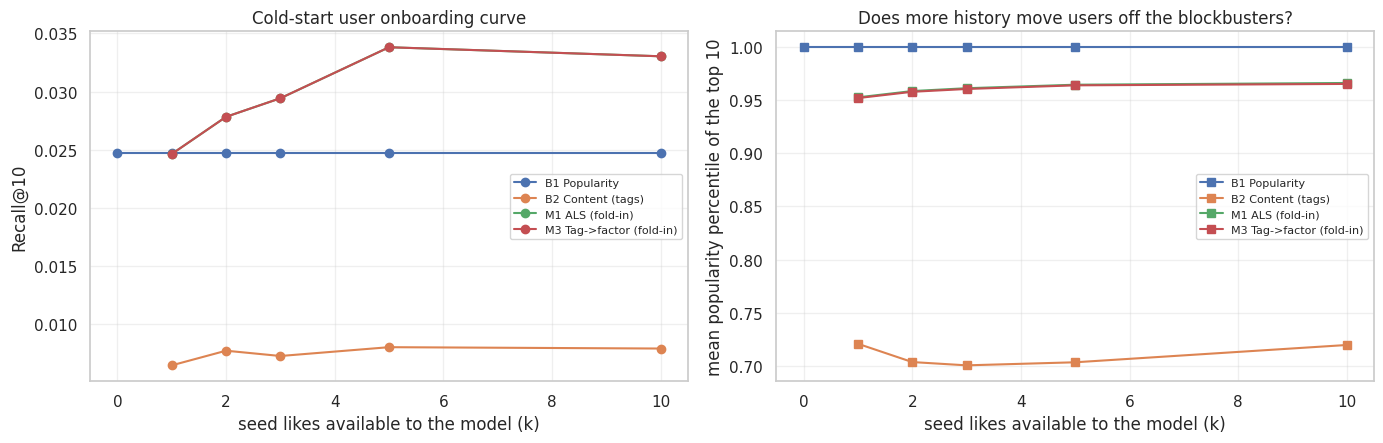

In [55]:
# Audience note  -  Onboarding curve (Block C):
# For k = 0,1,2,3,5,10 seed likes, fold in an ALS user vector and compare to popularity.
# The demo app is this experiment with a human picking the seeds.

# --- Block C, step 2: the onboarding curve ----------------------------------
# Same users, same blocked items, same truth at every k. Only the amount of history the
# model is allowed to use changes.
def onboard_scorers(u, k):
    """Return {method: full-catalogue score vector} for a user restricted to k seeds."""
    hist = seed_hist.get(u)
    out = {"B1 Popularity": CTX_FULL.pop.astype(np.float64)}
    if hist is None or k == 0:
        out["B2 Content (tags)"] = np.zeros(n_games)
        out["M1 ALS (fold-in)"] = np.zeros(n_games)
        out["M3 Tag->factor (fold-in)"] = np.zeros(n_games)
        return out
    items, conf = hist[0][:k], hist[1][:k]

    prof = fold_in_profile(items)
    out["B2 Content (tags)"] = (
        (TAGM @ prof) / (np.linalg.norm(prof) * TAGN) if prof is not None
        else np.zeros(n_games)
    )
    uf = fold_in_als(items, conf, CTX_FULL.als_if, YtY=_YtY_full)
    out["M1 ALS (fold-in)"] = CTX_FULL.als_if @ uf
    out["M3 Tag->factor (fold-in)"] = CTX_FULL.hybrid_if @ uf
    return out


# Popularity needs no history, so it is defined at every k. The other three have no
# input at all when k = 0: scoring them would rank an all-zero vector, which returns an
# arbitrary slice of the catalogue and reads as if the model had skill. They are recorded
# as undefined at k = 0 instead.
NO_HISTORY_METHODS = ["B1 Popularity"]
HISTORY_METHODS = ["B2 Content (tags)", "M1 ALS (fold-in)", "M3 Tag->factor (fold-in)"]
ONBOARD_METHODS = NO_HISTORY_METHODS + HISTORY_METHODS
onboard_users = [u for u in clean_users if u in seed_hist]
print(f"Running {len(ONBOARD_KS)} history sizes x {len(ONBOARD_METHODS)} methods "
      f"on {len(onboard_users):,} users")

onboard_per_user = {}      # (method, k) -> per-user recall array
onboard_rows = []
for k in ONBOARD_KS:
    active = ONBOARD_METHODS if k > 0 else NO_HISTORY_METHODS
    acc = {m: [] for m in active}
    pop_pcts = {m: [] for m in active}
    for u in tqdm(onboard_users, desc=f"k={k}", leave=False):
        rel = clean_truth[u]
        blocked = clean_seen[u]
        sc = onboard_scorers(u, k)
        for m in active:
            s = np.asarray(sc[m], dtype=np.float64).copy()
            if len(blocked):
                s[blocked] = -np.inf
            top = np.argpartition(-s, K - 1)[:K]
            top = top[np.argsort(-s[top])]
            acc[m].append(np.isin(top, rel).sum() / len(rel))
            pop_pcts[m].append(float(CTX_FULL.pop_pct[top].mean()))
    for m in ONBOARD_METHODS:
        if m not in active:
            onboard_rows.append({"k_seed_likes": k, "model": m,
                                 f"recall@{K}": np.nan,
                                 "avg_popularity_percentile": np.nan})
            continue
        onboard_per_user[(m, k)] = np.array(acc[m])
        onboard_rows.append({
            "k_seed_likes": k, "model": m,
            f"recall@{K}": float(np.mean(acc[m])),
            "avg_popularity_percentile": float(np.mean(pop_pcts[m])),
        })

onboard = pd.DataFrame(onboard_rows)
onboard_wide = onboard.pivot(index="k_seed_likes", columns="model", values=f"recall@{K}")
print(f"\n=== ONBOARDING CURVE: Recall@{K} vs number of seed likes ===")
display(onboard_wide.round(5))
onboard.to_csv(OUT_DIR / "onboarding_curve.csv", index=False)

# Where does personalisation overtake the no-history baseline?
print("\n--- Crossover against popularity (which needs no history) ---")
print(f"k=0 is popularity only ({onboard_per_user[('B1 Popularity', 0)].mean():.5f}); "
      f"the personalised models have no input at that point and are left undefined.")
# A crossover that does not survive the next step up in history is noise, not a
# crossover. Both are recorded: the first k that clears the CI, and the first k from
# which every larger k also clears it.
_pos_ks = [kk for kk in ONBOARD_KS if kk > 0]
crossover, crossover_stable = {}, {}
for m in HISTORY_METHODS:
    beats_at = {}
    for k in _pos_ks:
        a = onboard_per_user[(m, k)]
        b = onboard_per_user[("B1 Popularity", k)]
        diff, lo, hi, pb, pw = paired_test(a, b, n_boot=2000)
        beats_at[k] = bool(diff > 0 and lo > 0)
        print(f"{m:<28} k={k:>2}: {a.mean():.5f} vs {b.mean():.5f} "
              f"({diff:+.5f}, CI [{lo:+.5f}, {hi:+.5f}]) "
              f"{'BEATS popularity' if beats_at[k] else ''}")
    crossover[m] = next((k for k in _pos_ks if beats_at[k]), None)
    crossover_stable[m] = next(
        (k for i, k in enumerate(_pos_ks) if all(beats_at[j] for j in _pos_ks[i:])), None)
    if crossover[m] != crossover_stable[m]:
        print(f"{m:<28} first win at k={crossover[m]} does NOT hold at every larger k; "
              f"the stable crossover is "
              f"{'never' if crossover_stable[m] is None else 'k=' + str(crossover_stable[m])}")
    print()

print("--- Product reading (the stable crossover is the one to quote) ---")
for m in HISTORY_METHODS:
    k = crossover_stable[m]
    if k is None:
        first = crossover[m]
        if first is None:
            print(f"{m}: never beats popularity within k<={max(ONBOARD_KS)}. A user needs "
                  f"more than {max(ONBOARD_KS)} ratings before this model earns its place.")
        else:
            print(f"{m}: wins at k={first} but not at every larger k, so there is no stable "
                  f"crossover in this grid. Report it as unresolved rather than as k={first}.")
    else:
        print(f"{m}: overtakes popularity from {k} seed like(s) onward and stays ahead. Ask "
              f"new users for {k} ratings before switching them off the popularity shelf.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for m in ONBOARD_METHODS:
    sel = onboard[(onboard["model"] == m) & onboard[f"recall@{K}"].notna()]
    axes[0].plot(sel["k_seed_likes"], sel[f"recall@{K}"], marker="o", label=m)
axes[0].set_xlabel("seed likes available to the model (k)")
axes[0].set_ylabel(f"Recall@{K}")
axes[0].set_title("Cold-start user onboarding curve")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
for m in ONBOARD_METHODS:
    sel = onboard[(onboard["model"] == m) & onboard["avg_popularity_percentile"].notna()]
    axes[1].plot(sel["k_seed_likes"], sel["avg_popularity_percentile"], marker="s", label=m)
axes[1].set_xlabel("seed likes available to the model (k)")
axes[1].set_ylabel("mean popularity percentile of the top 10")
axes[1].set_title("Does more history move users off the blockbusters?")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# One table, every model  -  then decide what to ship

Late models (dislike-aware LTR, recency features, …) arrived after the first clean table.
This section re-scores them on the **same** users and truth, merges into `final_results`,
and runs the paired tests that decide the shipped ranker.

**How we choose the shipped model (audience version):**

- Prefer a model that beats popularity on recall *and* ranks relevant items higher (NDCG).
- If two models tie on recall but one wins NDCG, ship the better-ranked list.
- In this notebook that decision lands on **M1 ALS** for the main "For you" shelf,
  even when a LambdaRank variant has a slightly higher recall point estimate.


In [56]:
# Audience note  -  Final leaderboard:
# Merge every clean-protocol model into one table and run paired tests for the
# shipped-ranker decision (M1 ALS vs alternatives on recall AND NDCG).

# --- Consolidated headline: every model, one protocol, one table -------------
LATE_METHODS = [
    ("M2d LTR + recency", make_ranker(s_ltr_v4)),
]
print("Evaluating the models that arrived after cell 83 on the main list...")
late_ov, _, late_ics, late_cov = eval_clean(LATE_METHODS)
late_tbl = (late_ov.merge(late_ics[["model", f"cold_item_hitrate@{K}",
                                    f"warm_item_hitrate@{K}"]], on="model")
            .merge(late_cov, on="model"))

final_results = (
    pd.concat([clean_results, neg_tbl, late_tbl], ignore_index=True)
    .drop_duplicates(subset="model", keep="last")
    .sort_values(f"recall@{K}", ascending=False)
    .reset_index(drop=True)
)
print(f"\n=== FINAL RESULTS: {len(final_results)} methods, identical protocol ===")
display(final_results)
final_results.to_csv(OUT_DIR / "final_results.csv", index=False)

_best_recall = final_results.iloc[0]
_best_ndcg = final_results.sort_values(f"ndcg@{K}", ascending=False).iloc[0]
print(f"\nHighest recall@{K}: {_best_recall['model']} ({_best_recall[f'recall@{K}']:.5f})")
print(f"Highest ndcg@{K}  : {_best_ndcg['model']} ({_best_ndcg[f'ndcg@{K}']:.5f})")
if _best_recall["model"] != _best_ndcg["model"]:
    print("The two metrics disagree, so there is no single 'best model'. Name both and")
    print("choose on the product question: recall for how much relevant inventory reaches")
    print("the shelf, NDCG for how well ordered that shelf is.")

# --- The comparison that decides the shipped ranker -------------------------
_all_per_user = dict(per_user)
_all_per_user.update(neg_per_user)
_late_rank = dict(LATE_METHODS)
for name, rank in LATE_METHODS:
    rec, ndc = [], []
    for u in tqdm(clean_users, desc=f"per-user: {name}", leave=False):
        rel = clean_truth[u]
        hit = np.isin(rank(u, clean_seen[u]), rel)
        rec.append(hit[:K].sum() / len(rel))
        idcg = float((1.0 / _log2[: min(len(rel), K)]).sum())
        ndc.append(float((hit[:K] / _log2[:K]).sum()) / idcg if idcg else 0.0)
    _all_per_user[name] = {"recall": np.array(rec), "ndcg": np.array(ndc)}

FINAL_COMPARISONS = [
    ("M2c LTR + explicit negatives", "M1 ALS"),
    ("M2c LTR + explicit negatives", "M2b LTR (fixed negatives)"),
    ("M2d LTR + recency", "M2c LTR + explicit negatives"),
    ("M1 ALS", "B1 Popularity"),
]
rows = []
for metric in ("recall", "ndcg"):
    for a, b in FINAL_COMPARISONS:
        if a not in _all_per_user or b not in _all_per_user:
            continue
        diff, lo, hi, pb, pw = paired_test(_all_per_user[a][metric], _all_per_user[b][metric])
        rows.append({"metric": f"{metric}@{K}", "A": a, "B": b,
                     "mean_A": float(_all_per_user[a][metric].mean()),
                     "mean_B": float(_all_per_user[b][metric].mean()),
                     "diff": diff, "ci_low": lo, "ci_high": hi, "p_wilcoxon": pw})
final_sig = pd.DataFrame(rows)

_order = np.argsort(final_sig["p_wilcoxon"].to_numpy())
_m = len(final_sig)
_adj, _run = np.empty(_m), 0.0
for _r, _p in enumerate(_order):
    _run = max(_run, min((_m - _r) * final_sig["p_wilcoxon"].iloc[_p], 1.0))
    _adj[_p] = _run
final_sig["p_holm"] = _adj
final_sig["ci_excludes_zero"] = (final_sig["ci_low"] > 0) | (final_sig["ci_high"] < 0)
display(final_sig.round(6))
final_sig.to_csv(OUT_DIR / "final_significance.csv", index=False)

print("\n--- Shipped-ranker decision ---")
for _, r in final_sig.iterrows():
    if r["diff"] > 0 and r["ci_excludes_zero"]:
        v = f"{r['A']} WINS"
    elif r["diff"] < 0 and r["ci_excludes_zero"]:
        v = f"{r['B']} WINS"
    else:
        v = "no reliable difference"
    print(f"{r['metric']}: {r['A']} vs {r['B']}: {r['diff']:+.5f} "
          f"[{r['ci_low']:+.5f}, {r['ci_high']:+.5f}], Holm p={r['p_holm']:.3g} -> {v}")

_m2c_v_als = final_sig[(final_sig["A"] == "M2c LTR + explicit negatives")
                       & (final_sig["B"] == "M1 ALS")]
if len(_m2c_v_als) == 2:
    def _winner(row):
        """'A', 'B' or None -- which side the interval actually supports."""
        if not row["ci_excludes_zero"]:
            return None
        return "A" if row["diff"] > 0 else "B"

    _r_row = _m2c_v_als[_m2c_v_als["metric"] == f"recall@{K}"].iloc[0]
    _n_row = _m2c_v_als[_m2c_v_als["metric"] == f"ndcg@{K}"].iloc[0]
    _rw, _nw = _winner(_r_row), _winner(_n_row)
    _names = {"A": "M2c LTR + explicit negatives", "B": "M1 ALS"}

    print("\n" + "=" * 78)
    print(f"recall@{K}: " + ("no reliable difference" if _rw is None
                             else f"{_names[_rw]} is better"))
    print(f"ndcg@{K}  : " + ("no reliable difference" if _nw is None
                             else f"{_names[_nw]} is better"))
    if _rw == "A" and _nw == "A":
        SHIPPED = "M2c LTR + explicit negatives"
        print("M2c beats M1 ALS on both metrics. Explicit negative feedback is the")
        print("difference, which is the contribution the problem statement promised.")
    elif _rw == "B" and _nw == "B":
        SHIPPED = "M1 ALS"
        print("M1 ALS beats M2c on both metrics. The negative-feedback features improve")
        print("the ranker that lacks them but do not lift it past the ALS baseline.")
    elif _rw == "A" and _nw == "B":
        SHIPPED = "M1 ALS"
        print("SPLIT RESULT: M2c surfaces more relevant items in the top K, M1 ALS orders")
        print("them better. Ship M1 ALS for the ranked shelf and quote M2c's recall")
        print("advantage separately. Neither is 'the best model'.")
    elif _rw == "B" and _nw == "A":
        SHIPPED = "M2c LTR + explicit negatives"
        print("SPLIT RESULT: M1 ALS surfaces more relevant items, M2c orders them better.")
        print("Ship M2c for the ranked shelf and quote the recall gap as a limitation.")
    elif "A" in (_rw, _nw):
        SHIPPED = "M2c LTR + explicit negatives"
        _m = f"recall@{K}" if _rw == "A" else f"ndcg@{K}"
        print(f"M2c wins on {_m} and is not reliably different on the other, so it is the")
        print("better choice -- but report the single metric it actually won on.")
    elif "B" in (_rw, _nw):
        SHIPPED = "M1 ALS"
        _m = f"recall@{K}" if _rw == "B" else f"ndcg@{K}"
        print(f"M1 ALS is significantly better on {_m} and not reliably different on the")
        print("other. That is stronger than 'no difference': the simpler model wins on the")
        print("evidence, and the negative-feedback features do not pay for their complexity")
        print("on the main list -- even though they clearly beat M2b.")
    else:
        SHIPPED = "M1 ALS"
        print("Neither metric separates M2c from M1 ALS. Ship the simpler model and report")
        print("the negative-feedback features as neutral on the main list.")

    # The M2c-vs-M1 duel says nothing about popularity, which is still a contender on
    # this protocol. If it wins on both metrics, no learned ranker has earned the shelf.
    _pop_r = float(final_results.loc[final_results["model"] == "B1 Popularity",
                                     f"recall@{K}"].iloc[0])
    _pop_n = float(final_results.loc[final_results["model"] == "B1 Popularity",
                                     f"ndcg@{K}"].iloc[0])
    _sh = final_results[final_results["model"] == SHIPPED].iloc[0]
    _sh_r, _sh_n = float(_sh[f"recall@{K}"]), float(_sh[f"ndcg@{K}"])
    if _pop_r >= _sh_r and _pop_n >= _sh_n:
        print(f"OVERRIDDEN: B1 Popularity still beats {SHIPPED} on both metrics "
              f"(recall {_pop_r:.5f} vs {_sh_r:.5f}, ndcg {_pop_n:.5f} vs {_sh_n:.5f}).")
        print("No learned ranker has earned the main shelf. Report that plainly rather")
        print("than shipping the winner of a duel that excluded the incumbent.")
        SHIPPED = "B1 Popularity"
    print(f"SHIPPED RANKER: {SHIPPED}")
    print("=" * 78)

Evaluating the models that arrived after cell 83 on the main list...


M2d LTR + recency:   0%|          | 0/572 [00:00<?, ?it/s]


=== FINAL RESULTS: 13 methods, identical protocol ===


,model,n_users,recall@10,recall@50,recall@100,ndcg@10,hitrate@10,cold_item_hitrate@10,warm_item_hitrate@10,catalogue_coverage,avg_popularity_percentile
0,M3 Tag->factor cold-start,572,0.039967,0.130616,0.209488,0.121838,0.468531,0.00000,0.038365,0.116037,0.960716
1,M1 ALS,572,0.039967,0.130543,0.211331,0.121838,0.468531,0.00000,0.038365,0.115478,0.962869
2,M4 ALS + dislike penalty,572,0.039958,0.130626,0.211414,0.121646,0.468531,0.00000,0.038365,0.114826,0.963484
3,M2a LTR (tag-pool negatives),572,0.038201,0.119754,0.181616,0.107288,0.458042,0.00000,0.034625,0.096480,0.949568
4,M2b LTR (fixed negatives),572,0.034695,0.125121,0.193790,0.092022,0.447552,0.00156,0.030563,0.144999,0.823036
5,M2d LTR + recency,572,0.032587,0.128479,0.214466,0.085739,0.426573,0.00156,0.028822,0.128422,0.837561
6,M2c LTR + explicit negatives,572,0.032261,0.121584,0.205511,0.091236,0.437063,0.00000,0.031337,0.138573,0.881421
7,B3 MF (SVD),572,0.028109,0.113957,0.174839,0.096468,0.419580,0.00000,0.032562,0.030639,0.985801
8,B1 Popularity,572,0.024623,0.099403,0.157271,0.076684,0.396853,0.00000,0.027146,0.002235,0.999528
9,Two-stage (tags -> M2b),572,0.020388,0.049204,0.065903,0.052105,0.256993,0.00156,0.016442,0.185044,0.805137



Highest recall@10: M3 Tag->factor cold-start (0.03997)
Highest ndcg@10  : M3 Tag->factor cold-start (0.12184)


per-user: M2d LTR + recency:   0%|          | 0/572 [00:00<?, ?it/s]

,metric,A,B,mean_A,mean_B,diff,ci_low,ci_high,p_wilcoxon,p_holm,ci_excludes_zero
0,recall@10,M2c LTR + explicit negatives,M1 ALS,0.032261,0.039967,-0.007706,-0.015999,-0.000162,0.015614,0.078069,True
1,recall@10,M2c LTR + explicit negatives,M2b LTR (fixed negatives),0.032261,0.034695,-0.002434,-0.010117,0.005041,0.965294,1.000000,False
2,recall@10,M2d LTR + recency,M2c LTR + explicit negatives,0.032587,0.032261,0.000325,-0.007668,0.008668,0.132427,0.529709,False
3,recall@10,M1 ALS,B1 Popularity,0.039967,0.024623,0.015345,0.007003,0.024418,0.000003,0.000015,True
4,ndcg@10,M2c LTR + explicit negatives,M1 ALS,0.091236,0.121838,-0.030603,-0.042076,-0.019404,0.000001,0.000006,True
5,ndcg@10,M2c LTR + explicit negatives,M2b LTR (fixed negatives),0.091236,0.092022,-0.000786,-0.009227,0.007765,0.727821,1.000000,False
6,ndcg@10,M2d LTR + recency,M2c LTR + explicit negatives,0.085739,0.091236,-0.005497,-0.013387,0.002379,0.167437,0.529709,False
7,ndcg@10,M1 ALS,B1 Popularity,0.121838,0.076684,0.045154,0.031315,0.059433,0.000000,0.000000,True



--- Shipped-ranker decision ---
recall@10: M2c LTR + explicit negatives vs M1 ALS: -0.00771 [-0.01600, -0.00016], Holm p=0.0781 -> M1 ALS WINS
recall@10: M2c LTR + explicit negatives vs M2b LTR (fixed negatives): -0.00243 [-0.01012, +0.00504], Holm p=1 -> no reliable difference
recall@10: M2d LTR + recency vs M2c LTR + explicit negatives: +0.00033 [-0.00767, +0.00867], Holm p=0.53 -> no reliable difference
recall@10: M1 ALS vs B1 Popularity: +0.01534 [+0.00700, +0.02442], Holm p=1.5e-05 -> M1 ALS WINS
ndcg@10: M2c LTR + explicit negatives vs M1 ALS: -0.03060 [-0.04208, -0.01940], Holm p=6.47e-06 -> M1 ALS WINS
ndcg@10: M2c LTR + explicit negatives vs M2b LTR (fixed negatives): -0.00079 [-0.00923, +0.00777], Holm p=1 -> no reliable difference
ndcg@10: M2d LTR + recency vs M2c LTR + explicit negatives: -0.00550 [-0.01339, +0.00238], Holm p=0.53 -> no reliable difference
ndcg@10: M1 ALS vs B1 Popularity: +0.04515 [+0.03132, +0.05943], Holm p=4.05e-08 -> M1 ALS WINS

recall@10: M1 ALS is 

In [57]:
# Audience note  -  Problem-statement audit:
# Walk the seven claims one by one and print SUPPORTED / NEUTRAL / NOT SUPPORTED
# from the tables above. This cell is the closing slide of the research story.

# --- Problem statement, line by line ----------------------------------------
def _row_of(tbl, col, model_contains):
    if tbl is None or len(tbl) == 0 or col not in tbl.columns:
        return None
    m = tbl[tbl["model"].str.contains(model_contains, regex=False)]
    return float(m[col].iloc[0]) if len(m) else None


print("=" * 78)
print("PROBLEM STATEMENT AUDIT")
print("=" * 78)

# 1. personalisation over popularity
_r_pop = float(final_results.loc[final_results["model"] == "B1 Popularity",
                                f"recall@{K}"].iloc[0])
_best = final_results.iloc[0]
# The long-tail and personalisation lines are only meaningful against a model that
# actually personalises, so popularity is excluded when picking the comparison.
_best_pers = final_results[final_results["model"] != "B1 Popularity"].iloc[0]
print(f"\n1. Personalised ranking beats popularity")
print(f"   popularity Recall@{K} {_r_pop:.5f}")
print(f"   best overall      {_best['model']} {_best[f'recall@{K}']:.5f}")
print(f"   best personalised {_best_pers['model']} {_best_pers[f'recall@{K}']:.5f}")
if _best["model"] == "B1 Popularity":
    print("   NOTE: popularity is still the single best ranker on this protocol.")
# Test the model this cell actually names as best, not whichever one happens to be
# in the earlier significance table.
_cand = _best_pers["model"]
if "_all_per_user" in globals() and _cand in _all_per_user and "B1 Popularity" in _all_per_user:
    _d, _lo, _hi, _pb, _pw = paired_test(_all_per_user[_cand]["recall"],
                                         _all_per_user["B1 Popularity"]["recall"])
    print(f"   paired test, {_cand} vs popularity: {_d:+.5f} "
          f"[{_lo:+.5f}, {_hi:+.5f}], p={_pw:.3g}")
    print("   VERDICT: " + ("SUPPORTED" if _d > 0 and _lo > 0 else "NOT SUPPORTED"))
else:
    _sig_row = sig[(sig["metric"] == f"recall@{K}") & (sig["A"] == "M1 ALS")
                   & (sig["B"] == "B1 Popularity")]
    if len(_sig_row):
        r = _sig_row.iloc[0]
        print(f"   paired test (M1 ALS vs popularity): {r['diff']:+.5f} "
              f"[{r['ci_low']:+.5f}, {r['ci_high']:+.5f}], Holm p={r['p_holm']:.3g}")
        print("   VERDICT: " + ("SUPPORTED" if r["diff"] > 0 and r["ci_low"] > 0
                                else "NOT SUPPORTED"))

# 2. multiple signals
print(f"\n2. Hours played and review helpfulness carry information")
if "conf_tbl" in globals():
    for _, r in conf_tbl.iterrows():
        print(f"   {r['model']:<40} {r[f'recall@{K}']:.5f}")
    _b = float(conf_tbl.loc[conf_tbl["model"].str.contains("binary"), f"recall@{K}"].iloc[0])
    _c = float(conf_tbl.loc[conf_tbl["model"].str.contains("current"), f"recall@{K}"].iloc[0])
    if _c > _b * 1.02:
        print("   VERDICT: SUPPORTED -- weighting by hours/helpfulness beats binary")
    elif _c < _b * 0.98:
        print("   VERDICT: REVERSED -- binary beats the weighted matrix, which is direct")
        print("            evidence for the problem statement's own playtime warning")
    else:
        print("   VERDICT: NEUTRAL -- the weighting changes nothing measurable")

# 3. explicit negative feedback
print(f"\n3. Explicit negative feedback is used, not discarded")
if "neg_sig" in globals():
    _any = bool(((neg_sig["diff"] > 0) & neg_sig["ci_excludes_zero"]).any())
    print(f"   explicit negatives in the data: {NEG_FULL.n_neg:,} rows")
    print(f"   models built on them: M4 (anti-profile penalty), M2c (hard negatives)")
    # "Helps" here means "beats the same ranker without them". Whether that clears the
    # best non-LTR model is a different question, and the two are easy to conflate.
    _vs_als = None
    if "final_sig" in globals():
        _q = final_sig[(final_sig["A"] == "M2c LTR + explicit negatives")
                       & (final_sig["B"] == "M1 ALS")]
        if len(_q):
            _vs_als = bool(((_q["diff"] > 0) & _q["ci_excludes_zero"]).any())
    if _any and _vs_als:
        print("   VERDICT: USED, AND BEATS BOTH THE SAME RANKER WITHOUT THEM AND M1 ALS")
    elif _any:
        print("   VERDICT: USED, AND HELPS THE RANKER (M2c > M2b) BUT DOES NOT BEAT M1 ALS")
        print("            Quote it as an ablation result, not as the best model.")
    else:
        print("   VERDICT: USED, MEASURED, NO GAIN -- report as a negative result")

# 4. cold-start items
print(f"\n4. Cold-start games are reachable")
_cold_main = _row_of(final_results, f"cold_item_hitrate@{K}", "M1 ALS")
print(f"   main list, cold-item hit rate@{K}: "
      f"{'n/a' if _cold_main is None else f'{_cold_main:.5f}'}")
if "cold_only" in globals() and len(cold_only):
    _cb = cold_only[cold_only["model"] != "C0 Random (floor)"].iloc[0]
    _cf = float(cold_only.loc[cold_only["model"] == "C0 Random (floor)",
                              f"cold_recall@{K}"].iloc[0])
    print(f"   dedicated cold surface: {_cb['model']} {_cb[f'cold_recall@{K}']:.5f} "
          f"vs random floor {_cf:.5f}")
    print(f"   bar (max of measured floor and chance {K}/{n_cold_items:,}): "
          f"{_bar_cold:.5f}")
    print("   VERDICT: " + ("RANKABLE ON A DEDICATED SURFACE"
                            if _cb[f"cold_recall@{K}"] > 2 * _bar_cold
                            else "NOT RANKABLE -- negative result"))

# 5. brand-new releases
print(f"\n5. Brand-new releases are handled")
if "new_only" in globals() and len(new_only):
    _nb_ = new_only.iloc[0]
    _nn = float(new_only.loc[new_only["model"] == "R0 Newest first (control)",
                             f"new_recall@{K}"].iloc[0])
    print(f"   new-release surface: {_nb_['model']} {_nb_[f'new_recall@{K}']:.5f} "
          f"vs date sort {_nn:.5f}")
    _n_cold_overlap = int((NEW_MASK & CTX_FULL.cold_mask).sum())
    print(f"   CAVEAT: only {_n_cold_overlap:,} of {int(NEW_MASK.sum()):,} 'new' games are "
          f"also cold, so most of this shelf is recent games that already have history.")
    print("           This measures a recent-releases shelf, NOT zero-history games.")
    print("   VERDICT: " + ("PERSONALISED NEW-RELEASE SHELF WORKS"
                            if _nb_[f"new_recall@{K}"] > _nn else
                            "CHRONOLOGICAL IS AS GOOD -- ship the date sort"))
else:
    print("   VERDICT: NOT MEASURABLE -- too little new inventory in the test window")

# 6. cold-start users
print(f"\n6. Cold-start users are handled")
if "crossover_stable" in globals():
    for m in crossover_stable:
        _s, _f = crossover_stable[m], crossover[m]
        _txt = ("never" if _s is None and _f is None else
                f"k={_f} but not stably" if _s is None else f"k={_s}")
        print(f"   {m:<28} overtakes popularity at {_txt}")
    _ks = [k for k in crossover_stable.values() if k is not None]
    print("   VERDICT: " + (f"SUPPORTED -- personalisation pays off from "
                            f"{min(_ks)} rating(s) onward" if _ks else
                            "NOT SUPPORTED -- no stable crossover in the grid tested"))

# 7. long-tail
print(f"\n7. Long-tail discovery beyond popularity bias")
_cov_pop = float(final_results.loc[final_results["model"] == "B1 Popularity",
                                   "catalogue_coverage"].iloc[0])
_pp_pop = float(final_results.loc[final_results["model"] == "B1 Popularity",
                                  "avg_popularity_percentile"].iloc[0])
print(f"   popularity: coverage {_cov_pop:.4f}, mean popularity pct {_pp_pop:.4f}")
print(f"   {_best_pers['model']}: coverage {_best_pers['catalogue_coverage']:.4f}, "
      f"mean popularity pct {_best_pers['avg_popularity_percentile']:.4f}")
_wider = _best_pers["catalogue_coverage"] > 2 * _cov_pop
_deeper = _best_pers["avg_popularity_percentile"] < _pp_pop - 0.02
print("   VERDICT: " + ("SUPPORTED on both coverage and popularity bias" if _wider and _deeper
                        else "SUPPORTED on coverage only" if _wider
                        else "SUPPORTED on popularity bias only" if _deeper
                        else "NOT SUPPORTED"))

if "SHIPPED" in globals():
    print(f"\nSHIPPED RANKER (from the consolidated table): {SHIPPED}")

print("\n" + "=" * 78)
print("Every verdict above is computed from the tables in this notebook. Anything")
print("marked NOT SUPPORTED or NOT MEASURABLE belongs in the limitations section,")
print("stated plainly, rather than being quietly dropped.")
print("=" * 78)

PROBLEM STATEMENT AUDIT

1. Personalised ranking beats popularity
   popularity Recall@10 0.02462
   best overall      M3 Tag->factor cold-start 0.03997
   best personalised M3 Tag->factor cold-start 0.03997
   paired test, M3 Tag->factor cold-start vs popularity: +0.01534 [+0.00700, +0.02442], p=2.5e-06
   VERDICT: SUPPORTED

2. Hours played and review helpfulness carry information
   ALS conf=hours x helpfulness (current)   0.03997
   ALS conf=binary (label only)             0.03770
   ALS conf=helpfulness only                0.03764
   ALS conf=hours only                      0.03626
   ALS conf=hours + 0.3 helpfulness         0.03478
   VERDICT: SUPPORTED -- weighting by hours/helpfulness beats binary

3. Explicit negative feedback is used, not discarded
   explicit negatives in the data: 593,014 rows
   models built on them: M4 (anti-profile penalty), M2c (hard negatives)
   VERDICT: USED, MEASURED, NO GAIN -- report as a negative result

4. Cold-start games are reachable
   main 

# Serving artifacts for the web app

Everything above is analysis. This cell **writes the files a web process needs**, then
**reloads them into a fresh namespace and serves from the reloaded copies only**. If an
artifact were missing or misaligned, the notebook fails here  -  not silently in the app.

| Shelf | What powers it | Why |
|---|---|---|
| **Popular now** | Like counts | Honest zero-history shelf before the user picks anything |
| **For you** | ALS item factors + **fold-in** from the user's picks | Measured personalised ranker; matches Block C onboarding |
| **Hidden gems** | Tag->factor hybrid scores, restricted to the unpopular tail | Where coverage / long-tail gains showed up |
| **New releases** | Same hybrid scores × recent-release mask | Problem-statement surface; interpret with the caveat above |

LambdaRank models are exported for research continuity but **not** used as the live main
ranker: they need a larger feature stack at request time and did not win the shipped-NDCG
decision over ALS.

**Demo caveat:** some blockbuster `app_id`s have empty tag vectors in Kozyriev's
metadata. Ranking still works; the "because: …" chips may say "no shared tags" for those
titles. That is a data hole, not an ALS failure.


In [58]:
# Audience note  -  Export for the web demo:
# Write items.csv, ALS/hybrid factors, tag matrix; reload from disk; serve four shelves.
# Proves the app needs only these artifacts  -  not the 41M file or notebook state.

# --- Serving artifacts: write, reload, and serve from the reloaded copies -----
import json
from scipy.sparse import csr_matrix, save_npz, load_npz

LONGTAIL_MAX_PCT = 0.60   # "hidden gems" = bottom 60% by popularity (a product choice)
NEW_AGE_DAYS = globals().get("NEW_WINDOW_DAYS", 365)

# ---------------------------------------------------------------- 1. write
# One row per game, in the SAME index order the factor matrices use, so the server
# never has to join on app_id at request time.
_items = pd.DataFrame({"gi": np.arange(n_games, dtype=np.int64), "app_id": idx_to_game})
_gmeta_cols = [c for c in ("title", "date_release", "rating", "positive_ratio",
                           "user_reviews", "price_final") if c in games.columns]
if _gmeta_cols:
    _gm = games[["app_id"] + _gmeta_cols].copy()
    _gm["app_id"] = pd.to_numeric(_gm["app_id"], errors="coerce")
    _gm = _gm.dropna(subset=["app_id"]).drop_duplicates("app_id")
    _gm["app_id"] = _gm["app_id"].astype(np.int64)
    _items = _items.merge(_gm, on="app_id", how="left")
if "title" not in _items.columns:
    _items["title"] = "app " + _items["app_id"].astype(str)
_items["title"] = _items["title"].fillna("app " + _items["app_id"].astype(str))

_items["pop"] = CTX_FULL.pop
_items["pop_pct"] = CTX_FULL.pop_pct
_items["is_cold"] = CTX_FULL.cold_mask
_items["has_tags"] = HAS_TAGS
_items["release_age_days"] = globals().get("REL_AGE", np.full(n_games, np.nan, np.float32))
_items["is_new"] = globals().get("NEW_MASK", np.zeros(n_games, bool))

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
_items.to_csv(EXPORT_DIR / "items.csv", index=False)
np.save(EXPORT_DIR / "item_factors_als.npy", CTX_FULL.als_if.astype(np.float32))
np.save(EXPORT_DIR / "item_factors_hybrid.npy", CTX_FULL.hybrid_if.astype(np.float32))
save_npz(EXPORT_DIR / "tag_matrix.npz", csr_matrix(TAGM))
(EXPORT_DIR / "tag_vocab.json").write_text(json.dumps(list(tag_vocab)), encoding="utf-8")

# Exported for a later version, not used by the server below.
np.save(EXPORT_DIR / "item_features.npy", CTX_FULL.item_feat.astype(np.float32))
if hasattr(globals().get("ltr_v2"), "booster_"):
    ltr_v2.booster_.save_model(str(EXPORT_DIR / "ltr_lambdarank.txt"))

_pop_row = None
if "final_results" in globals():
    _fr = final_results.set_index("model")
    if "B1 Popularity" in _fr.index:
        _pop_row = _fr.loc["B1 Popularity"]

CONFIG = {
    "n_games": int(n_games),
    "factor_dim": int(CTX_FULL.als_if.shape[1]),
    "tag_dim": int(TAGM.shape[1]),
    "als_alpha": float(globals().get("ALS_ALPHA", 20.0)),
    "als_reg": float(globals().get("ALS_REG", 0.05)),
    "train_cutoff": str(cutoff),
    "top_k": int(K),
    "longtail_max_pct": float(LONGTAIL_MAX_PCT),
    "new_age_days": int(NEW_AGE_DAYS),
    "shipped_main_ranker": str(globals().get("SHIPPED", "B1 Popularity")),
    "new_releases_measurable": bool(globals().get("_new_users", 0) >= 30),
    "popularity_recall_at_k": (float(_pop_row[f"recall@{K}"])
                               if _pop_row is not None else None),
}
(EXPORT_DIR / "config.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

print(f"Artifacts written to {EXPORT_DIR}")
for _p in sorted(EXPORT_DIR.iterdir()):
    print(f"  {_p.name:<28} {_p.stat().st_size / 1e6:>8.2f} MB")


# ------------------------------------------------- 2. the server, artifacts only
def load_artifacts(d):
    """Everything a web process holds in memory. No notebook state is referenced."""
    d = Path(d)
    items = pd.read_csv(d / "items.csv")
    als_if = np.load(d / "item_factors_als.npy")
    tagm = load_npz(d / "tag_matrix.npz").tocsr()
    art = {
        "cfg": json.loads((d / "config.json").read_text(encoding="utf-8")),
        "items": items,
        "als_if": als_if,
        "hybrid_if": np.load(d / "item_factors_hybrid.npy"),
        "tagm": tagm,
        "tag_vocab": json.loads((d / "tag_vocab.json").read_text(encoding="utf-8")),
        "pop": items["pop"].to_numpy(dtype=np.float32),
        "pop_pct": items["pop_pct"].to_numpy(dtype=np.float32),
        "is_new": items["is_new"].to_numpy(dtype=bool),
        "titles": items["title"].astype(str).to_numpy(),
        "app_ids": items["app_id"].to_numpy(dtype=np.int64),
        # precomputed once at startup, reused by every request
        "index": {int(a): i for i, a in enumerate(items["app_id"].to_numpy())},
        "YtY": als_if.T @ als_if,
        "tag_norm": np.sqrt(tagm.multiply(tagm).sum(axis=1)).A.ravel() + 1e-8,
    }
    return art


def _fold_in(art, seed_idx):
    """Solve one new user's ALS factor with the item factors frozen (iALS fold-in)."""
    Y = art["als_if"][seed_idx].astype(np.float64)
    a, reg = art["cfg"]["als_alpha"], art["cfg"]["als_reg"]
    c = np.full(len(seed_idx), 1.0 + a)          # a picked game = confidence 1
    f = Y.shape[1]
    A = art["YtY"] + (Y * (c - 1.0)[:, None]).T @ Y + reg * np.eye(f)
    b = (Y * c[:, None]).sum(axis=0)
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(A, b, rcond=None)[0]


def _why(art, gi, profile, top=3):
    """Tags that the game and the user's picks actually share, strongest first."""
    contrib = art["tagm"][gi].multiply(profile).toarray().ravel()
    order = np.argsort(contrib)[::-1][:top]
    return [art["tag_vocab"][j] for j in order if contrib[j] > 1e-9]


def _take(art, scores, blocked, n, profile, restrict=None):
    s = np.asarray(scores, dtype=np.float64).copy()
    s[list(blocked)] = -np.inf
    if restrict is not None:
        s[~restrict] = -np.inf
    n = min(n, int(np.isfinite(s).sum()))
    if n <= 0:
        return []
    top = np.argpartition(-s, n - 1)[:n]
    top = top[np.argsort(-s[top])]
    return [{"app_id": int(art["app_ids"][gi]), "title": str(art["titles"][gi]),
             "score": float(s[gi]), "pop_pct": float(art["pop_pct"][gi]),
             "why": _why(art, gi, profile)} for gi in top]


def recommend_from_likes(art, liked_app_ids, n=10):
    """The whole serving path: a list of app_ids the user picked -> four shelves."""
    seed = [art["index"][int(a)] for a in liked_app_ids if int(a) in art["index"]]
    seed = sorted(set(seed))
    profile = (np.asarray(art["tagm"][seed].mean(axis=0)).ravel() if seed
               else np.zeros(art["cfg"]["tag_dim"]))
    blocked = set(seed)

    out = {"seeds_recognised": len(seed), "shelves": {}}
    out["shelves"]["Popular now"] = _take(art, art["pop"], blocked, n, profile)
    if not seed:
        # No picks yet: popularity is the only defensible shelf.
        out["cold_start"] = True
        return out

    u = _fold_in(art, np.asarray(seed, dtype=np.int64))
    pers = art["als_if"] @ u
    hyb = art["hybrid_if"] @ u
    tail = art["pop_pct"] <= art["cfg"]["longtail_max_pct"]

    out["shelves"]["For you"] = _take(art, pers, blocked, n, profile)
    out["shelves"]["Hidden gems"] = _take(art, hyb, blocked, n, profile, restrict=tail)
    out["shelves"]["New releases"] = _take(art, hyb, blocked, n, profile,
                                           restrict=art["is_new"])
    out["cold_start"] = False
    return out


# --------------------------------------------------- 3. verify the reloaded copies
ART = load_artifacts(EXPORT_DIR)
assert ART["als_if"].shape == (n_games, CONFIG["factor_dim"])
assert ART["hybrid_if"].shape == ART["als_if"].shape
assert ART["tagm"].shape == (n_games, CONFIG["tag_dim"])
assert len(ART["items"]) == n_games
assert np.array_equal(ART["app_ids"], idx_to_game), "item order drifted from the factors"
assert np.allclose(ART["als_if"], CTX_FULL.als_if, atol=1e-6)
print("\nReloaded artifacts align with the in-memory model.")

# Serve for a real user, using only their TRAIN likes as the picks a web user would make.
_demo_u = next(u for u in clean_users if len(seed_hist.get(u, ([],))[0]) >= 3)
_demo_seed_idx = seed_hist[_demo_u][0][:5]
_demo_likes = [int(idx_to_game[i]) for i in _demo_seed_idx]
R = recommend_from_likes(ART, _demo_likes, n=K)

assert R["seeds_recognised"] == len(set(_demo_likes)), "seed lookup lost games"
for _name, _shelf in R["shelves"].items():
    _ids = [r["app_id"] for r in _shelf]
    assert not (set(_ids) & set(_demo_likes)), f"{_name} recommended a game the user picked"
    assert len(_ids) == len(set(_ids)), f"{_name} has duplicates"
assert all(r["pop_pct"] <= LONGTAIL_MAX_PCT for r in R["shelves"]["Hidden gems"])
assert all(ART["is_new"][ART["index"][r["app_id"]]] for r in R["shelves"]["New releases"])

# The cold-start path must work with zero picks.
_R0 = recommend_from_likes(ART, [], n=K)
assert _R0["cold_start"] and len(_R0["shelves"]) == 1
print("Zero-pick path returns popularity only, as designed.")

_pp = {k: np.mean([r["pop_pct"] for r in v]) if v else float("nan")
       for k, v in R["shelves"].items()}
print(f"\nMean popularity percentile by shelf: "
      + ", ".join(f"{k} {v:.3f}" for k, v in _pp.items()))
assert _pp["Hidden gems"] < _pp["Popular now"], "the tail shelf is not actually tail-y"

print(f"\n--- Worked example: user {_demo_u} picked "
      f"{', '.join(str(ART['titles'][i]) for i in _demo_seed_idx)} ---")
for _name, _shelf in R["shelves"].items():
    print(f"\n{_name}")
    if not _shelf:
        print("  (empty on this catalogue)")
    for r in _shelf[:5]:
        _w = ", ".join(r["why"]) if r["why"] else "no shared tags"
        print(f"  {r['title'][:44]:<44} pop_pct {r['pop_pct']:.2f}  because: {_w}")

print("\n" + "=" * 78)
print("The web app needs nothing from this notebook except the files listed above.")
if not CONFIG["new_releases_measurable"]:
    print("Caveat carried into the config: the new-release shelf is UNMEASURED on this")
    print("dataset. Ship it if you like, but do not claim it works.")
print("=" * 78)


Artifacts written to /kaggle/working/processed/website_export
  config.json                      0.00 MB
  item_factors_als.npy             2.75 MB
  item_factors_hybrid.npy          2.75 MB
  item_features.npy                0.30 MB
  items.csv                        1.17 MB
  ltr_lambdarank.txt               2.08 MB
  tag_matrix.npz                   0.32 MB
  tag_vocab.json                   0.00 MB

Reloaded artifacts align with the in-memory model.
Zero-pick path returns popularity only, as designed.

Mean popularity percentile by shelf: Popular now 1.000, For you 0.962, Hidden gems 0.139, New releases 0.883

--- Worked example: user 3133750 picked Warframe, War Thunder, Company of Heroes 2, Grey Goo, Daylight ---

Popular now
  DOOM                                         pop_pct 1.00  because: no shared tags
  Portal 2                                     pop_pct 1.00  because: no shared tags
  Tomb Raider                                  pop_pct 1.00  because: Female Protagonist